# Adaptive QCNN, solving clf problem - dataset: MNIST

In [1]:
# %pip install itables
import numpy as np

### SIMULATION HYPERPARAMETERS TO CHANGE

In [ ]:
# Noise setting / Device and dataset name
noise_settings = ['0', '1', '2', '3']
noise_to_device = {'0': 'noiseless',
                   '1': 'FakeGuadalupeV2',
                   '2': 'AerSim with backend noise',
                   '3': 'IBM Quantum backend'}

selected_indices = [0, 1, 2]
noise_settings = [noise_settings[i] for i in selected_indices]
device_names = [noise_to_device[key] for key in noise_settings]

num_qubits = [4, 8]      # 4, 8, 10
problem_type = 'reg'
dataset_type = 'gen_linear'
dataset_dir = 'dataset_mr_w_error'
dataset_name = f'{dataset_type}_{dataset_dir}'
num_shots = 1024    # 1024, 256

sim_iter_num = list(range(5))
# sim_iter_num = [4]

model_names_str = ['model_mmF', 'model_mmTmbF', 'model_mmTmbT']
model_names_str_new = ['QCNN', 'HQCNN-EZ', 'HQCNN-EM']
model_rename_map = dict(zip(model_names_str, model_names_str_new))
selected_indices = [0, 1, 2]
model_names_str = [model_names_str[i] for i in selected_indices]
NO_BOUNDARY = False
NO_BOUNDARY_str = '_noBd' if NO_BOUNDARY else ""

PLOT_SAVE = False            # True, False
SUMMRAY_TABLE_SAVE = False   # True, False

print('noise_setting:', noise_settings)
print('device_name:', device_names)
print('dataset_name:', dataset_name)
print('model_names_str:', model_names_str)
print('num_shots:', num_shots)
print('PLOT_SAVE:', PLOT_SAVE)
print('SUMMRAY_TABLE_SAVE:', SUMMRAY_TABLE_SAVE)

noise_setting: ['0', '1', '2']
device_name: ['noiseless', 'FakeGuadalupeV2', 'AerSim with backend noise']
dataset_name: gen_linear_dataset_mr_w_error
model_names_str: ['model_mmF', 'model_mmTmbF', 'model_mmTmbT']
num_shots: 1024
PLOT_SAVE: False
SUMMRAY_TABLE_SAVE: False


### QCNN & NN MODEL HYPERPARAMETERS TO CHANGE

In [3]:
from itertools import product

# Global parameters of the QCNN circuit (for Qnode into TorchLayer)
embed_method = ['AngleEmbed']    # 'AmplitudeEmbed', 'IQPEmbed', 'AngleEmbed', ''AngleEmbed-r', 'ZZFeatureMap'

conv_pool_blocks = [('ConvSimple', 'PoolSimple')]    # [('ConvSimple', 'PoolSimple'), ('ConvSU4', 'PoolSimple')]
selected_indices = [0]
conv_pool_blocks = [conv_pool_blocks[i] for i in selected_indices]

conv_pool_blocks_string = []
for i in range(len(conv_pool_blocks)):
    conv_pool_blocks_string.append('_'.join(conv_pool_blocks[i]))

num_epochs = 30
batch_size = 10
start_batch = 0
num_iters = num_epochs * batch_size
hidden_acti = 'ReLU'                        # 'CELU', 'ReLU', 'Tanh'

num_hidden_layers = 1
lr_value = 0.01
lr_schedule = False
lr_schedule_str = '_schedT' if lr_schedule else ""

lr_schedule = False

model_specs = []
for embed, conv_pool in product(embed_method, conv_pool_blocks_string):
    model_specs.append((f'{embed}_{conv_pool}{NO_BOUNDARY_str}'
                        +f'_{hidden_acti}_hl{num_hidden_layers}_batch{batch_size}_lr{lr_value}{lr_schedule_str}'))

model_specs

['AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01']

### Create save_plot directory

In [4]:
# Define the folder names
save_dir = f'save_results_{problem_type}/results_summary/'

for model_spec in model_specs:
    save_summary_results_dirs = f'{save_dir}{model_spec}_{num_shots}/'
    
# print(save_summary_results_dirs)
# Create the folder if it doesn't exist

# Create the folder if it doesn't exist
import os
if not os.path.exists(save_summary_results_dirs):
    os.makedirs(save_summary_results_dirs)
    
print('save_summary_results_dirs:', save_summary_results_dirs)

save_summary_results_dirs: save_results_reg/results_summary/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_1024/


In [5]:
# # Define the folder names
# save_dir = f'save_results_{problem_type}/{dataset_name}_{num_qubits}/'

# for model_spec in model_specs:
#     save_summary_results_dirs = f'{save_dir}summary/{model_spec}_{num_shots}/'
# # print(save_summary_results_dirs)

# # Create the folder if it doesn't exist
# import os
# if not os.path.exists(save_summary_results_dirs):
#     os.makedirs(save_summary_results_dirs)
    
# print('save_summary_results_dirs:', save_summary_results_dirs)

### Get result directory

In [6]:
from itertools import product

dir_names_strings = []
for num_qubit in num_qubits:
    for model_name in model_names_str:
        for model_spec, ns, epoch in product(model_specs, noise_settings, sim_iter_num):
            dir_string = f"save_results_{problem_type}/{dataset_name}_{num_qubit}/{model_name}/{model_spec}/ns{ns}_iter{epoch}_{num_shots}"
            dir_names_strings.append(dir_string)
            # print(dir_string)

dir_names_strings

['save_results_reg/gen_linear_dataset_mr_w_error_4/model_mmF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns0_iter0_1024',
 'save_results_reg/gen_linear_dataset_mr_w_error_4/model_mmF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns0_iter1_1024',
 'save_results_reg/gen_linear_dataset_mr_w_error_4/model_mmF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns0_iter2_1024',
 'save_results_reg/gen_linear_dataset_mr_w_error_4/model_mmF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns0_iter3_1024',
 'save_results_reg/gen_linear_dataset_mr_w_error_4/model_mmF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns0_iter4_1024',
 'save_results_reg/gen_linear_dataset_mr_w_error_4/model_mmF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns1_iter0_1024',
 'save_results_reg/gen_linear_dataset_mr_w_error_4/model_mmF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns1_iter1_1024',
 'save_results_reg/gen_linear_dataset_mr_w_error_4/mode

### Get the experiment output values

In [7]:
import os
import pandas as pd

def get_train_results(file_path):
    # For train_results.txt
    with open(file_path, 'r') as file:
        train_results = pd.read_csv(file)
    return train_results

In [8]:
import re

def get_perf_output(file_path):
    perf_output = {}
    
    with open(file_path, 'r') as file:
        content = file.read()
        
    if problem_type == 'reg':
        mae = re.search(r'mae: ([\d.]+)', content)
        mse = re.search(r'mse: ([\d.]+)', content)
        rmse = re.search(r'rmse: ([\d.]+)', content)
        r_squared = re.search(r'r-squared: ([-\d.]+)', content)
        adj_r_squared = re.search(r'adj r-squared: ([-\d.]+)', content)
        best_epoch = re.search(r'best_epoch: (\d+)', content)

        if mae:
            perf_output['mae'] = float(mae.group(1))
        if mse:
            perf_output['mse'] = float(mse.group(1))
        if rmse:
            perf_output['rmse'] = float(rmse.group(1))
        if r_squared:
            perf_output['r-squared'] = float(r_squared.group(1))
        if adj_r_squared:
            perf_output['adj r-squared'] = float(adj_r_squared.group(1))
        if best_epoch:
            perf_output['best_epoch'] = int(best_epoch.group(1))
    
    elif problem_type == 'clf':
        binary_cross_entropy_loss = re.search(r'binary_cross_entropy_loss: ([-\d.]+)', content)
        accuracy = re.search(r'accuracy: ([-\d.]+)', content)
        best_epoch = re.search(r'best_epoch: (\d+)', content)

        if binary_cross_entropy_loss:
            perf_output['binary_cross_entropy_loss'] = float(binary_cross_entropy_loss.group(1))
        if accuracy:
            perf_output['accuracy'] = float(accuracy.group(1))
        if best_epoch:
            perf_output['best_epoch'] = int(best_epoch.group(1))

    return perf_output

In [9]:
def process_folders(dir_names_strings):
    loss_data = []
    loss_batch_data = []
    performance_data = []
    performance_best_data = []

    for dir in dir_names_strings:
        # Extract noise_setting from the folder path
        ns_value = re.search(r'ns(\d+)', dir).group(1)
        
        # Extract the iteration number from the folder path
        sim_iter_num = int(re.search(r'iter(\d+)', dir).group(1))
        
        # Extract the number of qubits used from the folder path
        num_qubit = int(re.search(rf'{dataset_name}_(\d+)', dir).group(1))
        
        # Convert noise_setting to labels
        if ns_value in noise_settings:
            index = noise_settings.index(ns_value)
            device_name = device_names[index]
        
        model_name = os.path.basename(os.path.dirname(os.path.dirname(dir)))
        model_spec = os.path.basename(os.path.dirname(dir))
        
        # Process train_results.txt (Load up to epoch < num_epochs)
        train_results_path = os.path.join(dir, 'train_results.txt')
        if os.path.exists(train_results_path):
            with open(train_results_path, 'r') as f:
                next(f)  # Skip header
                for line in f:
                    epoch, train_loss, val_loss = line.strip().split(',')
                    epoch = int(epoch)
                    if epoch >= num_epochs:  # Stop when epoch reaches num_epochs (30)
                        break
                    loss_entry = {
                        'Device': device_name,
                        'Qubits': num_qubit,
                        'Model': model_name,
                        'Model_spec': model_spec,
                        'sim_iter_num': sim_iter_num,
                        'Epoch': epoch,
                        'Train Loss': float(train_loss),
                        'Validation Loss': float(val_loss) if val_loss else None
                    }
                    loss_data.append(loss_entry)
        
        # Process train_batch_results.txt (Load up to epoch < num_epochs)
        train_batch_results_path = os.path.join(dir, 'train_batch_results.txt')
        if os.path.exists(train_batch_results_path):
            with open(train_batch_results_path, 'r') as f:
                next(f)  # Skip header
                for line in f:
                    epoch, batch, train_batch_loss = line.strip().split(',')
                    epoch = int(epoch)
                    if epoch >= num_epochs:  # Stop when epoch reaches num_epochs (30)
                        break
                    loss_batch_entry = {
                        'Device': device_name,
                        'Qubits': num_qubit,
                        'Model': model_name,
                        'Model_spec': model_spec,
                        'sim_iter_num': sim_iter_num,
                        'Epoch': epoch,
                        'Batch': int(batch),
                        'Train_batch_Loss': float(train_batch_loss)
                    }
                    loss_batch_data.append(loss_batch_entry)

        # Process perf_output_train.txt
        train_perf_path = os.path.join(dir, f'{problem_type}_perf_output_train_epoch{num_epochs}.txt')
        if os.path.exists(train_perf_path):
            train_metrics = get_perf_output(train_perf_path)
            performance_data_entry = {
                'Device': device_name,
                'Qubits': num_qubit,
                'Model': model_name,
                'Model_spec': model_spec,
                'sim_iter_num': sim_iter_num,
                'Dataset': 'Train',
            }
            if problem_type == 'reg':
                performance_data_entry.update({
                    'MAE': train_metrics['mae'],
                    'MSE': train_metrics['mse'],
                    'RMSE': train_metrics['rmse'],
                    'R-squared': train_metrics['r-squared'],
                    'Adj R-squared': train_metrics['adj r-squared'],
                })
            elif problem_type == 'clf':
                performance_data_entry.update({
                    'binary_cross_entropy_loss': train_metrics['binary_cross_entropy_loss'],
                    'accuracy': train_metrics['accuracy'],
                })
            performance_data.append(performance_data_entry)

        # Process perf_output_test.txt
        test_perf_path = os.path.join(dir, f'{problem_type}_perf_output_test_epoch{num_epochs}.txt')
        if os.path.exists(test_perf_path):
            test_metrics = get_perf_output(test_perf_path)
            performance_data_entry = {
                'Device': device_name,
                'Qubits': num_qubit,
                'Model': model_name,
                'Model_spec': model_spec,
                'sim_iter_num': sim_iter_num,
                'Dataset': 'Test',
            }
            if problem_type == 'reg':
                performance_data_entry.update({
                    'MAE': test_metrics['mae'],
                    'MSE': test_metrics['mse'],
                    'RMSE': test_metrics['rmse'],
                    'R-squared': test_metrics['r-squared'],
                    'Adj R-squared': test_metrics['adj r-squared'],
                })
            elif problem_type == 'clf':
                performance_data_entry.update({
                    'binary_cross_entropy_loss': test_metrics['binary_cross_entropy_loss'],
                    'accuracy': test_metrics['accuracy'],
                })
            performance_data.append(performance_data_entry)
            
        # Process perf_output_train_best.txt
        train_perf_path = os.path.join(dir, f'{problem_type}_perf_output_train_epoch{num_epochs}_best.txt')
        if os.path.exists(train_perf_path):
            train_metrics = get_perf_output(train_perf_path)
            performance_data_entry = {
                'Device': device_name,
                'Qubits': num_qubit,
                'Model': model_name,
                'Model_spec': model_spec,
                'sim_iter_num': sim_iter_num,
                'Dataset': 'Train',
            }
            if problem_type == 'reg':
                performance_data_entry.update({
                    'MAE': train_metrics['mae'],
                    'MSE': train_metrics['mse'],
                    'RMSE': train_metrics['rmse'],
                    'R-squared': train_metrics['r-squared'],
                    'Adj R-squared': train_metrics['adj r-squared'],
                    'best_epoch': train_metrics['best_epoch']
                })
            elif problem_type == 'clf':
                performance_data_entry.update({
                    'binary_cross_entropy_loss': train_metrics['binary_cross_entropy_loss'],
                    'accuracy': train_metrics['accuracy'],                    
                    'best_epoch': train_metrics['best_epoch']
                })
            performance_best_data.append(performance_data_entry)

        # Process perf_output_test_best.txt
        test_perf_path = os.path.join(dir, f'{problem_type}_perf_output_test_epoch{num_epochs}_best.txt')
        if os.path.exists(test_perf_path):
            test_metrics = get_perf_output(test_perf_path)
            performance_data_entry = {
                'Device': device_name,
                'Qubits': num_qubit,
                'Model': model_name,
                'Model_spec': model_spec,
                'sim_iter_num': sim_iter_num,
                'Dataset': 'Test',
            }
            if problem_type == 'reg':
                performance_data_entry.update({
                    'MAE': test_metrics['mae'],
                    'MSE': test_metrics['mse'],
                    'RMSE': test_metrics['rmse'],
                    'R-squared': test_metrics['r-squared'],
                    'Adj R-squared': test_metrics['adj r-squared'],
                    'best_epoch': test_metrics['best_epoch']
                })
            elif problem_type == 'clf':
                performance_data_entry.update({
                    'binary_cross_entropy_loss': test_metrics['binary_cross_entropy_loss'],
                    'accuracy': test_metrics['accuracy'],
                    'best_epoch': test_metrics['best_epoch']
                })
            performance_best_data.append(performance_data_entry)

    loss_df = pd.DataFrame(loss_data)
    batch_loss_df = pd.DataFrame(loss_batch_data)
    performance_df = pd.DataFrame(performance_data)
    performance_best_df = pd.DataFrame(performance_best_data)

    return loss_df, batch_loss_df, performance_df, performance_best_df

In [10]:
# from itables import init_notebook_mode
# import itables.options as opt
# init_notebook_mode(all_interactive=True)
# opt.maxBytes = "2MB"

loss_df, batch_loss_df, performance_df, performance_best_df= process_folders(dir_names_strings)

for df in [loss_df, batch_loss_df, performance_df, performance_best_df]:
    if not df.empty and 'Model' in df.columns:
        df['Model'] = df['Model'].replace(model_rename_map)

In [11]:
loss_df

,Device,Qubits,Model,Model_spec,sim_iter_num,Epoch,Train Loss,Validation Loss
0,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,0,0.650821,0.858303
1,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,1,0.613677,0.796753
2,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,2,0.572464,0.741228
3,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,3,0.518959,0.656621
4,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,4,0.455342,0.566600
...,...,...,...,...,...,...,...,...
2695,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,25,0.070386,0.025216
2696,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,26,0.067435,0.027423
2697,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,27,0.063787,0.020744
2698,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,28,0.062704,0.023327


In [12]:
batch_loss_df

,Device,Qubits,Model,Model_spec,sim_iter_num,Epoch,Batch,Train_batch_Loss
0,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,0,0,0.585422
1,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,0,1,0.521107
2,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,0,2,0.904173
3,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,0,3,0.878652
4,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,0,4,0.663734
...,...,...,...,...,...,...,...,...
26995,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,29,5,0.035491
26996,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,29,6,0.071195
26997,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,29,7,0.068303
26998,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,29,8,0.084250


In [13]:
performance_df

# performance_df.to_csv(save_summary_results_dirs+'performance_all.csv')

,Device,Qubits,Model,Model_spec,sim_iter_num,Dataset,MAE,MSE,RMSE,R-squared,Adj R-squared
0,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,Train,0.339574,0.185941,0.431209,0.046080,0.005915
1,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,Test,0.423152,0.221851,0.471011,-0.661575,-1.104661
2,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,Train,0.372816,0.210875,0.459212,-0.081841,-0.127392
3,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,Test,0.400978,0.220761,0.469852,-0.653411,-1.094320
4,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,2,Train,0.348264,0.190044,0.435941,0.025027,-0.016024
...,...,...,...,...,...,...,...,...,...,...,...
175,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,2,Test,0.264039,0.101557,0.318681,-0.013814,-0.751133
176,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,3,Train,0.272741,0.107601,0.328026,0.271334,0.207275
177,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,3,Test,0.264223,0.103201,0.321250,-0.030224,-0.779478
178,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,Train,0.200985,0.063311,0.251617,0.571262,0.533571


In [14]:
performance_best_df

# performance_df.to_csv(save_summary_results_dirs+'performance_best_all.csv')

,Device,Qubits,Model,Model_spec,sim_iter_num,Dataset,MAE,MSE,RMSE,R-squared,Adj R-squared,best_epoch
0,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,Train,0.343353,0.189309,0.435097,0.028799,-0.012094,27
1,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,Test,0.419978,0.218579,0.467524,-0.637070,-1.073622,27
2,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,Train,0.372368,0.209231,0.457418,-0.073404,-0.118600,29
3,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,Test,0.395515,0.215966,0.464722,-0.617500,-1.048834,29
4,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,2,Train,0.351875,0.197668,0.444598,-0.014082,-0.056780,18
...,...,...,...,...,...,...,...,...,...,...,...,...
175,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,2,Test,0.264068,0.101941,0.319282,-0.017644,-0.757749,6
176,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,3,Train,0.197864,0.061508,0.248009,0.583470,0.546852,27
177,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,3,Test,0.199209,0.070822,0.266124,0.293009,-0.221167,27
178,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,Train,0.193650,0.062327,0.249654,0.577924,0.540818,27


### Train loss graph for each case

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator

def plot_loss_curves_type2_filtered(num_qubit, device, conv_filter_str, 
                                    plot_title='Loss Curves: All Models',
                                    legend_show=False, plot_save=False):
    plt.figure(figsize=(7, 6))

    # Prepare the data based on the Device and convolution filter
    plot_data = loss_df[(loss_df['Device'] == device) &
                        (loss_df['Model_spec'].str.contains(conv_filter_str))].copy()
    plot_data['Loss Type'] = 'Train'
    plot_data_val = plot_data.copy()
    plot_data_val['Loss Type'] = 'Validation'
    plot_data_val['Loss'] = plot_data_val['Validation Loss']
    plot_data['Loss'] = plot_data['Train Loss']
    

    # Distinct markers per model
    unique_models = plot_data['Model'].unique()
    marker_shapes = ["X", "^", "o"]
    model_marker_map = {m: marker_shapes[i % len(marker_shapes)] for i, m in enumerate(unique_models)}

    # Colors per model
    color_palette = sns.color_palette("tab10", len(unique_models))
    model_color_map = {m: color_palette[i] for i, m in enumerate(unique_models)}

    # >>> HATCHES PER MODEL (not per device) <<<
    hatch_patterns = [None, "////", "oo", "....", "xx", "\\\\", "||", "++"]
    model_hatch_map = {m: hatch_patterns[i % len(hatch_patterns)] for i, m in enumerate(unique_models)}

    # ==== TRAIN: manual ±SD bands with model-specific hatches + mean line ====
    for m in unique_models:
        df_m = plot_data[plot_data['Model'] == m]
        if df_m.empty:
            continue

        g = df_m.groupby("Epoch")["Loss"]
        mu = g.mean()
        sd = g.std(ddof=1).fillna(0.0)

        x = mu.index.values
        y = mu.values
        y_lo = y - sd.values
        y_hi = y + sd.values

        c = model_color_map[m]
        mk = model_marker_map[m]
        ht = model_hatch_map[m]   # <-- model-based hatch

        # Band (hatched by MODEL)
        plt.fill_between(
            x, y_lo, y_hi,
            facecolor=c,
            alpha=0.18,
            hatch=ht,
            edgecolor=c,
            linewidth=0.0,
            zorder=1
        )

        # Train mean line
        plt.plot(
            x, y,
            color=c,
            linestyle='-',
            marker=mk, markersize=14,
            linewidth=2,
            zorder=2
        )

    # ==== VALIDATION: mean dotted line (no band) ====
    for m in unique_models:
        df_mv = plot_data_val[plot_data_val['Model'] == m]
        if df_mv.empty:
            continue

        gv = df_mv.groupby("Epoch")["Loss"]
        mu_v = gv.mean()

        xv = mu_v.index.values
        yv = mu_v.values

        c = model_color_map[m]
        mk = model_marker_map[m]
        plt.plot(
            xv, yv,
            color=c,
            linestyle=':',   # dotted
            marker=mk, markersize=14, markerfacecolor='none',
            linewidth=2,
            zorder=2
        )

    # Titles / axes
    title_device = "AerSim (IBM-Yonsei)" if device == "AerSim with backend noise" else device
    if plot_title:
        plt.title(f'Loss Curves: All Models, {num_qubit}-qubits\n(Device: {title_device})', fontsize=24)
    plt.xlabel('Epoch', fontsize=22)
    plt.ylabel('Loss', fontsize=22)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid(True, linestyle='--', alpha=0.4)
    # plt.ylim(+0.25, +0.75)

    # Legend (models + loss types)
    if legend_show:
        legend_elements = []
        for m in unique_models:
            short_model = m.split("_", 1)[-1]
            # label = f"{short_model}_q{num_qubit}"
            label = f"{short_model}"
            legend_elements.append(
                plt.Line2D([0], [0], color=model_color_map[m], lw=2, label=label)
            )
        legend_elements.extend([
            plt.Line2D([0], [0], color='gray', lw=2, linestyle='-', label='Train(band)'),
            # plt.Line2D([0], [0], color='gray', lw=2, linestyle='-', label='Train\n(band = ±SD)'),
            plt.Line2D([0], [0], color='gray', lw=2, linestyle=':', label='Validation'),
        ])
        plt.legend(handles=legend_elements, title="Models",
                   handlelength=1,  # default ~2; make shorter or longer
                   handleheight=1,  # vertical size of handle
                   handletextpad=0.4,  # space between line and text
                   title_fontsize=16, fontsize=16,
                   framealpha=0.4)

    plt.tight_layout()

    if plot_save:
        filename = (save_summary_results_dirs +
                    f'Loss {problem_type} Models-q{num_qubit}_{device}' +
                    ('_legend.png' if legend_show else '.png'))
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Plot saved as {filename}")
    else:
        plt.show()

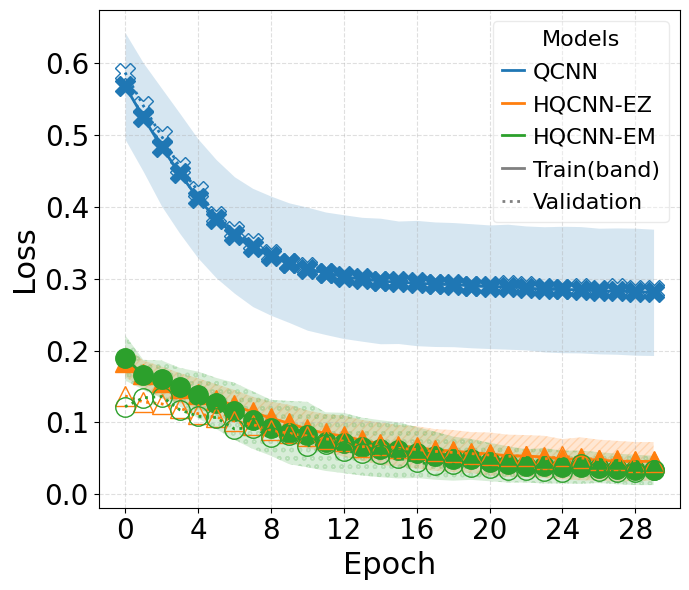

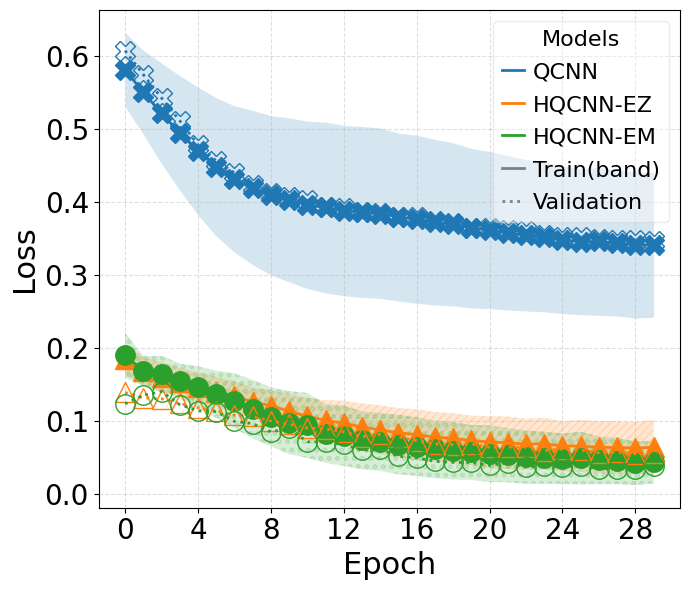

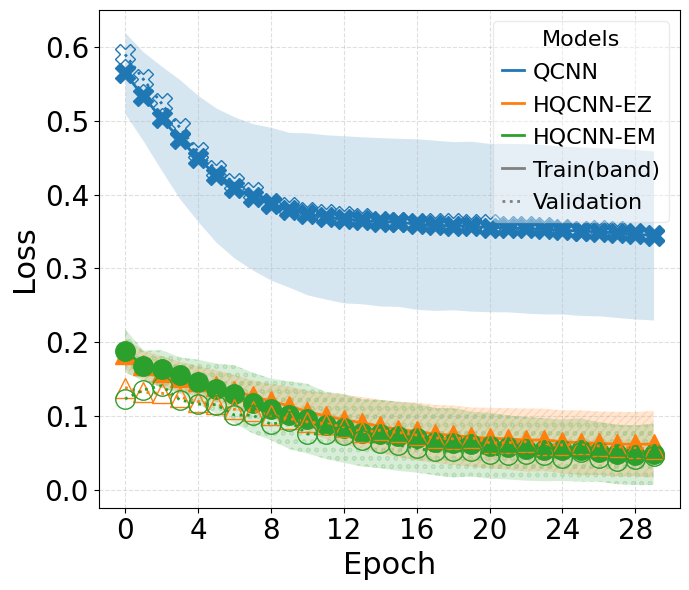

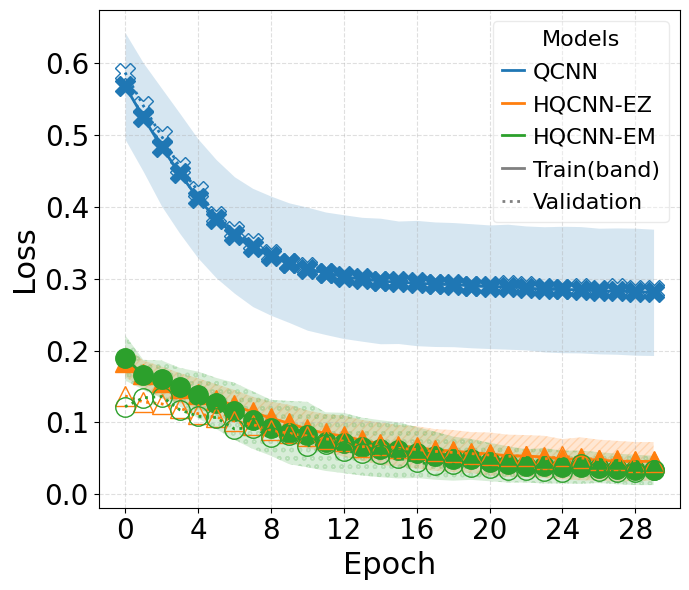

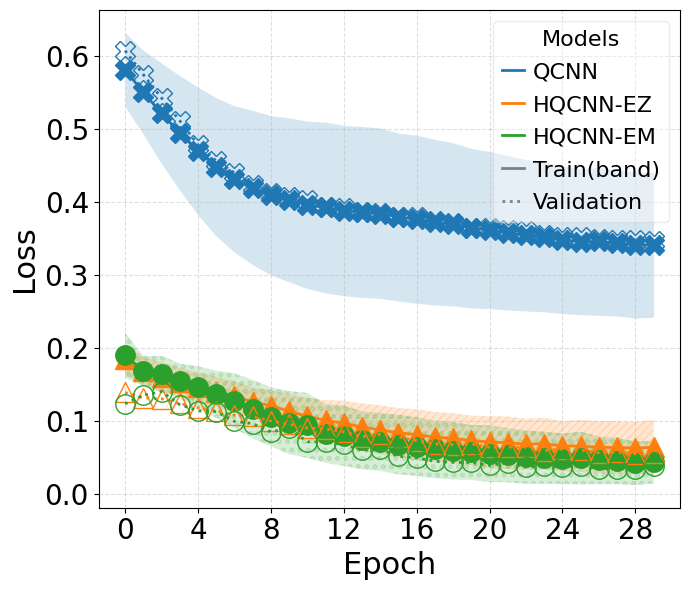

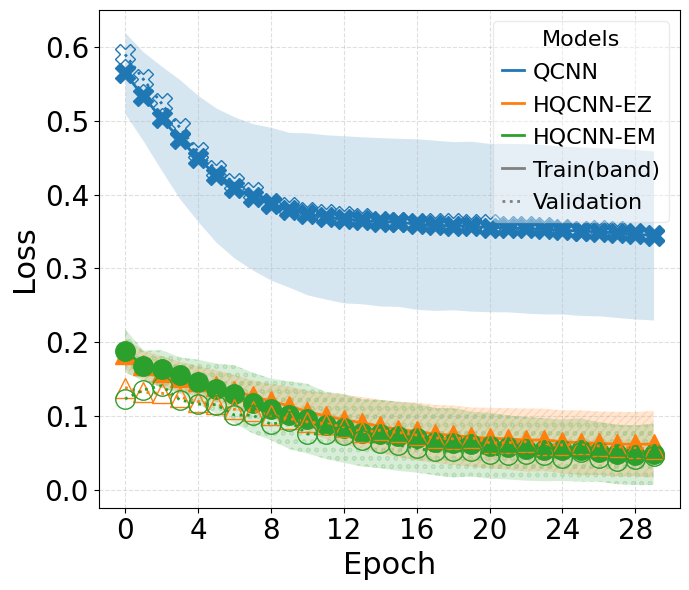

In [16]:
# Plot loss curves for each device and each convolution filter
conv_filters = ['ConvSimple']
for num_qubit in num_qubits:
    for device_name in device_names:
        for conv_filter in conv_filters:
            plot_loss_curves_type2_filtered(num_qubit, device_name, conv_filter, 
                                            plot_title=None,
                                            legend_show=True,
                                            plot_save=PLOT_SAVE)

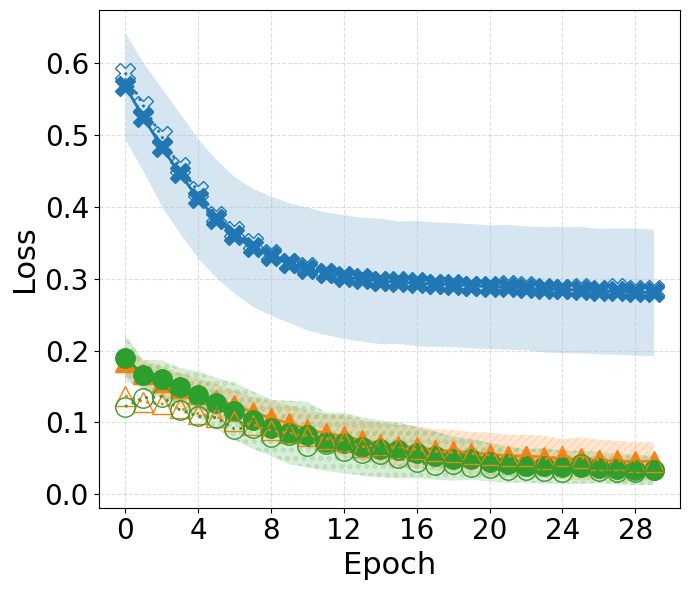

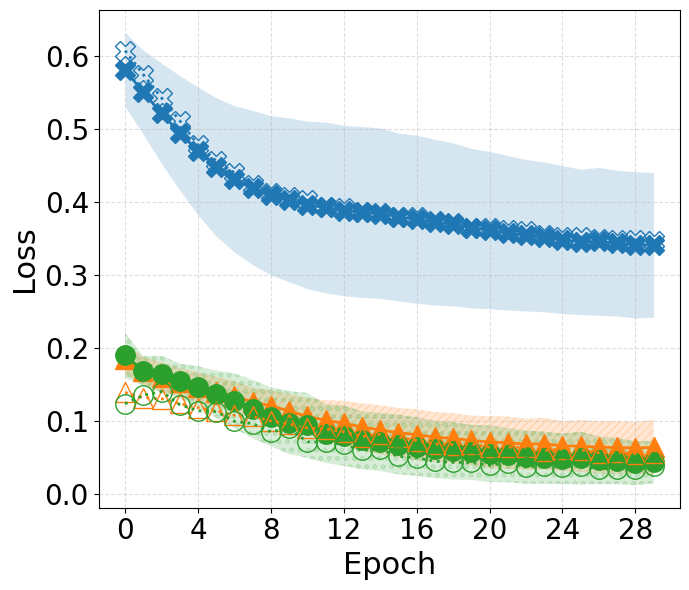

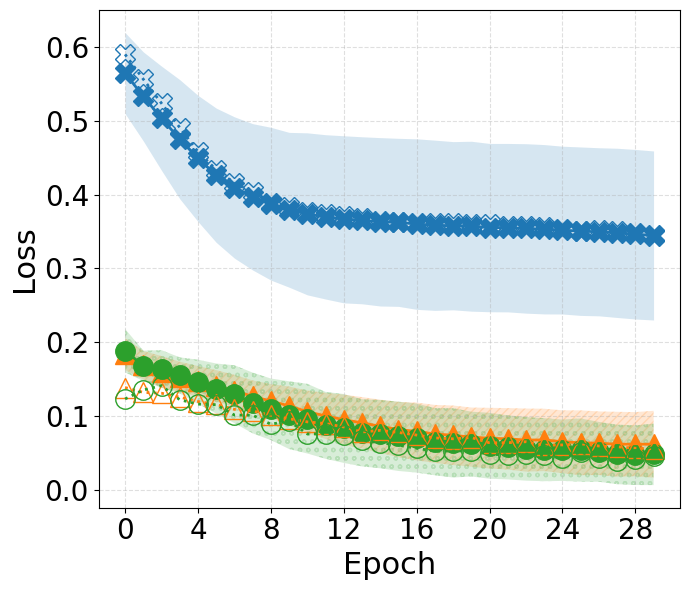

In [17]:
# Plot loss curves for each device and each convolution filter
conv_filters = ['ConvSimple']
for num_qubit in num_qubits:
    if num_qubit != 8:
        continue
    for device_name in device_names:
        for conv_filter in conv_filters:
            plot_loss_curves_type2_filtered(num_qubit, device_name, conv_filter, 
                                            plot_title=None,
                                            legend_show=False,
                                            plot_save=PLOT_SAVE)

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator

def plot_batch_loss_curves_type2_filtered(num_qubit, device, conv_filter_str, legend_show=False, plot_save=False):
    plt.figure(figsize=(6, 5))

    # ---- Filter & prep ----
    plot_data = batch_loss_df[
        (batch_loss_df['Device'] == device) &
        (batch_loss_df['Model_spec'].str.contains(conv_filter_str))
    ].copy()
    
    plot_data["Device"] = plot_data["Device"].replace(
        {"AerSim with backend noise": "AerSim (IBM-Yonsei)"}
        )

    # Encode fractional position within epoch for batch-level x-axis
    # (Epoch + batch/(max_batch+1)) so batches are in (epoch, epoch+1)
    plot_data['Loss Type'] = 'Train'
    plot_data['Combined_X'] = plot_data['Epoch'] + plot_data['Batch'] / (plot_data['Batch'].max() + 1.0)
    plot_data['Batch Loss'] = plot_data['Train_batch_Loss']

    # ---- Styling maps (match your final epoch-loss function) ----
    unique_models = plot_data['Model'].unique()
    marker_shapes = ["X", "^", "o"]
    model_marker_map = {m: marker_shapes[i % len(marker_shapes)] for i, m in enumerate(unique_models)}

    color_palette = sns.color_palette("tab10", len(unique_models))
    model_color_map = {m: color_palette[i] for i, m in enumerate(unique_models)}

    # HATCHES PER MODEL
    hatch_patterns = [None, "////", "oo", "....", "xx", "\\\\", "||", "++"]
    model_hatch_map = {m: hatch_patterns[i % len(hatch_patterns)] for i, m in enumerate(unique_models)}

    # ---- TRAIN: manual ±SD band + mean line per model ----
    for m in unique_models:
        df_m = plot_data[plot_data['Model'] == m]
        if df_m.empty:
            continue

        g = df_m.groupby("Combined_X")["Batch Loss"]
        mu = g.mean()
        sd = g.std(ddof=1).fillna(0.0)

        x = mu.index.values
        y = mu.values
        y_lo = y - sd.values
        y_hi = y + sd.values

        c  = model_color_map[m]
        mk = model_marker_map[m]
        ht = model_hatch_map[m]

        # Band (hatched per model)
        plt.fill_between(
            x, y_lo, y_hi,
            facecolor=c,
            alpha=0.20,
            hatch=ht,
            edgecolor=c,
            linewidth=0.0,
            zorder=1
        )

        # Mean line
        plt.plot(
            x, y,
            color=c,
            linestyle='-',
            marker=mk, markersize=4,
            linewidth=1.5,
            zorder=2
        )

    # ---- Axes / title / grid ----
    title_device = "AerSim (IBM-Yonsei)" if device == "AerSim with backend noise" else device
    plt.title(f'Batch Loss Curves: All Models\n(Device: {title_device})', fontsize=14)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Batch Loss', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    ax = plt.gca()
    # Show integer epoch ticks even though x is fractional
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid(True, linestyle='--', alpha=0.7)
    # plt.ylim(0.15, 0.80)

    # ---- Legend ----
    if legend_show:
        legend_elements = []
        for m in unique_models:
            short_model = m.split("_", 1)[-1]
            label = f"{short_model}_q{num_qubit}"
            legend_elements.append(
                plt.Line2D([0], [0], color=model_color_map[m], lw=2, label=label)
            )
        legend_elements.append(
            plt.Line2D([0], [0], color='gray', lw=2, linestyle='-', label='Train (band = ±SD)')
        )
        plt.legend(handles=legend_elements, title='Models', title_fontsize=12, fontsize=10)

    plt.tight_layout()

    # ---- Save / show ----
    if plot_save:
        filename = (save_summary_results_dirs +
                    f'Batch Loss {problem_type}_Models：q{num_qubit}_{device}' +
                    ('_lg.png' if legend_show else '.png'))
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Plot saved as {filename}")
    else:
        plt.show()

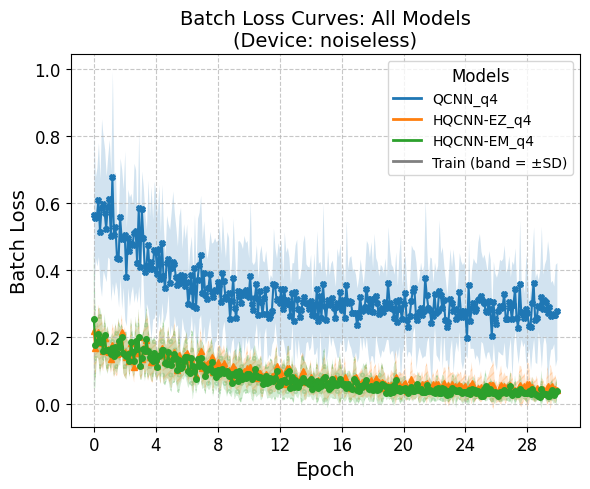

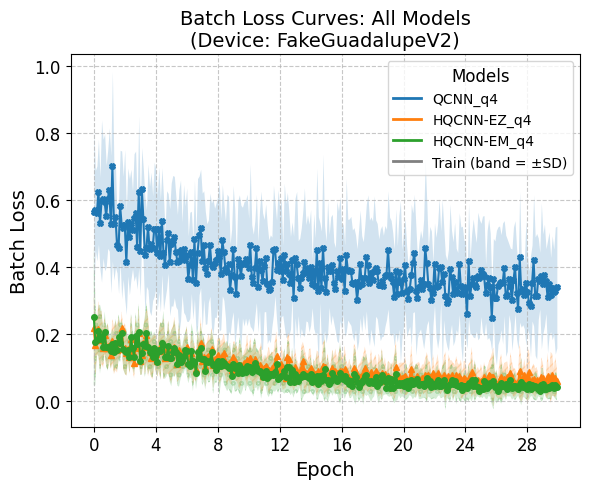

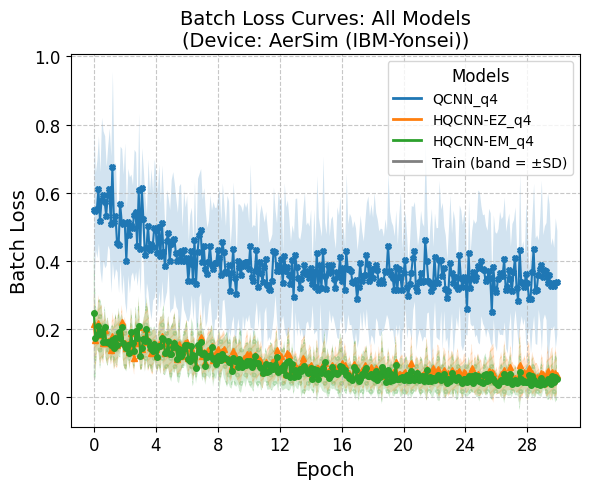

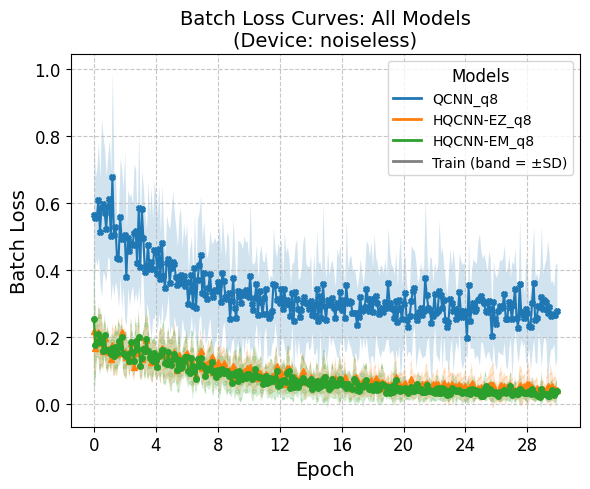

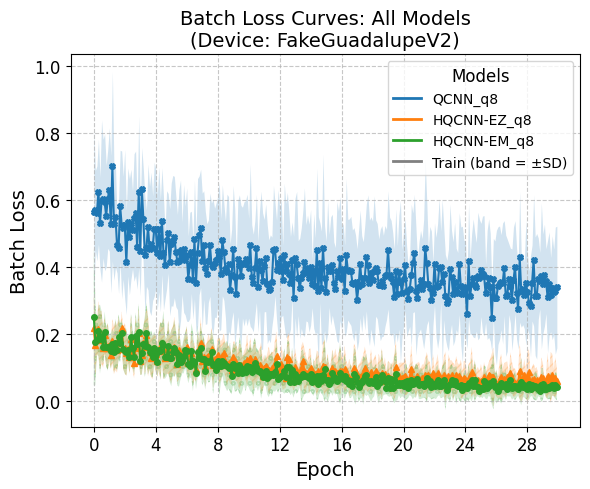

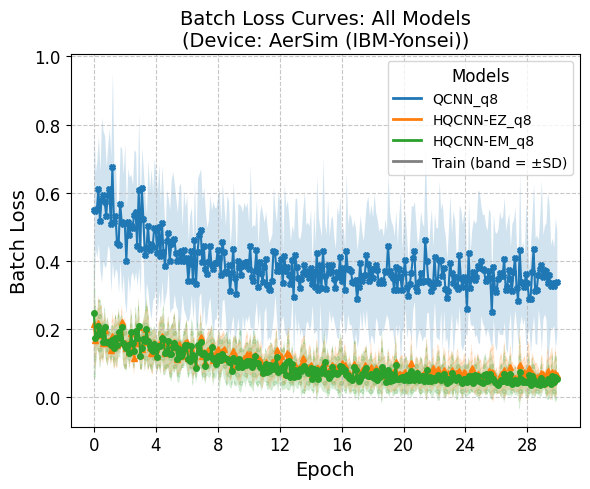

In [19]:
# Plot loss curves for each device and each convolution filter
conv_filters = ['ConvSimple']
for num_qubit in num_qubits:
    for device in device_names:
        for conv_filter in conv_filters:
            plot_batch_loss_curves_type2_filtered(num_qubit, device, conv_filter, legend_show=True,
                                                  plot_save=False)

### Training loss graph

In [20]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import numpy as np  # make sure this is imported
from matplotlib.legend_handler import HandlerTuple

def plot_loss_curves_type3_filtered(
        num_qubit, device, conv_filter_str, 
        plot_title='Loss Curves: All Models',
        legend_show=False, plot_save=False,
        ax=None,
        zoom=False,
        zoom_xlim=None,         # e.g. (5, 15)  -> x1, x2
        zoom_ylim=None,         # e.g. (0.0, 0.3) -> y1, y2
        zoom_box=(0.6, 0.2, 0.35, 0.35),  # [left, bottom, width, height] in axes fraction
    ):

    # draw on given subplot if provided; otherwise make a new fig
    if ax is not None:
        plt.sca(ax)
    else:
        plt.figure(figsize=(7, 6))

    # Prepare the data based on the Device and convolution filter
    plot_data = loss_df[(loss_df['Device'] == device) &
                        (loss_df['Model_spec'].str.contains(conv_filter_str, na=False)) &
                        (loss_df['Qubits'] == num_qubit)].copy()
    plot_data['Loss Type'] = 'Train'
    plot_data_val = plot_data.copy()
    plot_data_val['Loss Type'] = 'Validation'
    plot_data_val['Loss'] = plot_data_val['Validation Loss']
    plot_data['Loss'] = plot_data['Train Loss']

    unique_models = plot_data['Model'].unique()
    marker_shapes = ["X", "^", "o"]
    model_marker_map = {m: marker_shapes[i % len(marker_shapes)] for i, m in enumerate(unique_models)}

    color_palette = sns.color_palette("tab10", len(unique_models))
    model_color_map = {m: color_palette[i] for i, m in enumerate(unique_models)}

    hatch_patterns = [None, "////", "oo", "....", "xx", "\\\\", "||", "++"]
    model_hatch_map = {m: hatch_patterns[i % len(hatch_patterns)] for i, m in enumerate(unique_models)}

    # ==== TRAIN: ±SD band + solid mean line (MAIN AXES) ====
    for m in unique_models:
        df_m = plot_data[plot_data['Model'] == m]
        if df_m.empty:
            continue

        g  = df_m.groupby("Epoch")["Loss"]
        mu = g.mean()
        sd = g.std(ddof=1).fillna(0.0)

        x = mu.index.values
        y = mu.values
        y_lo = y - sd.values
        y_hi = y + sd.values

        c  = model_color_map[m]
        mk = model_marker_map[m]
        ht = model_hatch_map[m]
        short_label = m.split("_", 1)[-1] if "_" in m else m  # <-- for shared legend

        plt.fill_between(x, y_lo, y_hi, facecolor=c, alpha=0.18,
                         hatch=ht, edgecolor=c, linewidth=0.0, zorder=1)

        plt.plot(x, y, color=c, linestyle='-',
                 marker=mk, markersize=7, linewidth=1.5, zorder=2,
                 label=short_label)  # <-- add label on TRAIN line only

    # ==== VALIDATION: dotted mean line (MAIN AXES) ====
    for m in unique_models:
        df_mv = plot_data_val[plot_data_val['Model'] == m]
        if df_mv.empty:
            continue

        gv   = df_mv.groupby("Epoch")["Loss"]
        mu_v = gv.mean()

        xv = mu_v.index.values
        yv = mu_v.values

        c  = model_color_map[m]
        mk = model_marker_map[m]
        plt.plot(xv, yv, color=c, linestyle=':',
                 marker=mk, markersize=7, markerfacecolor='none',
                 linewidth=1.5, zorder=2)

    # Axes cosmetics
    title_device = "AerSim (IBM-Yonsei)" if device == "AerSim with backend noise" else device
    if plot_title and ax is None:  # only if standalone
        plt.title(f'Loss Curves: All Models, {num_qubit}-qubits\n(Device: {title_device})', fontsize=24)
    plt.xlabel('Epoch', fontsize=22 if ax is None else 12)
    plt.ylabel('Loss',  fontsize=22 if ax is None else 12)
    ax_cur = plt.gca()
    ax_cur.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.ylim(0.0, 0.7)

    # --------- ZOOM BOX: same style as your example ---------
    if zoom:
        # --- 1. Define zoom area (x1, x2, y1, y2) ---

        # X-range
        if zoom_xlim is None:
            # default: use full epoch range
            all_epochs = plot_data["Epoch"].unique()
            x1, x2 = all_epochs.min(), all_epochs.max()
        else:
            x1, x2 = zoom_xlim

        # Y-range
        if zoom_ylim is None:
            # compute from data restricted to [x1, x2]
            mask_train = (plot_data["Epoch"] >= x1) & (plot_data["Epoch"] <= x2)
            mask_val   = (plot_data_val["Epoch"] >= x1) & (plot_data_val["Epoch"] <= x2)

            ys = []
            if mask_train.any():
                ys.append(plot_data.loc[mask_train, "Loss"].values)
            if mask_val.any():
                ys.append(plot_data_val.loc[mask_val, "Loss"].values)

            if ys:
                ys = np.concatenate(ys)
                y1, y2 = ys.min(), ys.max()
                pad = 0.05 * (y2 - y1 if y2 > y1 else 1.0)
                y1 -= pad
                y2 += pad
            else:
                y1, y2 = 0.0, 0.7
        else:
            y1, y2 = zoom_ylim

        # --- 2. Create inset axes (zoom box) like your example ---
        # zoom_box = [left, bottom, width, height] in (0–1) axes fraction
        left, bottom, width, height = zoom_box
        axins = ax_cur.inset_axes(
            [left, bottom, width, height],
            xlim=(x1, x2),
            ylim=(y1, y2),
            xticklabels=[],
            yticklabels=[]
        )

        # --- 3. Plot the same data inside the inset ---
        # TRAIN (mean only; you can also re-add bands if you want)
        for m in unique_models:
            df_m = plot_data[plot_data["Model"] == m]
            if df_m.empty:
                continue

            g  = df_m.groupby("Epoch")["Loss"]
            mu = g.mean()
            x  = mu.index.values
            y  = mu.values

            c  = model_color_map[m]
            mk = model_marker_map[m]
            axins.plot(x, y, color=c, linestyle='-',
                       marker=mk, markersize=4, linewidth=1.5)

        # VALIDATION
        for m in unique_models:
            df_mv = plot_data_val[plot_data_val["Model"] == m]
            if df_mv.empty:
                continue

            gv   = df_mv.groupby("Epoch")["Loss"]
            mu_v = gv.mean()
            xv   = mu_v.index.values
            yv   = mu_v.values

            c  = model_color_map[m]
            # mk = model_marker_map[m]
            axins.plot(xv, yv, color=c, linestyle=':',
                       marker=mk, 
                       markersize=4, markerfacecolor='none',
                       linewidth=2.0)

        axins.grid(True, linestyle='--', alpha=0.3)

        # --- 4. Draw connection lines like in your example ---
        # This is exactly: ax.indicate_inset_zoom(axins, ...)
        ax_cur.indicate_inset_zoom(axins, edgecolor="black", linestyle="--")
    
    # === LEGEND CONSTRUCTION ===
    legend_elements = []
    
    # 1. Start with a "Pure Line" representative for the style
    # This ensures the solid/dotted line is clearly visible on the left
    train_handles = [plt.Line2D([0], [0], color='gray', lw=2, linestyle='-', marker=None)]
    val_handles   = [plt.Line2D([0], [0], color='gray', lw=2, linestyle=':', marker=None)]
    
    for m in unique_models:
        short_model = m.split("_", 1)[-1]
        label = f"{short_model}"
        
        # Standard Model Legend Item (remains the same)
        legend_elements.append(
            plt.Line2D([0], [0],
                       color=model_color_map[m],
                       lw=2,
                       marker=model_marker_map[m],
                       markersize=10,
                       label=label),
        )
    
        # 2. Add Markers ONLY (linestyle='None')
        # We removed the line here so it doesn't clutter the view
        train_mk = plt.Line2D([0], [0], color='gray',
                           marker=model_marker_map[m], 
                           linestyle='None',   # <--- CHANGED: No line, just marker
                           markersize=10, 
                           markerfacecolor='gray')
        train_handles.append(train_mk)
        
        val_mk = plt.Line2D([0], [0], color='gray',
                           marker=model_marker_map[m], 
                           linestyle='None',   # <--- CHANGED: No line, just marker
                           markersize=10, 
                           markerfacecolor='none')
        val_handles.append(val_mk)
    
    train_handles.append(plt.Line2D([0], [0], color='gray', lw=2, linestyle='-', marker=None))
    val_handles.append(plt.Line2D([0], [0], color='gray', lw=2, linestyle=':', marker=None))
    
    # Append the lists as TUPLES
    legend_elements.append(tuple(train_handles))
    legend_elements.append(tuple(val_handles))        
    
    legend_labels = [h.get_label() for h in legend_elements if not isinstance(h, tuple)]
    legend_labels.extend(["Train (Band)", "Validation"])
    
    # --- Return handles instead of drawing legend ---
    if legend_show:
        plt.legend(handles=legend_elements,
                   labels=legend_labels,
                   title="Models",
                   handler_map={tuple: HandlerTuple(ndivide=None, pad=1)},
                   handlelength=2,
                   handleheight=1,
                   handletextpad=0.4,
                   title_fontsize=20,
                   fontsize=20,
                   framealpha=0.4)
        
    return legend_elements, legend_labels

    
    # # Local legend only if requested
    # legend_elements = []
    # for m in unique_models:
    #     short_model = m.split("_", 1)[-1]
    #     label = f"{short_model}"
    #     legend_elements.append(
    #         plt.Line2D([0], [0],
    #                    color=model_color_map[m],
    #                    lw=2,
    #                    marker=model_marker_map[m],
    #                    markersize=10,
    #                    label=label)
    #     )
    # legend_elements.extend([
    #     plt.Line2D([0], [0], color='gray', 
    #                lw=2, linestyle='-', 
    #                marker='s', markersize=8, markerfacecolor='gray',
    #                label='Train(band)'),
    #     plt.Line2D([0], [0], color='gray',
    #                lw=2, linestyle=':',
    #             #    marker='s', markersize=8, markerfacecolor='none',
    #                label='Validation'),
    # ])

    # if legend_show:
    #     plt.legend(handles=legend_elements,
    #                title="Models",
    #                handlelength=1,
    #                handleheight=1,
    #                handletextpad=0.4,
    #                title_fontsize=20,
    #                fontsize=20,
    #                framealpha=0.4)

    # return legend_elements


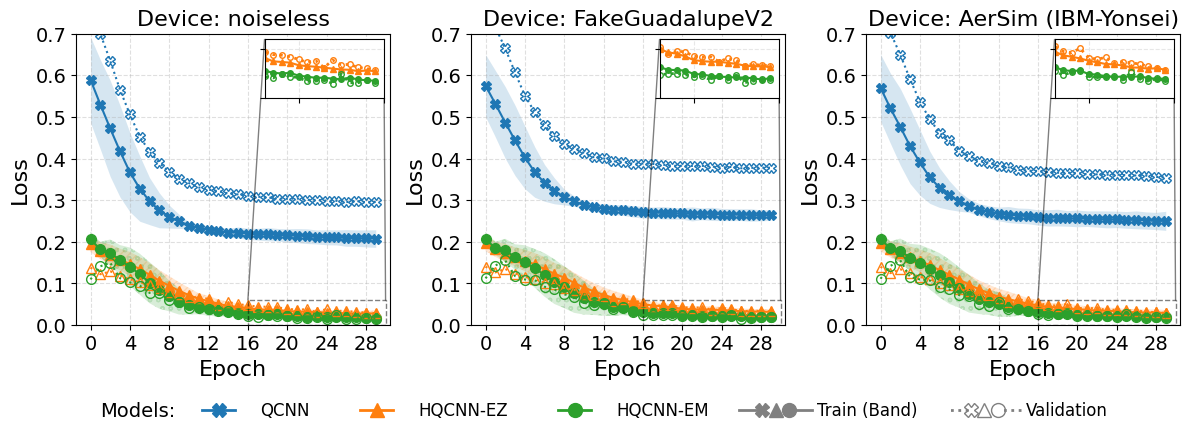

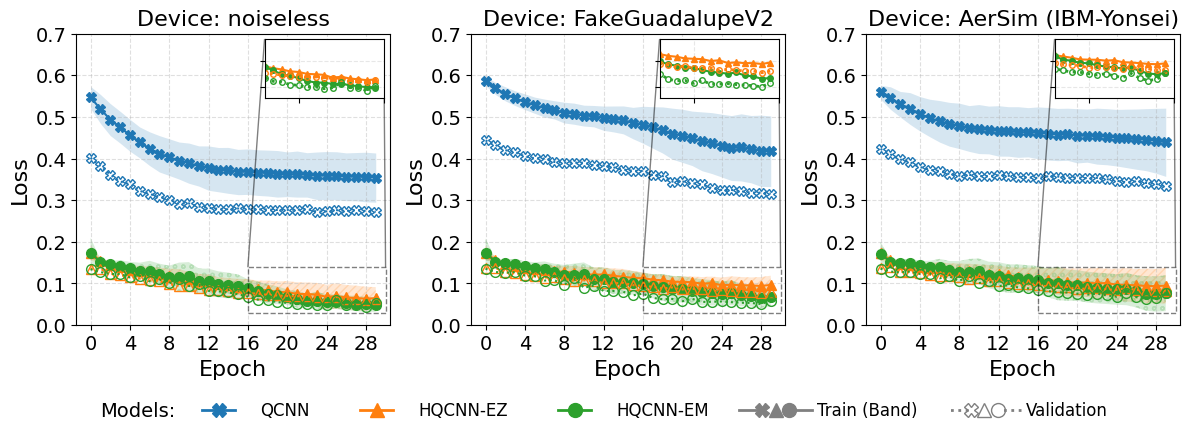

In [21]:
import matplotlib.pyplot as plt

CONV_FILTER = 'ConvSimple'

# === FONT SIZE SETTINGS (centralized here) ===
title_font      = 20   # shared figure title
subplot_title   = 16   # per-device title
axis_label_font = 16   # x/y axis label
tick_font       = 14   # axis tick labels
legend_font     = 12   # legend text
legend_title    = 12   # legend title (if shown)

# === ZOOM SETTINGS (like x1, x2, y1, y2 in your example) ===
# ZOOM_ON   = True
# ZOOM_XLIM = (16, 30)           # epochs to zoom into (adjust to your data)
# ZOOM_YLIM = (0.0, 0.10)        # loss range in zoom box
# ZOOM_BOX  = (0.60, 0.78, 0.38, 0.20)  # [left, bottom, width, height] in axes fraction

# Map qubit count -> (xlim, ylim, box_position)
ZOOM_CONFIGS = {
    4: {
        'xlim': (16, 30),
        'ylim': (0.0, 0.06),
        'box':  (0.60, 0.78, 0.38, 0.20)
    },
    8: {
        'xlim': (16, 30),
        'ylim': (0.03, 0.14),
        'box':  (0.60, 0.78, 0.38, 0.20)
    }
}

for num_qubit in num_qubits:
    # === Create subplots ===
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    legend_handles = None  # prepare to store legend once

    # 1. Get the specific settings for this qubit count
    #    (If num_qubit isn't in the dict, provide a default or handle error)
    if num_qubit in ZOOM_CONFIGS:
        current_zoom_xlim = ZOOM_CONFIGS[num_qubit]['xlim']
        current_zoom_ylim = ZOOM_CONFIGS[num_qubit]['ylim']
        current_zoom_box  = ZOOM_CONFIGS[num_qubit]['box']
        current_zoom_on   = True
    else:
        # Fallback if you have a qubit count not listed in configs
        current_zoom_on = False
        current_zoom_xlim, current_zoom_ylim, current_zoom_box = None, None, None
        
    for i, ax in enumerate(axes):
        device = device_names[i]

        # draw into this subplot
        legend_handles, legend_labels = plot_loss_curves_type3_filtered(
            num_qubit=num_qubit,
            device=device,
            conv_filter_str=CONV_FILTER,
            plot_title=None,
            legend_show=False,
            plot_save=False,
            ax=ax,
            
            # ---- ZOOM ARGS ----
            # zoom=ZOOM_ON,
            # zoom_xlim=ZOOM_XLIM,   # (x1, x2)
            # zoom_ylim=ZOOM_YLIM,   # (y1, y2)
            # zoom_box=ZOOM_BOX      # same location for every subplot
            
            # ---- PASS DYNAMIC SETTINGS HERE ----
            zoom=current_zoom_on,
            zoom_xlim=current_zoom_xlim,  # Uses the variable we set above
            zoom_ylim=current_zoom_ylim, 
            zoom_box=current_zoom_box
        )

        # per-subplot title
        pretty = "AerSim (IBM-Yonsei)" if device == "AerSim with backend noise" else device
        ax.set_title(f"Device: {pretty}", fontsize=subplot_title)

        # axis labels
        ax.set_xlabel("Epoch", fontsize=axis_label_font)
        ax.set_ylabel("Loss", fontsize=axis_label_font)

        # tick label sizes
        ax.tick_params(axis='both', which='major', labelsize=tick_font)

    # ---- Shared legend using returned handles ----
    if legend_handles:
        fig.legend(
            handles=legend_handles,
            labels=legend_labels,
            handler_map={tuple: HandlerTuple(ndivide=None, pad=2.0)},
            loc='upper center',
            bbox_to_anchor=(0.55, 0.02),
            ncol=6,
            frameon=False,
            # title="Models",
            title_fontsize=legend_title,
            fontsize=legend_font,
            
            # NEW: make legend samples bigger so dashed lines are visible
            handlelength=2.0,   # longer line segment -> clearer dashes
            markerscale=1.0,    # bigger marker in legend
            handletextpad=1.5,  # spacing between handle and text
            columnspacing=3   # spacing between legend columns
        )
        
        # Add external text label on the left or right side of the legend
        fig.text(0.15, -0.04, "Models:", ha='right', va='center',
                 fontsize=legend_font + 2)  # adjust x,y as needed

    # layout adjustment
    plt.tight_layout()

    # ---- SAVE PLOT AS PDF ----
    if PLOT_SAVE:
        filename = (save_summary_results_dirs +
                    f'Loss_{problem_type}_Models-q{num_qubit}_zoom.pdf')
        fig.savefig(filename, dpi=300, bbox_inches='tight', format='pdf')
        print(f"Plot saved as {filename}")

    plt.show()

### Performance Summary

In [22]:
performance_df

,Device,Qubits,Model,Model_spec,sim_iter_num,Dataset,MAE,MSE,RMSE,R-squared,Adj R-squared
0,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,Train,0.339574,0.185941,0.431209,0.046080,0.005915
1,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,Test,0.423152,0.221851,0.471011,-0.661575,-1.104661
2,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,Train,0.372816,0.210875,0.459212,-0.081841,-0.127392
3,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,Test,0.400978,0.220761,0.469852,-0.653411,-1.094320
4,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,2,Train,0.348264,0.190044,0.435941,0.025027,-0.016024
...,...,...,...,...,...,...,...,...,...,...,...
175,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,2,Test,0.264039,0.101557,0.318681,-0.013814,-0.751133
176,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,3,Train,0.272741,0.107601,0.328026,0.271334,0.207275
177,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,3,Test,0.264223,0.103201,0.321250,-0.030224,-0.779478
178,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,Train,0.200985,0.063311,0.251617,0.571262,0.533571


In [23]:
performance_best_df

,Device,Qubits,Model,Model_spec,sim_iter_num,Dataset,MAE,MSE,RMSE,R-squared,Adj R-squared,best_epoch
0,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,Train,0.343353,0.189309,0.435097,0.028799,-0.012094,27
1,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,Test,0.419978,0.218579,0.467524,-0.637070,-1.073622,27
2,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,Train,0.372368,0.209231,0.457418,-0.073404,-0.118600,29
3,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,Test,0.395515,0.215966,0.464722,-0.617500,-1.048834,29
4,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,2,Train,0.351875,0.197668,0.444598,-0.014082,-0.056780,18
...,...,...,...,...,...,...,...,...,...,...,...,...
175,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,2,Test,0.264068,0.101941,0.319282,-0.017644,-0.757749,6
176,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,3,Train,0.197864,0.061508,0.248009,0.583470,0.546852,27
177,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,3,Test,0.199209,0.070822,0.266124,0.293009,-0.221167,27
178,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,Train,0.193650,0.062327,0.249654,0.577924,0.540818,27


In [24]:
import pandas as pd

def summarize_performance(performance_df, problem_type="reg"):

    if problem_type == 'reg':
        # Metrics of interest
        mean_values = ['MAE', 'MSE', 'R-squared', 'Adj R-squared']
        
        # Mean & std
        group_by_features = ['Device', 'Dataset', 'Model', 'Qubits']
        # group_by_features = ['Device', 'Dataset', 'Model', 'Model_spec']
        summary_mean = performance_df.groupby(group_by_features)[mean_values].mean()
        summary_std = performance_df.groupby(group_by_features)[mean_values].std()

        # Rename std columns
        summary_std = summary_std.rename(columns={
            'MAE': 'MAE_std', 
            'MSE': 'MSE_std', 
            'R-squared': 'R-squared_std', 
            'Adj R-squared': 'Adj R-squared_std'
        })

        # Combine mean & std
        summary = pd.concat([summary_mean, summary_std], axis=1)

        # Round for readability
        summary = summary.round(6)

        # Column order
        summary = summary[[
            'MAE', 'MAE_std', 
            'MSE', 'MSE_std', 
            'R-squared', 'R-squared_std', 
            'Adj R-squared', 'Adj R-squared_std'
        ]]

        # Sort index
        summary = summary.sort_index(
            level=['Device', 'Dataset', 'Model'],
            ascending=[False, False, True])

    elif problem_type == 'clf':
        # Metrics of interest
        mean_values = ['binary_cross_entropy_loss', 'accuracy']
        
        # Mean & std
        group_by_features = ['Device', 'Dataset', 'Model', 'Qubits']
        # group_by_features = ['Device', 'Dataset', 'Model', 'Model_spec']
        summary_mean = performance_df.groupby(group_by_features)[mean_values].mean()
        summary_std = performance_df.groupby(group_by_features)[mean_values].std()

        # Rename std columns
        summary_std = summary_std.rename(columns={
            'binary_cross_entropy_loss': 'binary_cross_entropy_loss_std',
            'accuracy': 'accuracy_std'
        })

        # Combine mean & std
        summary = pd.concat([summary_mean, summary_std], axis=1)

        # Round for readability
        summary = summary.round(6)

        # Column order
        summary = summary[
            ['binary_cross_entropy_loss', 'binary_cross_entropy_loss_std',
             'accuracy', 'accuracy_std']
        ]

        # Sort index
        summary = summary.sort_index(
            level=['Device', 'Dataset', 'Model', 'Qubits'],
            ascending=[False, False, False, True]
            # level=['Device', 'Dataset', 'Model', 'Model_spec'],
            # ascending=[False, False, True, False]
        )

    else:
        raise ValueError("problem_type must be either 'reg' or 'clf'")

    return summary

In [25]:
summary = summarize_performance(performance_df, problem_type=problem_type)
summary

MAE   MAE_std  \
Device                    Dataset Model    Qubits                       
noiseless                 Train   HQCNN-EM 4       0.098466  0.008094   
                                           8       0.184460  0.037535   
                                  HQCNN-EZ 4       0.122694  0.014198   
                                           8       0.193640  0.046539   
                                  QCNN     4       0.364671  0.020052   
                                           8       0.499993  0.051226   
                          Test    HQCNN-EM 4       0.094235  0.007315   
                                           8       0.191773  0.027322   
                                  HQCNN-EZ 4       0.100769  0.009116   
                                           8       0.160903  0.026307   
                                  QCNN     4       0.422005  0.022460   
                                           8       0.475413  0.050360   
FakeGuadalupeV2           Train   HQCNN-EM 4       0.103184  0.008476   
                                           8       0.205180  0.036398   
                                  HQCNN-EZ 4       0.130302  0.018023   
                                           8       0.251620  0.026203   
                                  QCNN     4       0.415983  0.011395   
                                           8       0.546507  0.067004   
                          Test    HQCNN-EM 4       0.088783  0.007578   
                                           8       0.213151  0.024766   
                                  HQCNN-EZ 4       0.121711  0.008997   
                                           8       0.187505  0.026340   
                                  QCNN     4       0.490297  0.019265   
                                           8       0.520205  0.059641   
AerSim with backend noise Train   HQCNN-EM 4       0.102657  0.013041   
                                           8       0.228657  0.061271   
                                  HQCNN-EZ 4       0.131255  0.015813   
                                           8       0.251190  0.048795   
                                  QCNN     4       0.425851  0.013186   
                                           8       0.583113  0.054019   
                          Test    HQCNN-EM 4       0.095244  0.021441   
                                           8       0.232450  0.030984   
                                  HQCNN-EZ 4       0.116303  0.012918   
                                           8       0.198434  0.047982   
                                  QCNN     4       0.505961  0.024812   
                                           8       0.552789  0.050274   

                                                        MSE   MSE_std  \
Device                    Dataset Model    Qubits                       
noiseless                 Train   HQCNN-EM 4       0.016783  0.002391   
                                           8       0.054225  0.018700   
                                  HQCNN-EZ 4       0.026733  0.005466   
                                           8       0.061435  0.025806   
                                  QCNN     4       0.207561  0.020654   
                                           8       0.353087  0.058061   
                          Test    HQCNN-EM 4       0.014384  0.002647   
                                           8       0.055783  0.013660   
                                  HQCNN-EZ 4       0.017672  0.004039   
                                           8       0.045593  0.013137   
                                  QCNN     4       0.229592  0.014777   
                                           8       0.301761  0.062585   
FakeGuadalupeV2           Train   HQCNN-EM 4       0.018134  0.003050   
                                           8       0.067288  0.022596   
                                  HQCNN-EZ 4       0.029929  0.006625   
                                        

In [26]:
summary_best = summarize_performance(performance_best_df, problem_type=problem_type)
summary_best

MAE   MAE_std  \
Device                    Dataset Model    Qubits                       
noiseless                 Train   HQCNN-EM 4       0.102789  0.010608   
                                           8       0.171776  0.035459   
                                  HQCNN-EZ 4       0.122927  0.010173   
                                           8       0.197470  0.046165   
                                  QCNN     4       0.366152  0.018241   
                                           8       0.505577  0.055613   
                          Test    HQCNN-EM 4       0.091595  0.009525   
                                           8       0.188840  0.038013   
                                  HQCNN-EZ 4       0.102237  0.011375   
                                           8       0.175824  0.009376   
                                  QCNN     4       0.422409  0.024202   
                                           8       0.482337  0.056314   
FakeGuadalupeV2           Train   HQCNN-EM 4       0.113952  0.015915   
                                           8       0.201317  0.039152   
                                  HQCNN-EZ 4       0.128084  0.013783   
                                           8       0.250556  0.031089   
                                  QCNN     4       0.416021  0.011864   
                                           8       0.548363  0.067504   
                          Test    HQCNN-EM 4       0.086485  0.014432   
                                           8       0.208433  0.030456   
                                  HQCNN-EZ 4       0.124422  0.012688   
                                           8       0.186676  0.023926   
                                  QCNN     4       0.493187  0.021121   
                                           8       0.521372  0.059296   
AerSim with backend noise Train   HQCNN-EM 4       0.110428  0.013168   
                                           8       0.213792  0.062369   
                                  HQCNN-EZ 4       0.131841  0.023293   
                                           8       0.251067  0.057113   
                                  QCNN     4       0.427461  0.011889   
                                           8       0.584159  0.054338   
                          Test    HQCNN-EM 4       0.096845  0.013703   
                                           8       0.214112  0.032546   
                                  HQCNN-EZ 4       0.123052  0.018320   
                                           8       0.200377  0.048541   
                                  QCNN     4       0.503599  0.020595   
                                           8       0.554762  0.052962   

                                                        MSE   MSE_std  \
Device                    Dataset Model    Qubits                       
noiseless                 Train   HQCNN-EM 4       0.018127  0.003697   
                                           8       0.048654  0.019352   
                                  HQCNN-EZ 4       0.027197  0.004414   
                                           8       0.064445  0.024672   
                                  QCNN     4       0.209226  0.018455   
                                           8       0.360622  0.065648   
                          Test    HQCNN-EM 4       0.014286  0.002456   
                                           8       0.055104  0.017602   
                                  HQCNN-EZ 4       0.017252  0.004140   
                                           8       0.052564  0.006277   
                                  QCNN     4       0.230369  0.017671   
                                           8       0.307029  0.069704   
FakeGuadalupeV2           Train   HQCNN-EM 4       0.023168  0.006737   
                                           8       0.065612  0.023377   
                                  HQCNN-EZ 4       0.029786  0.006132   
                                        

In [27]:
import pandas as pd
from collections.abc import Iterable

def summarize_performance_compact(
    performance_df,
    problem_type,   # 'clf' or 'reg' 
    qubits=None,
    verbose=False,
    round_digits=6,
    sort_levels=None,
    sort_order=None
):
    """
    Summarize classification metrics as 'mean ± std'.

    Parameters
    ----------
    performance_df : pd.DataFrame
        Must include ['Device','Dataset','Model','Qubits', metrics...]
    problem_type : str, only 'clf' supported here
    qubits : int | Iterable[int] | None
        If given, filter rows for these Qubit counts
    verbose : bool
        If True, print which qubits are included
    round_digits : int
        Rounding for mean/std values
    sort_levels : list[str] | None
        Index levels to sort by (e.g., ['Device','Dataset','Model','Qubits'])
    sort_order : list[bool] | None
        Ascending/descending order for each level
    
    Returns
    -------
    pd.DataFrame
        Table with 'binary_cross_entropy_loss' and 'accuracy' as mean ± std strings
    """
    df = performance_df.copy()

    # Filter specific qubits
    if qubits is not None:
        if isinstance(qubits, Iterable) and not isinstance(qubits, (str, bytes)):
            qset = list(qubits)
        else:
            qset = [int(qubits)]
        df = df[df['Qubits'].isin(qset)]
        if verbose:
            print("Filtering to Qubits =", sorted(df['Qubits'].unique().tolist()))

    # if problem_type != 'clf':
    #     raise ValueError("This compact version only supports problem_type='clf'")
    if problem_type == 'clf':
        metrics = ['binary_cross_entropy_loss', 'accuracy']
        
    elif problem_type == 'reg':
        metrics = ['MAE', 'MSE', 'R-squared', 'Adj R-squared']
    group_by_features = ['Device', 'Dataset', 'Model', 'Qubits']

    summary_stats = df.groupby(group_by_features)[metrics].agg(['mean','std'])

    # Build compact "mean ± std" strings
    compact = pd.DataFrame(index=summary_stats.index)
    for m in metrics:
        mu = summary_stats[(m, 'mean')].round(round_digits)
        sd = summary_stats[(m, 'std')].round(round_digits)
        compact[m] = mu.astype(str) + " ± " + sd.astype(str)

    # 🔑 Sort index if requested
    if sort_levels is not None:
        if sort_order is None:
            sort_order = [True] * len(sort_levels)
        compact = compact.sort_index(level=sort_levels, ascending=sort_order)

    return compact

In [28]:
performance_summary = summarize_performance_compact(
    performance_df=performance_best_df,
    problem_type=problem_type,
    qubits=num_qubits,
    verbose=True,
    round_digits=4,
    sort_levels=['Device', 'Dataset', 'Model', 'Qubits'],
    sort_order=[False, False, False, True]
)

performance_summary

Filtering to Qubits = [4, 8]


MAE  \
Device                    Dataset Model    Qubits                    
noiseless                 Train   QCNN     4       0.3662 ± 0.0182   
                                           8       0.5056 ± 0.0556   
                                  HQCNN-EZ 4       0.1229 ± 0.0102   
                                           8       0.1975 ± 0.0462   
                                  HQCNN-EM 4       0.1028 ± 0.0106   
                                           8       0.1718 ± 0.0355   
                          Test    QCNN     4       0.4224 ± 0.0242   
                                           8       0.4823 ± 0.0563   
                                  HQCNN-EZ 4       0.1022 ± 0.0114   
                                           8       0.1758 ± 0.0094   
                                  HQCNN-EM 4       0.0916 ± 0.0095   
                                           8        0.1888 ± 0.038   
FakeGuadalupeV2           Train   QCNN     4        0.416 ± 0.0119   
                                           8       0.5484 ± 0.0675   
                                  HQCNN-EZ 4       0.1281 ± 0.0138   
                                           8       0.2506 ± 0.0311   
                                  HQCNN-EM 4        0.114 ± 0.0159   
                                           8       0.2013 ± 0.0392   
                          Test    QCNN     4       0.4932 ± 0.0211   
                                           8       0.5214 ± 0.0593   
                                  HQCNN-EZ 4       0.1244 ± 0.0127   
                                           8       0.1867 ± 0.0239   
                                  HQCNN-EM 4       0.0865 ± 0.0144   
                                           8       0.2084 ± 0.0305   
AerSim with backend noise Train   QCNN     4       0.4275 ± 0.0119   
                                           8       0.5842 ± 0.0543   
                                  HQCNN-EZ 4       0.1318 ± 0.0233   
                                           8       0.2511 ± 0.0571   
                                  HQCNN-EM 4       0.1104 ± 0.0132   
                                           8       0.2138 ± 0.0624   
                          Test    QCNN     4       0.5036 ± 0.0206   
                                           8        0.5548 ± 0.053   
                                  HQCNN-EZ 4       0.1231 ± 0.0183   
                                           8       0.2004 ± 0.0485   
                                  HQCNN-EM 4       0.0968 ± 0.0137   
                                           8       0.2141 ± 0.0325   

                                                               MSE  \
Device                    Dataset Model    Qubits                    
noiseless                 Train   QCNN     4       0.2092 ± 0.0185   
                                           8       0.3606 ± 0.0656   
                                  HQCNN-EZ 4       0.0272 ± 0.0044   
                                           8       0.0644 ± 0.0247   
                                  HQCNN-EM 4       0.0181 ± 0.0037   
                                           8       0.0487 ± 0.0194   
                          Test    QCNN     4       0.2304 ± 0.0177   
                                           8        0.307 ± 0.0697   
                                  HQCNN-EZ 4       0.0173 ± 0.0041   
                                           8       0.0526 ± 0.0063   
                                  HQCNN-EM 4       0.0143 ± 0.0025   
                                           8       0.0551 ± 0.0176   
FakeGuadalupeV2           Train   QCNN     4       0.2642 ± 0.0124   
                                           8       0.4138 ± 0.0866   
                                  HQCNN-EZ 4       0.0298 ± 0.0061   
                                           8        0.0933 ± 0.021   
                                  HQCNN-EM 4       0.0232 ± 0.0067   
                                           8       0.0656 ± 0.0234   
  

In [29]:
performance_best_summary = summarize_performance_compact(
    performance_df=performance_best_df,
    problem_type=problem_type,
    qubits=num_qubits,
    verbose=True,
    round_digits=4,
    sort_levels=['Device', 'Dataset', 'Model', 'Qubits'],
    sort_order=[False, False, False, True]
)

performance_best_summary

Filtering to Qubits = [4, 8]


MAE  \
Device                    Dataset Model    Qubits                    
noiseless                 Train   QCNN     4       0.3662 ± 0.0182   
                                           8       0.5056 ± 0.0556   
                                  HQCNN-EZ 4       0.1229 ± 0.0102   
                                           8       0.1975 ± 0.0462   
                                  HQCNN-EM 4       0.1028 ± 0.0106   
                                           8       0.1718 ± 0.0355   
                          Test    QCNN     4       0.4224 ± 0.0242   
                                           8       0.4823 ± 0.0563   
                                  HQCNN-EZ 4       0.1022 ± 0.0114   
                                           8       0.1758 ± 0.0094   
                                  HQCNN-EM 4       0.0916 ± 0.0095   
                                           8        0.1888 ± 0.038   
FakeGuadalupeV2           Train   QCNN     4        0.416 ± 0.0119   
                                           8       0.5484 ± 0.0675   
                                  HQCNN-EZ 4       0.1281 ± 0.0138   
                                           8       0.2506 ± 0.0311   
                                  HQCNN-EM 4        0.114 ± 0.0159   
                                           8       0.2013 ± 0.0392   
                          Test    QCNN     4       0.4932 ± 0.0211   
                                           8       0.5214 ± 0.0593   
                                  HQCNN-EZ 4       0.1244 ± 0.0127   
                                           8       0.1867 ± 0.0239   
                                  HQCNN-EM 4       0.0865 ± 0.0144   
                                           8       0.2084 ± 0.0305   
AerSim with backend noise Train   QCNN     4       0.4275 ± 0.0119   
                                           8       0.5842 ± 0.0543   
                                  HQCNN-EZ 4       0.1318 ± 0.0233   
                                           8       0.2511 ± 0.0571   
                                  HQCNN-EM 4       0.1104 ± 0.0132   
                                           8       0.2138 ± 0.0624   
                          Test    QCNN     4       0.5036 ± 0.0206   
                                           8        0.5548 ± 0.053   
                                  HQCNN-EZ 4       0.1231 ± 0.0183   
                                           8       0.2004 ± 0.0485   
                                  HQCNN-EM 4       0.0968 ± 0.0137   
                                           8       0.2141 ± 0.0325   

                                                               MSE  \
Device                    Dataset Model    Qubits                    
noiseless                 Train   QCNN     4       0.2092 ± 0.0185   
                                           8       0.3606 ± 0.0656   
                                  HQCNN-EZ 4       0.0272 ± 0.0044   
                                           8       0.0644 ± 0.0247   
                                  HQCNN-EM 4       0.0181 ± 0.0037   
                                           8       0.0487 ± 0.0194   
                          Test    QCNN     4       0.2304 ± 0.0177   
                                           8        0.307 ± 0.0697   
                                  HQCNN-EZ 4       0.0173 ± 0.0041   
                                           8       0.0526 ± 0.0063   
                                  HQCNN-EM 4       0.0143 ± 0.0025   
                                           8       0.0551 ± 0.0176   
FakeGuadalupeV2           Train   QCNN     4       0.2642 ± 0.0124   
                                           8       0.4138 ± 0.0866   
                                  HQCNN-EZ 4       0.0298 ± 0.0061   
                                           8        0.0933 ± 0.021   
                                  HQCNN-EM 4       0.0232 ± 0.0067   
                                           8       0.0656 ± 0.0234   
  

In [30]:
if SUMMRAY_TABLE_SAVE:
    performance_summary.to_csv(save_summary_results_dirs+'performance_summary_train.csv', encoding="utf-8-sig")
    performance_best_summary.to_csv(save_summary_results_dirs+'performance_best_summary_test.csv', encoding="utf-8-sig")

In [31]:
import pandas as pd

def format_performance_summary(
    performance_summary: pd.DataFrame,
    problem_type: str = "clf",
    qubit_order: list[int] = [4, 8, 10]
) -> pd.DataFrame:
    """
    Reformat performance summary DataFrame into hierarchical MultiIndex columns:
    Task -> Qubits -> Metrics
    
    Parameters
    ----------
    performance_summary : pd.DataFrame
        Compact summary from summarize_performance_compact
    problem_type : str, default "clf". Other value is "Regression Task"
        Label for the top-level column header
    qubit_order : list[int], default [4, 8, 10]
        Order of qubits to appear in columns
    
    Returns
    -------
    pd.DataFrame
        Formatted DataFrame with hierarchical MultiIndex columns
    """
    # Pivot to wide format with reordered index: Dataset → Device → Model
    if problem_type == 'clf':
        task_name = "Classification Task"
        
        wide = (
        performance_summary
          .reset_index()
          .pivot(
              index=['Dataset', 'Device', 'Model'],
              columns='Qubits',
              values=['binary_cross_entropy_loss', 'accuracy']
              )
          )

        # Reorder columns (Qubits -> Metric)
        wide = wide.swaplevel(0, 1, axis=1)
        wide = wide.reindex(qubit_order, axis=1, level=0)

        # Rename metrics (fixed order)
        wide = wide.rename(columns={
            'binary_cross_entropy_loss': 'BCE',
            'accuracy': 'Accuracy'
            })
        metric_order = ["BCE", "Accuracy"]

        # Rebuild hierarchical columns: Task -> Qubits -> Metric
        wide.columns = pd.MultiIndex.from_product(
            [[problem_type], qubit_order, metric_order],
            names=["Task", "Qubits", "Metric"]
            )

        # ✅ Rename specific Device labels
        wide = wide.rename(
            index={"AerSim with backend noise": "AerSim (IBM-Yonsei)"},
            level="Device"
            )

        # Sort index: Dataset (descending), Device (descending)
        wide = wide.sort_index(level=["Dataset", "Device", 'Model'], ascending=[False, False, False])
    
    elif problem_type == 'reg':
        task_name = "Classification Task"
        
        wide = (
        performance_summary
          .reset_index()
          .pivot(
              index=['Dataset', 'Device', 'Model'],
              columns='Qubits',
              values=['MAE', 'MSE', 'R-squared', 'Adj R-squared']
              )
          )
        
        # Reorder columns (Qubits -> Metric)
        wide = wide.swaplevel(0, 1, axis=1)
        wide = wide.reindex(qubit_order, axis=1, level=0)

        # Rename metrics (fixed order)
        wide = wide.rename(columns={
            'MAE': 'MAE',
            'MSE': 'MSE',
            'R-squared': 'R-squared',
            'Adj R-squared': 'Adj R-squared'
            })
        metric_order = ["MAE", "MSE", "R-squared", "Adj R-squared"]

        # Rebuild hierarchical columns: Task -> Qubits -> Metric
        wide.columns = pd.MultiIndex.from_product(
            [[problem_type], qubit_order, metric_order],
            names=["Task", "Qubits", "Metric"]
        )

        # ✅ Rename specific Device labels
        wide = wide.rename(
            index={"AerSim with backend noise": "AerSim (IBM-Yonsei)"},
            level="Device"
        )

        # Sort index: Dataset (descending), Device (descending)
        wide = wide.sort_index(level=["Dataset", "Device", 'Model'], ascending=[False, False, False])
    
    return wide

In [32]:
performance_summary_formated = format_performance_summary(
    performance_summary,
    problem_type=problem_type,
    qubit_order=num_qubits
)

performance_best_summary_formated = format_performance_summary(
    performance_best_summary,
    problem_type=problem_type,
    qubit_order=num_qubits
)

performance_best_summary_formated

Task                                              reg                   \
Qubits                                              4                    
Metric                                            MAE              MSE   
Dataset Device              Model                                        
Train   noiseless           QCNN      0.3662 ± 0.0182  0.2092 ± 0.0185   
                            HQCNN-EZ  0.1229 ± 0.0102  0.0272 ± 0.0044   
                            HQCNN-EM  0.1028 ± 0.0106  0.0181 ± 0.0037   
        FakeGuadalupeV2     QCNN       0.416 ± 0.0119  0.2642 ± 0.0124   
                            HQCNN-EZ  0.1281 ± 0.0138  0.0298 ± 0.0061   
                            HQCNN-EM   0.114 ± 0.0159  0.0232 ± 0.0067   
        AerSim (IBM-Yonsei) QCNN      0.4275 ± 0.0119  0.2775 ± 0.0161   
                            HQCNN-EZ  0.1318 ± 0.0233  0.0312 ± 0.0092   
                            HQCNN-EM  0.1104 ± 0.0132   0.022 ± 0.0047   
Test    noiseless           QCNN      0.4224 ± 0.0242  0.2304 ± 0.0177   
                            HQCNN-EZ  0.1022 ± 0.0114  0.0173 ± 0.0041   
                            HQCNN-EM  0.0916 ± 0.0095  0.0143 ± 0.0025   
        FakeGuadalupeV2     QCNN      0.4932 ± 0.0211  0.3057 ± 0.0153   
                            HQCNN-EZ  0.1244 ± 0.0127  0.0255 ± 0.0064   
                            HQCNN-EM  0.0865 ± 0.0144  0.0131 ± 0.0046   
        AerSim (IBM-Yonsei) QCNN      0.5036 ± 0.0206   0.322 ± 0.0191   
                            HQCNN-EZ  0.1231 ± 0.0183   0.026 ± 0.0059   
                            HQCNN-EM  0.0968 ± 0.0137  0.0153 ± 0.0034   

Task                                                                      \
Qubits                                                                     
Metric                                       R-squared     Adj R-squared   
Dataset Device              Model                                          
Train   noiseless           QCNN      -0.0734 ± 0.0947  -0.1186 ± 0.0987   
                            HQCNN-EZ   0.8605 ± 0.0226   0.8546 ± 0.0236   
                            HQCNN-EM     0.907 ± 0.019   0.9031 ± 0.0198   
        FakeGuadalupeV2     QCNN      -0.3552 ± 0.0637  -0.4122 ± 0.0664   
                            HQCNN-EZ   0.8472 ± 0.0315   0.8408 ± 0.0328   
                            HQCNN-EM   0.8811 ± 0.0346    0.8761 ± 0.036   
        AerSim (IBM-Yonsei) QCNN      -0.4238 ± 0.0825   -0.4838 ± 0.086   
                            HQCNN-EZ     0.84 ± 0.0471    0.8333 ± 0.049   
                            HQCNN-EM    0.887 ± 0.0242   0.8822 ± 0.0252   
Test    noiseless           QCNN      -0.7254 ± 0.1323  -1.1855 ± 0.1676   
                            HQCNN-EZ    0.8708 ± 0.031   0.8363 ± 0.0393   
                            HQCNN-EM    0.893 ± 0.0184   0.8645 ± 0.0233   
        FakeGuadalupeV2     QCNN      -1.2894 ± 0.1149  -1.8998 ± 0.1455   
                            HQCNN-EZ   0.8092 ± 0.0476   0.7584 ± 0.0603   
                            HQCNN-EM   0.9021 ± 0.0347     0.876 ± 0.044   
        AerSim (IBM-Yonsei) QCNN      -1.4117 ± 0.1427  -2.0548 ± 0.1808   
                            HQCNN-EZ   0.8055 ± 0.0444   0.7536 ± 0.0562   
                            HQCNN-EM   0.8855 ± 0.0256    0.855 ± 0.0325   

Task                                                                    \
Qubits                                              8                    
Metric                                            MAE              MSE   
Dataset Device              Model                                        
Train   noiseless           QCNN      0.5056 ± 0.0556  0.3606 ± 0.0656   
                            HQCNN-EZ  0.1975 ± 0.0462  0.0644 ± 0.0247   
                            HQCNN-EM  0.1718 ± 0.0355  0.0487 ± 0.0194   
        FakeGuadalupeV2     QCNN      0.5484 ± 0.0675  0.4138 ± 0.0866   
                            HQCNN-EZ  0.2506 ± 0.0311   0.0933 ± 0.021   
                            HQCN

In [33]:
if SUMMRAY_TABLE_SAVE:
    performance_summary_formated.to_csv(save_summary_results_dirs+'performance_summary_formated.csv', encoding="utf-8-sig")
    performance_best_summary_formated.to_csv(save_summary_results_dirs+'performance_best_summary_formated.csv', encoding="utf-8-sig")

### Performance Comparison

In [34]:
import pandas as pd

def compare_model_performance(problem_type, performance_df):
    """
    Compare model performance between baseline ('QCNN') and
    proposed models ('HQCNN-EZ', 'HQCNN-EM').
    Computes absolute and percentage improvements in loss and accuracy.

    Parameters
    ----------
    problem_type : str, default "clf". Other value is "reg"
    performance_df : pd.DataFrame
        Input DataFrame with columns:
        ['Device','Qubits','sim_iter_num','Dataset','Model',
         'binary_cross_entropy_loss','accuracy']

    Returns
    -------
    pd.DataFrame
        DataFrame with improvements in loss and accuracy for each model
        relative to the baseline.
    """

    if problem_type == 'clf':
        # Filter to the three models
        filtered_df = performance_df[
            performance_df['Model'].isin(['QCNN', 'HQCNN-EZ', 'HQCNN-EM'])
            ]

        # Pivot for loss, accuracy
        bce_loss_pivot = filtered_df.pivot_table(
            index=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Model',
            values='binary_cross_entropy_loss',
            sort=False
            ).reset_index()

        accuracy_pivot = filtered_df.pivot_table(
            index=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Model',
            values='accuracy',
            sort=False
            ).reset_index()

        # Performance improvements
        bce_loss_pivot['Diff_loss_HQCNN-EZ'] = bce_loss_pivot['QCNN'] - bce_loss_pivot['HQCNN-EZ']
        bce_loss_pivot['%_loss_improve_HQCNN-EZ'] = (bce_loss_pivot['Diff_loss_HQCNN-EZ'] / bce_loss_pivot['QCNN']) * 100
        bce_loss_pivot['Diff_loss_HQCNN-EM'] = bce_loss_pivot['QCNN'] - bce_loss_pivot['HQCNN-EM']
        bce_loss_pivot['%_loss_improve_HQCNN-EM'] = (bce_loss_pivot['Diff_loss_HQCNN-EM'] / bce_loss_pivot['QCNN']) * 100

        accuracy_pivot['Diff_accu_HQCNN-EZ'] = accuracy_pivot['HQCNN-EZ'] - accuracy_pivot['QCNN']
        accuracy_pivot['%_accu_improve_HQCNN-EZ'] = (accuracy_pivot['Diff_accu_HQCNN-EZ'] / accuracy_pivot['QCNN']) * 100
        accuracy_pivot['Diff_accu_HQCNN-EM'] = accuracy_pivot['HQCNN-EM'] - accuracy_pivot['QCNN']
        accuracy_pivot['%_accu_improve_HQCNN-EM'] = (accuracy_pivot['Diff_accu_HQCNN-EM'] / accuracy_pivot['QCNN']) * 100

        # Merge results
        performance_comparison_df = pd.merge(
            bce_loss_pivot[['Device', 'Qubits', 'sim_iter_num', 'Dataset',
                        'Diff_loss_HQCNN-EZ', '%_loss_improve_HQCNN-EZ',
                        'Diff_loss_HQCNN-EM', '%_loss_improve_HQCNN-EM']],
            accuracy_pivot[['Device', 'Qubits', 'sim_iter_num', 'Dataset',
                            'Diff_accu_HQCNN-EZ', '%_accu_improve_HQCNN-EZ',
                            'Diff_accu_HQCNN-EM', '%_accu_improve_HQCNN-EM']],
            on=['Device', 'Qubits', 'sim_iter_num', 'Dataset']
            )

    elif problem_type == 'reg':
        # Filter to the three models
        filtered_df = performance_df[
            performance_df['Model'].isin(['QCNN', 'HQCNN-EZ', 'HQCNN-EM'])
        ]

        # Pivot for MAE, MSE, RMSE, R-Squared, Adj R-Squared
        mae_pivot = filtered_df.pivot_table(
            index=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Model',
            values='MAE',
            sort=False
        ).reset_index()
        
        mse_pivot = filtered_df.pivot_table(
            index=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Model',
            values='MSE',
            sort=False
        ).reset_index()
        
        rmse_pivot = filtered_df.pivot_table(
            index=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Model',
            values='RMSE',
            sort=False
        ).reset_index()
                
        r_squared_pivot = filtered_df.pivot_table(
            index=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Model',
            values='R-squared',
            sort=False
        ).reset_index()
                        
        adj_r_squared_pivot = filtered_df.pivot_table(
            index=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Model',
            values='Adj R-squared',
            sort=False
        ).reset_index()

        # Performance improvements
        mae_pivot['Diff_mae_HQCNN-EZ'] = mae_pivot['QCNN'] - mae_pivot['HQCNN-EZ']
        mae_pivot['%_mae_improve_HQCNN-EZ'] = (mae_pivot['Diff_mae_HQCNN-EZ'] / mae_pivot['QCNN']) * 100
        mae_pivot['Diff_mae_HQCNN-EM'] = mae_pivot['QCNN'] - mae_pivot['HQCNN-EM']
        mae_pivot['%_mae_improve_HQCNN-EM'] = (mae_pivot['Diff_mae_HQCNN-EM'] / mae_pivot['QCNN']) * 100
        
        mse_pivot['Diff_mse_HQCNN-EZ'] = mse_pivot['QCNN'] - mse_pivot['HQCNN-EZ']
        mse_pivot['%_mse_improve_HQCNN-EZ'] = (mse_pivot['Diff_mse_HQCNN-EZ'] / mse_pivot['QCNN']) * 100
        mse_pivot['Diff_mse_HQCNN-EM'] = mse_pivot['QCNN'] - mse_pivot['HQCNN-EM']
        mse_pivot['%_mse_improve_HQCNN-EM'] = (mse_pivot['Diff_mse_HQCNN-EM'] / mse_pivot['QCNN']) * 100
        
        rmse_pivot['Diff_rmse_HQCNN-EZ'] = rmse_pivot['QCNN'] - rmse_pivot['HQCNN-EZ']
        rmse_pivot['%_rmse_improve_HQCNN-EZ'] = (rmse_pivot['Diff_rmse_HQCNN-EZ'] / rmse_pivot['QCNN']) * 100
        rmse_pivot['Diff_rmse_HQCNN-EM'] = rmse_pivot['QCNN'] - rmse_pivot['HQCNN-EM']
        rmse_pivot['%_rmse_improve_HQCNN-EM'] = (rmse_pivot['Diff_rmse_HQCNN-EM'] / rmse_pivot['QCNN']) * 100
        
        r_squared_pivot['Diff_r-squared_HQCNN-EZ'] = r_squared_pivot['HQCNN-EZ'] - r_squared_pivot['QCNN']
        r_squared_pivot['%_r-squared_improve_HQCNN-EZ'] = (r_squared_pivot['Diff_r-squared_HQCNN-EZ'] / r_squared_pivot['QCNN']) * 100
        r_squared_pivot['Diff_r-squared_HQCNN-EM'] = r_squared_pivot['HQCNN-EM'] - r_squared_pivot['QCNN']
        r_squared_pivot['%_r-squared_improve_HQCNN-EM'] = (r_squared_pivot['Diff_r-squared_HQCNN-EM'] / r_squared_pivot['QCNN']) * 100
        
        adj_r_squared_pivot['Diff_adj r-squared_HQCNN-EZ'] = adj_r_squared_pivot['HQCNN-EZ'] - adj_r_squared_pivot['QCNN']
        adj_r_squared_pivot['%_adj r-squared_improve_HQCNN-EZ'] = (adj_r_squared_pivot['Diff_adj r-squared_HQCNN-EZ'] / r_squared_pivot['QCNN']) * 100
        adj_r_squared_pivot['Diff_adj r-squared_HQCNN-EM'] = adj_r_squared_pivot['HQCNN-EM'] - adj_r_squared_pivot['QCNN']
        adj_r_squared_pivot['%_adj r-squared_improve_HQCNN-EM'] = (adj_r_squared_pivot['Diff_adj r-squared_HQCNN-EM'] / r_squared_pivot['QCNN']) * 100

        # Merge results
        key_cols = ['Device', 'Qubits', 'sim_iter_num', 'Dataset']
        performance_comparison_df = (
            mae_pivot[key_cols + [
                'Diff_mae_HQCNN-EZ', '%_mae_improve_HQCNN-EZ',
                'Diff_mae_HQCNN-EM', '%_mae_improve_HQCNN-EM'
            ]]
            .merge(
                mse_pivot[key_cols + [
                    'Diff_mse_HQCNN-EZ', '%_mse_improve_HQCNN-EZ',
                    'Diff_mse_HQCNN-EM', '%_mse_improve_HQCNN-EM'
                ]],
                on=key_cols, how='inner'
            )
            .merge(
                rmse_pivot[key_cols + [
                    'Diff_rmse_HQCNN-EZ', '%_rmse_improve_HQCNN-EZ',
                    'Diff_rmse_HQCNN-EM', '%_rmse_improve_HQCNN-EM'
                ]],
                on=key_cols, how='inner'
            )
            .merge(
                r_squared_pivot[key_cols + [
                    'Diff_r-squared_HQCNN-EZ', '%_r-squared_improve_HQCNN-EZ',
                    'Diff_r-squared_HQCNN-EM', '%_r-squared_improve_HQCNN-EM'
                ]],
                on=key_cols, how='inner'
            )
            .merge(
                adj_r_squared_pivot[key_cols + [
                    'Diff_adj r-squared_HQCNN-EZ', '%_adj r-squared_improve_HQCNN-EZ',
                    'Diff_adj r-squared_HQCNN-EM', '%_adj r-squared_improve_HQCNN-EM'
                ]],
                on=key_cols, how='inner'
            )
        )

    return performance_comparison_df
    
    # return loss_pivot

In [35]:
performance_comparison_df = compare_model_performance(problem_type, performance_df)
performance_comparison_df

Model,Device,Qubits,sim_iter_num,Dataset,Diff_mae_HQCNN-EZ,%_mae_improve_HQCNN-EZ,Diff_mae_HQCNN-EM,%_mae_improve_HQCNN-EM,Diff_mse_HQCNN-EZ,%_mse_improve_HQCNN-EZ,...,Diff_rmse_HQCNN-EM,%_rmse_improve_HQCNN-EM,Diff_r-squared_HQCNN-EZ,%_r-squared_improve_HQCNN-EZ,Diff_r-squared_HQCNN-EM,%_r-squared_improve_HQCNN-EM,Diff_adj r-squared_HQCNN-EZ,%_adj r-squared_improve_HQCNN-EZ,Diff_adj r-squared_HQCNN-EM,%_adj r-squared_improve_HQCNN-EM
0,noiseless,4,0,Train,0.204405,60.194383,0.251720,74.128116,0.156251,84.032857,...,0.314792,73.002340,0.801606,1739.608508,0.884392,1919.264780,0.835358,1812.855182,0.921629,2000.075929
1,noiseless,4,0,Test,0.317643,75.065784,0.337631,79.789522,0.200179,90.231289,...,0.354704,75.306954,1.499260,-226.619993,1.560261,-235.840494,1.899063,-287.051991,1.976330,-298.731293
2,noiseless,4,1,Train,0.274546,73.641152,0.276831,74.254035,0.193732,91.870205,...,0.330336,71.935410,0.993889,-1214.418843,0.996633,-1217.770918,1.035737,-1265.552268,1.038596,-1269.045483
3,noiseless,4,1,Test,0.312821,78.014463,0.305097,76.088376,0.207759,94.110483,...,0.355154,75.588443,1.556033,-238.140104,1.554880,-237.963674,1.970975,-301.644132,1.969515,-301.420653
4,noiseless,4,2,Train,0.221042,63.469719,0.237968,68.329922,0.162241,85.370169,...,0.293474,67.319728,0.832336,3325.731820,0.870846,3479.603763,0.867382,3465.762633,0.907513,3626.113395
5,noiseless,4,2,Test,0.327903,75.580529,0.341078,78.617286,0.212622,90.735578,...,0.363761,75.145111,1.592452,-210.907737,1.646626,-218.082686,2.017105,-267.149800,2.085726,-276.238069
6,noiseless,4,3,Train,0.263276,67.866549,0.287701,74.162663,0.208828,88.003716,...,0.357225,73.332729,1.071335,-492.850839,1.130802,-520.207669,1.116444,-513.602453,1.178415,-542.111150
7,noiseless,4,3,Test,0.358139,79.147117,0.360952,79.768726,0.239105,94.343824,...,0.394195,78.302232,1.790798,-199.384911,1.808797,-201.388917,2.268344,-252.554220,2.291143,-255.092628
8,noiseless,4,4,Train,0.246613,65.804437,0.276803,73.859901,0.183087,85.694333,...,0.333460,72.142571,0.939279,-977.593449,1.011021,-1052.261691,0.978828,-1018.755279,1.053590,-1096.567447
9,noiseless,4,4,Test,0.289671,72.499395,0.294090,73.605305,0.199937,91.892702,...,0.329229,70.581655,1.497450,-237.855198,1.488535,-236.439103,1.896770,-301.283250,1.885478,-299.489531


In [36]:
performance_best_comparison_df = compare_model_performance(problem_type, performance_best_df)
performance_best_comparison_df

Model,Device,Qubits,sim_iter_num,Dataset,Diff_mae_HQCNN-EZ,%_mae_improve_HQCNN-EZ,Diff_mae_HQCNN-EM,%_mae_improve_HQCNN-EM,Diff_mse_HQCNN-EZ,%_mse_improve_HQCNN-EZ,...,Diff_rmse_HQCNN-EM,%_rmse_improve_HQCNN-EM,Diff_r-squared_HQCNN-EZ,%_r-squared_improve_HQCNN-EZ,Diff_r-squared_HQCNN-EM,%_r-squared_improve_HQCNN-EM,Diff_adj r-squared_HQCNN-EZ,%_adj r-squared_improve_HQCNN-EZ,Diff_adj r-squared_HQCNN-EM,%_adj r-squared_improve_HQCNN-EM
0,noiseless,4,0,Train,0.208570,60.744933,0.246827,71.887123,0.158338,83.639845,...,0.309345,71.097925,0.812311,2820.635732,0.890074,3090.655627,0.846514,2939.399342,0.927551,3220.788495
1,noiseless,4,0,Test,0.316695,75.407409,0.338665,80.638785,0.197680,90.438533,...,0.356650,76.284882,1.480542,-232.398611,1.545000,-242.516489,1.875354,-294.371574,1.957000,-307.187552
2,noiseless,4,1,Train,0.265328,71.254235,0.263460,70.752465,0.189562,90.599230,...,0.319100,69.761184,0.972496,-1324.851002,0.975254,-1328.607843,1.013443,-1380.634202,1.016317,-1384.549226
3,noiseless,4,1,Test,0.303230,76.666970,0.292738,74.014380,0.204839,94.847699,...,0.343391,73.891796,1.534162,-248.447171,1.507245,-244.088219,1.943271,-314.699749,1.909177,-309.178410
4,noiseless,4,2,Train,0.230729,65.571389,0.233440,66.341738,0.170387,86.198793,...,0.289797,65.181785,0.874127,-6207.347579,0.891144,-6328.192793,0.910932,-6468.709582,0.928666,-6594.643015
5,noiseless,4,2,Test,0.332637,77.009785,0.345289,79.938800,0.219193,92.403245,...,0.367313,75.416572,1.641670,-211.381946,1.669267,-214.935293,2.079449,-267.750465,2.114405,-272.251371
6,noiseless,4,3,Train,0.263215,67.771558,0.291287,74.999574,0.209275,87.952764,...,0.356345,73.052735,1.073629,-486.490794,1.132048,-512.961724,1.118835,-506.974617,1.179713,-534.560112
7,noiseless,4,3,Test,0.362925,79.230213,0.371502,81.102550,0.243020,94.075042,...,0.398840,78.472144,1.820121,-194.716536,1.845088,-197.387555,2.305486,-246.640945,2.337112,-250.024236
8,noiseless,4,4,Train,0.248283,66.247536,0.281801,75.191000,0.182587,86.132187,...,0.340210,73.891571,0.936712,-1070.176403,1.013397,-1157.787650,0.976153,-1115.236462,1.056067,-1206.536604
9,noiseless,4,4,Test,0.285373,70.194890,0.305872,75.237160,0.200851,90.572027,...,0.336344,71.423977,1.504295,-227.619184,1.525256,-230.790959,1.905440,-288.317633,1.931991,-292.335215


In [37]:
if SUMMRAY_TABLE_SAVE:
    performance_comparison_df.to_csv(save_summary_results_dirs+'performance_comparison.csv')
    performance_best_comparison_df.to_csv(save_summary_results_dirs+'performance_best_comparison.csv')

### Model improvements for each case

In [38]:
def plot_metric_improvement_by_device(
    df, 
    metric_diff_cols, 
    metric_label="Improvement", 
    x_axis_label="Diff.", 
    plot_title="Metric Improvement per Device", 
    filename_suffix="metric_improvement_by_device.png",
    plot_save=False,
    qubits=None,
    figsize=(8, 6),
    title_size=16,
    axis_label_size=12,
    tick_size=10,
    legend_size=10,
    legend_loc = 'best',
    dot_size=5
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.patches import Patch # Import Patch for custom legend entries

    # Optional filter by qubits
    if qubits is not None:
        df = df[df['Qubits'].isin(qubits)]

    # Melt the DataFrame
    melted_df = df.melt(
        id_vars=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
        value_vars=metric_diff_cols,
        var_name='Model_Comparison',
        value_name=metric_label
    )

    # Rename + enforce hue order
    rename_dict = {
        metric_diff_cols[0]: 'HQCNN-EZ',
        metric_diff_cols[1]: 'HQCNN-EM'
    }
    melted_df['Model_Comparison'] = melted_df['Model_Comparison'].replace(rename_dict)
    hue_order = ['HQCNN-EZ', 'HQCNN-EM']

    # Combine Device + Qubits for hierarchical y-axis
    melted_df['Device'] = melted_df['Device'].replace({
    "AerSim with backend noise": "AerSim (IBM-Yonsei)"})
    melted_df['Device_Qubits'] = melted_df['Device'] + "\n q" + melted_df['Qubits'].astype(str)

    # Define hatch patterns for each model
    hatch_map = {
        'HQCNN-EZ': None, # No hatch for the first model
        'HQCNN-EM': '///' # Hatches for the second model
    }
    
    # Define colors explicitly for the legend, matching yol2t2e
    # You need to ensursssse these match the palette used in sns.barplot
    # sns.color_palette('pastel') gives a list of colors
    colors = sns.color_palette('pastel')
    color_map = {
        'HQCNN-EZ': colors[0], # First color in pastel palette
        'HQCNN-EM': colors[1]  # Second color in pastel palette
    }

    # Plot for each dataset type separately
    for dataset_type in ['Train', 'Test']:
        subset_df = melted_df[melted_df['Dataset'] == dataset_type].copy()
        if subset_df.empty:
            continue
        
        # Build a stable y order: sort by Device then Qubits
        subset_df['Device_Qubits'] = subset_df['Device'] + "\n q" + subset_df['Qubits'].astype(str)
        order_df = (
            subset_df[['Device', 'Qubits', 'Device_Qubits']]
            .drop_duplicates()
            .set_index('Device')
            .reset_index()
        )
        x_order = order_df['Device_Qubits'].tolist()
                
        # This will become the displayed y tick labels (repeated per device)
        x_ticklabels = [str(q) + "q" for q in order_df['Qubits'].tolist()]

        plt.figure(figsize=figsize)
        ax = sns.barplot(
            data=subset_df,
            x='Device_Qubits',
            y=metric_label,
            hue='Model_Comparison',
            hue_order=hue_order,
            order=x_order,
            palette=color_map,
            edgecolor='black',
            estimator='mean',
            errorbar='sd',
            orient='v'
        )
        
        # Apply hatches to the bars
        for i, bar_group in enumerate(ax.containers):
            model_name = hue_order[i] # Get the model name for the current container
            hatch_pattern = hatch_map.get(model_name) # Get the hatch pattern
            if hatch_pattern: # Only apply if a hatch pattern is defined
                for bar in bar_group:
                    bar.set_hatch(hatch_pattern)

        # Scatter points overlay
        sns.stripplot(
            data=subset_df,
            x='Device_Qubits',
            y=metric_label,
            hue='Model_Comparison',
            hue_order=hue_order,
            dodge=True,
            palette='dark',
            size=dot_size,
            alpha=0.6,
            legend=False,
        )
        
        ax.set_xticks(range(len(x_order)))
        ax.set_xticklabels(x_ticklabels, rotation=0)
        ax.set_xlabel(x_axis_label, fontsize=axis_label_size)
        ax.set_ylabel(metric_label, fontsize=axis_label_size)
        
        
        if plot_title:
            plt.title(f"{plot_title} in {dataset_type} Dataset", fontsize=title_size)
        plt.xlabel(x_axis_label, fontsize=axis_label_size)
        plt.xlabel('Device & Qubits', fontsize=axis_label_size, labelpad=30)
        plt.xticks(fontsize=tick_size)
        plt.yticks(fontsize=tick_size)
        plt.grid(axis='y')

        # Create a custom legend with hatches
        legend_handles = []
        for model_name in hue_order:
            patch = Patch(
                facecolor=color_map[model_name], # Use the color from your map
                edgecolor='black',
                hatch=hatch_map.get(model_name, None), # Get hatch from map, default to None
                label=model_name
            )
            legend_handles.append(patch)

        ax.legend(
            handles=legend_handles, # Pass the list of custom patches
            # title='Model Comparison',
            fontsize=legend_size,
            title_fontsize=legend_size,
            loc=legend_loc,
            bbox_to_anchor=(0.5, 1.08),
            ncol=2,
            framealpha=1
        )
        
        # ---- Secondary x-axis: Device group labels & separators (robust) ----
        # Use the plotted order (one entry per category on x)
        device_seq = order_df['Device'].tolist()          # length == len(x_order)

        # Get the actual x tick locations used by Matplotlib
        xticklocs = np.asarray(ax.get_xticks())
        if len(xticklocs) != len(device_seq):
            # Fallback to 0..N-1 if backend returns something unexpected
            xticklocs = np.arange(len(device_seq))

        # Compute a step size for edges (works even if spacing changes)
        if len(xticklocs) > 1:
            step = float(np.median(np.diff(xticklocs)))
        else:
            step = 1.0

        group_mids, group_labels, edges = [], [], [xticklocs[0] - 0.5 * step]
        start = 0
        for i in range(1, len(device_seq) + 1):
            if i == len(device_seq) or device_seq[i] != device_seq[start]:
                left = xticklocs[start]
                right = xticklocs[i - 1]
                group_mids.append((left + right) / 2.0)
                group_labels.append(device_seq[start])
                edges.append(right + 0.5 * step)
                start = i

        # Device names centered under their blocks
        sec = ax.secondary_xaxis(location=0)
        sec.set_xticks(group_mids, labels=group_labels, rotation=0)
        sec.tick_params(axis='x', length=0, pad=30, labelsize=tick_size)  # increase pad to lower the labels

        # Thick separator marks between device blocks
        sec2 = ax.secondary_xaxis(location=0)
        sec2.set_xticks(edges, labels=[])
        sec2.tick_params(axis='x', length=30, width=1.5)

        # Clean look: hide secondary spines
        for spine in ['left','right','top','bottom']:
            sec.spines[spine].set_visible(False)
            sec2.spines[spine].set_visible(False)
        # ---- END secondary x-axis block ----



        plt.tight_layout()
        # Save or show
        if plot_save:
            os.makedirs(save_dir, exist_ok=True)
            filename = os.path.join(
                save_summary_results_dirs, 
                filename_suffix.replace(".png", f"_q{'-'.join(map(str, qubits))}_{dataset_type}.png") if qubits else filename_suffix.replace(".png", f"_{dataset_type}.png"))
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"Plot saved as {filename}")
        else:
            plt.show()

In [39]:
# Diff_mae_HQCNN-EZ
# Diff_mae_HQCNN-EM
# %_mae_improve_HQCNN-EZ
# %_mae_improve_HQCNN-EM

# Diff_mse_HQCNN-EZ
# Diff_mse_HQCNN-EM
# %_mse_improve_HQCNN-EZ
# %_mse_improve_HQCNN-EM

# Diff_rmse_HQCNN-EZ
# Diff_rmse_HQCNN-EM
# %_rmse_improve_HQCNN-EZ
# %_rmse_improve_HQCNN-EM

# Diff_r-squared_HQCNN-EZ
# Diff_r-squared_HQCNN-EM
# %_r-squared_improve_HQCNN-EZ
# %_r-squared_improve_HQCNN-EM

# Diff_adj r-squared_HQCNN-EZ
# Diff_adj r-squared_HQCNN-EM
# %_adj r-squared_improve_HQCNN-EZ
# %_adj r-squared_improve_HQCNN-EM

# df_plot = performance_comparison_df
# df_plot = performance_best_comparison_df

In [40]:
# plot_metric_improvement_by_device(
#     df=df_plot,
#     metric_diff_cols=['Diff_mse_HQCNN-EZ', 'Diff_mse_HQCNN-EM'],
#     metric_label="MSE Improvement",
#     # plot_title="BCE Improvement \nper Device",
#     plot_title=None,
#     filename_suffix="mse_improvement_by_device_and_qubits.png",
#     plot_save=False,
#     qubits=[4, 8, 10],
#     figsize=(10, 6),
#     title_size=20,
#     axis_label_size=20,
#     tick_size=20,
#     legend_size=18,
#     legend_loc='center',
#     dot_size=8
# )

# plot_metric_improvement_by_device(
#     df=df_plot,
#     metric_diff_cols=['Diff_r-squared_HQCNN-EZ', 'Diff_r-squared_HQCNN-EM'],
#     metric_label="R-squared Improvement",
#     # plot_title="BCE Improvement \nper Device",
#     plot_title=None,
#     filename_suffix="r-squared_improvement_by_device_and_qubits.png",
#     plot_save=False,
#     qubits=[4, 8, 10],
#     figsize=(10, 6),
#     title_size=20,
#     axis_label_size=20,
#     tick_size=20,
#     legend_size=18,
#     legend_loc='center',
#     dot_size=8
# )

### Model improvements across devices and qubits

In [41]:
# import os
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from matplotlib.patches import Patch

# # === FONT SIZE SETTINGS (centralized here) ===
# title_font        = 22   # shared figure title
# subplot_title     = 18   # per-subplot title
# axis_label_font   = 16   # x/y axis label
# tick_font         = 13   # major axis tick labels (y-axis)
# legend_font       = 14   # legend text
# legend_title_font = 14   # legend title
# device_label_font = 14   # secondary (device) x-axis labels
# qubit_label_font  = 14   # primary (q#) x-axis labels


# def _draw_metric_panel(
#     ax, df, dataset_type, metric_diff_cols, metric_label,
#     qubits=None,
#     axis_label_size=12,
#     tick_font=10,            # y-axis ticks
#     qubit_label_font=10,     # primary x-axis ticks ("q#")
#     device_label_font=10,    # secondary x-axis ticks (device names)
#     dot_size=6
# ):
#     """Draws ONE panel (Train/Test × one metric set) into `ax`.
#        Returns legend handles (model patches) for a shared legend."""
#     # Optional filter by qubits
#     if qubits is not None:
#         df = df[df['Qubits'].isin(qubits)].copy()
#     else:
#         df = df.copy()

#     # Melt
#     melted_df = df.melt(
#         id_vars=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
#         value_vars=metric_diff_cols,
#         var_name='Model_Comparison',
#         value_name=metric_label
#     )

#     # Tidy labels/order
#     rename_dict = {
#         metric_diff_cols[0]: 'HQCNN-EZ',
#         metric_diff_cols[1]: 'HQCNN-EM'
#     }
#     melted_df['Model_Comparison'] = melted_df['Model_Comparison'].replace(rename_dict)
#     hue_order = ['HQCNN-EZ', 'HQCNN-EM']

#     # Device pretty names + composite x category
#     melted_df['Device'] = melted_df['Device'].replace({
#         "AerSim with backend noise": "AerSim (IBM-Yonsei)"
#     })
#     melted_df = melted_df[melted_df['Dataset'] == dataset_type].copy()
#     if melted_df.empty:
#         ax.set_visible(False)
#         return []

#     melted_df['Device_Qubits'] = melted_df['Device'] + "\n q" + melted_df['Qubits'].astype(str)

#     # Colors + hatches
#     colors = sns.color_palette('pastel', 3)
#     color_map = {'HQCNN-EZ': colors[0], 'HQCNN-EM': colors[1]}
#     hatch_map  = {'HQCNN-EZ': None, 'HQCNN-EM': '///'}

#     # Stable plotting order per device block
#     order_df = (
#         melted_df[['Device', 'Qubits', 'Device_Qubits']]
#         .drop_duplicates()
#         .set_index('Device')
#         .reset_index()
#     )
#     x_order     = order_df['Device_Qubits'].tolist()
#     x_ticklabs  = ["q" + str(q) for q in order_df['Qubits'].tolist()]

#     # --- Bars (mean ± sd) ---
#     sns.barplot(
#         data=melted_df,
#         x='Device_Qubits',
#         y=metric_label,
#         hue='Model_Comparison',
#         hue_order=hue_order,
#         order=x_order,
#         palette=color_map,
#         edgecolor='black',
#         estimator='mean',
#         errorbar='sd',
#         orient='v',
#         ax=ax
#     )

#     # Apply hatches container-wise
#     for i, container in enumerate(ax.containers[:len(hue_order)]):
#         model_name = hue_order[i]
#         hp = hatch_map.get(model_name)
#         if hp:
#             for bar in container:
#                 bar.set_hatch(hp)

#     # --- Strip overlay (points) ---
#     sns.stripplot(
#         data=melted_df,
#         x='Device_Qubits',
#         y=metric_label,
#         hue='Model_Comparison',
#         hue_order=hue_order,
#         dodge=True,
#         palette='dark',
#         size=dot_size,
#         alpha=0.6,
#         legend=False,
#         ax=ax
#     )

#     # Axes cosmetics
#     ax.set_xlabel('Device & Qubits', fontsize=axis_label_size, labelpad=30)
#     ax.set_ylabel(metric_label,      fontsize=axis_label_size)

#     # Primary x-axis: q# labels
#     ax.set_xticks(range(len(x_order)))
#     ax.set_xticklabels(x_ticklabs, rotation=0, fontsize=qubit_label_font)

#     # y-axis ticks
#     ax.tick_params(axis='y', labelsize=tick_font)

#     ax.grid(axis='y', linestyle='--', alpha=0.3)
#     if ax.legend_ is not None:
#         ax.legend_.remove()  # remove seaborn's auto-legend

#     # --- Secondary x-axis: centered device names & separators ---
#     xticklocs  = np.asarray(ax.get_xticks())
#     # device sequence (same length as x_order)
#     device_seq = order_df['Device'].tolist()
#     if len(xticklocs) != len(device_seq):
#         xticklocs = np.arange(len(device_seq))
#     step = float(np.median(np.diff(xticklocs))) if len(xticklocs) > 1 else 1.0

#     group_mids, group_labels, edges = [], [], [xticklocs[0] - 0.5 * step]
#     start = 0
#     for i in range(1, len(device_seq) + 1):
#         if i == len(device_seq) or device_seq[i] != device_seq[start]:
#             left  = xticklocs[start]
#             right = xticklocs[i - 1]
#             group_mids.append((left + right) / 2.0)
#             group_labels.append(device_seq[start])
#             edges.append(right + 0.5 * step)
#             start = i

#     # device names (secondary axis)
#     sec = ax.secondary_xaxis(location=0)
#     sec.set_xticks(group_mids, labels=group_labels, rotation=0)
#     sec.tick_params(axis='x', length=0, pad=25, labelsize=device_label_font)  # font size here

#     # separator bars (secondary axis)
#     sec2 = ax.secondary_xaxis(location=0)
#     sec2.set_xticks(edges, labels=[])
#     sec2.tick_params(axis='x', length=30, width=1.5)

#     # Clean look: hide secondary spines
#     for spine in ['left','right','top','bottom']:
#         sec.spines[spine].set_visible(False)
#         sec2.spines[spine].set_visible(False)

#     # Build custom handles for shared legend
#     legend_handles = [
#         Patch(facecolor=color_map[m], edgecolor='black', hatch=hatch_map[m], label=m)
#         for m in hue_order
#     ]
#     return legend_handles


# def plot_improvements_2x2(
#     df,
#     qubits=None,
#     figsize=(12, 9),
#     title_font=18,
#     subplot_title=14,
#     axis_label_size=12,
#     tick_font=10,
#     qubit_label_font=10,
#     device_label_font=10,
#     legend_font=10,
#     plot_save=False
# ):
#     """
#     2×2 layout:
#       [0,0] BCE Improvement — Train
#       [0,1] BCE Improvement — Test
#       [1,0] Accuracy Improvement — Train
#       [1,1] Accuracy Improvement — Test
#     Bottom-centered, single shared legend (from the first panel).
#     """
#     METRICS = {
#         "BCE Improvement":      ["Diff_loss_HQCNN-EZ",  "Diff_loss_HQCNN-EM"],
#         "Accuracy Improvement": ["Diff_accu_HQCNN-EZ",  "Diff_accu_HQCNN-EM"],
#     }

#     fig, axes = plt.subplots(2, 2, figsize=figsize)
#     axes = axes.reshape(2, 2)

#     panels = [
#         (0, 0, "BCE Improvement",      "Train"),
#         (0, 1, "BCE Improvement",      "Test"),
#         (1, 0, "Accuracy Improvement", "Train"),
#         (1, 1, "Accuracy Improvement", "Test"),
#     ]

#     shared_handles = None
#     for r, c, metric_label, dataset in panels:
#         ax = axes[r, c]
#         handles = _draw_metric_panel(
#             ax=ax,
#             df=df,
#             dataset_type=dataset,
#             metric_diff_cols=METRICS[metric_label],
#             metric_label=metric_label,
#             qubits=qubits,
#             axis_label_size=axis_label_size,
#             tick_font=tick_font,
#             qubit_label_font=qubit_label_font,
#             device_label_font=device_label_font,
#             dot_size=7
#         )
#         ax.set_title(f"{metric_label} ({dataset})", fontsize=subplot_title)
#         if shared_handles is None and handles:
#             shared_handles = handles

#     # Shared title
#     # fig.suptitle(f"Mean performance improvements across devices and qubits", fontsize=title_font, y=0.95)

#     # Shared legend at bottom-center (one row)
#     if shared_handles:
#         fig.legend(
#             handles=shared_handles,
#             loc='lower center',
#             bbox_to_anchor=(0.60, -0.02),
#             ncol=len(shared_handles),
#             frameon=False,
#             fontsize=legend_font
#         )
        
#         # Add external text label on the left or right side of the legend
#         fig.text(0.46, 0.008, "Model (vs. Baseline):", ha='right', va='center', fontsize=legend_font+2)  # adjust x,y as needed

#     plt.tight_layout(rect=[0, 0.02, 1, 0.97])
   
#     # ---- SAVE PLOT AS PDF ----
#     if plot_save:
#         os.makedirs(save_dir, exist_ok=True)
#         filename = (save_summary_results_dirs + f'Performance_Improvements_{problem_type}.pdf')
#         fig.savefig(filename, dpi=300, bbox_inches='tight', format='pdf')
#         print(f"Plot saved as {filename}")

#     plt.show()
    
    
# plot_improvements_2x2(
#     df=performance_best_comparison_df,
#     qubits=num_qubits,             # or None / your selection
#     figsize=(14, 10),
#     title_font=title_font,
#     subplot_title=subplot_title,
#     axis_label_size=axis_label_font,
#     tick_font=tick_font,
#     qubit_label_font=qubit_label_font,       # primary “q#”
#     device_label_font=device_label_font,     # secondary device names
#     legend_font=legend_font,
#     plot_save=PLOT_SAVE     # e.g., "summary_improvements_2x2.pdf"
#     )

In [42]:
def plot_metric_improvement_by_device2(
    df, 
    metric_diff_cols, 
    metric_label="Improvement", 
    x_axis_label="Diff.", 
    plot_title="Metric Improvement per Device", 
    filename_suffix="metric_improvement_by_device.png",
    plot_save=False,
    qubits=None,
    figsize=(8, 6),
    title_size=16,
    axis_label_size=12,
    tick_size=10,
    legend_size=10,
    legend_loc='best',
    show_points=False,
    capsize=3,
    line_alpha=1.0,
    dodge=0.12,
    line_width=1.8,          # line width for the connecting line
    point_size=6,            # marker size (points)
    errorbar_width=1.2,      # whisker (vertical error line) width
    cap_thickness=1.2        # cap thickness
):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    if qubits is not None:
        df = df[df['Qubits'].isin(qubits)]

    melted_df = df.melt(
        id_vars=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
        value_vars=metric_diff_cols,
        var_name='Model_Comparison',
        value_name=metric_label
    )

    rename_dict = {
        metric_diff_cols[0]: 'HQCNN-EZ',
        metric_diff_cols[1]: 'HQCNN-EM'
    }
    melted_df['Model_Comparison'] = melted_df['Model_Comparison'].replace(rename_dict)
    hue_order = ['HQCNN-EZ', 'HQCNN-EM']

    melted_df['Device'] = melted_df['Device'].replace({
        "AerSim with backend noise": "AerSim (IBM-Yonsei)"
    })

    melted_df['Device_Qubits'] = melted_df['Device'] + "\n q" + melted_df['Qubits'].astype(str)

    colors = sns.color_palette('deep', n_colors=2)
    color_map = {'HQCNN-EZ': colors[0], 'HQCNN-EM': colors[1]}

    style_map = {
        'HQCNN-EZ': {'marker': 'o', 'linestyle': '-'},
        'HQCNN-EM': {'marker': 's', 'linestyle': '--'}
    }

    dodge_map = {
        'HQCNN-EZ': -abs(dodge),
        'HQCNN-EM':  abs(dodge)
    }

    for dataset_type in ['Train', 'Test']:
        subset_df = melted_df[melted_df['Dataset'] == dataset_type].copy()
        if subset_df.empty:
            continue

        order_df = (
            subset_df[['Device', 'Qubits', 'Device_Qubits']]
            .drop_duplicates()
            .reset_index(drop=True)
        )
        x_order = order_df['Device_Qubits'].tolist()
        x_ticklabels = [str(q) + "q" for q in order_df['Qubits'].tolist()]

        summary = (
            subset_df
            .groupby(['Device', 'Device_Qubits', 'Model_Comparison'])[metric_label]
            .agg(mean='mean', sd='std')
            .reset_index()
        )

        x_pos_map = {cat: i for i, cat in enumerate(x_order)}
        x_positions = np.arange(len(x_order), dtype=float)

        plt.figure(figsize=figsize)
        ax = plt.gca()

        # device blocks (break lines across devices)
        device_seq = order_df['Device'].tolist()
        device_blocks = []
        start = 0
        for i in range(1, len(device_seq) + 1):
            if i == len(device_seq) or device_seq[i] != device_seq[start]:
                device_blocks.append(device_seq[start])
                start = i

        for model in hue_order:
            labeled = False
            mk = style_map[model]['marker']
            ls = style_map[model]['linestyle']
            dx = dodge_map.get(model, 0.0)

            for dev in device_blocks:
                s = summary[(summary['Model_Comparison'] == model) & (summary['Device'] == dev)].copy()
                if s.empty:
                    continue

                s['x'] = s['Device_Qubits'].map(x_pos_map)
                s = s.dropna(subset=['x']).sort_values('x')

                x = s['x'].to_numpy(dtype=float) + dx
                y_mean = s['mean'].to_numpy()
                y_sd = s['sd'].to_numpy()

                ax.errorbar(
                    x, y_mean, yerr=y_sd,
                    fmt=mk,
                    linestyle=ls,
                    capsize=capsize,
                    linewidth=line_width,
                    markersize=point_size,
                    label=(model if not labeled else None),
                    color=color_map[model],
                    alpha=line_alpha,
                    elinewidth=errorbar_width,
                    capthick=cap_thickness,
                    zorder=3
                )
                labeled = True

        # Optional raw points (also dodged so they align)
        if show_points:
            for model in hue_order:
                d = subset_df[subset_df['Model_Comparison'] == model].copy()
                if d.empty:
                    continue
                d['x'] = d['Device_Qubits'].map(x_pos_map)
                d = d.dropna(subset=['x'])
                ax.scatter(
                    d['x'].to_numpy(dtype=float) + dodge_map.get(model, 0.0),
                    d[metric_label].to_numpy(),
                    s=(point_size**2),  # marker area, not markersize
                    alpha=0.20,
                    color=color_map[model],
                    marker=style_map[model]['marker'],
                    edgecolors='none',
                    zorder=2
                )

        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_ticklabels, rotation=0)

        ax.set_ylabel(metric_label, fontsize=axis_label_size)
        ax.set_xlabel('Device & Qubits', fontsize=axis_label_size, labelpad=30)

        if plot_title:
            ax.set_title(f"{plot_title} in {dataset_type} Dataset", fontsize=title_size)

        ax.tick_params(axis='x', labelsize=tick_size)
        ax.tick_params(axis='y', labelsize=tick_size)
        ax.grid(axis='y', zorder=0)

        ax.legend(
            fontsize=legend_size,
            loc=legend_loc,
            bbox_to_anchor=(0.5, 1.08),
            ncol=2,
            framealpha=1
        )

        # Secondary x-axis: device labels + separators
        xticklocs = np.asarray(ax.get_xticks(), dtype=float)
        if len(xticklocs) != len(device_seq):
            xticklocs = np.arange(len(device_seq), dtype=float)

        step = float(np.median(np.diff(xticklocs))) if len(xticklocs) > 1 else 1.0

        group_mids, group_labels, edges = [], [], [xticklocs[0] - 0.5 * step]
        start = 0
        for i in range(1, len(device_seq) + 1):
            if i == len(device_seq) or device_seq[i] != device_seq[start]:
                left = xticklocs[start]
                right = xticklocs[i - 1]
                group_mids.append((left + right) / 2.0)
                group_labels.append(device_seq[start])
                edges.append(right + 0.5 * step)
                start = i

        sec = ax.secondary_xaxis(location=0)
        sec.set_xticks(group_mids, labels=group_labels, rotation=0)
        sec.tick_params(axis='x', length=0, pad=30, labelsize=tick_size)

        sec2 = ax.secondary_xaxis(location=0)
        sec2.set_xticks(edges, labels=[])
        sec2.tick_params(axis='x', length=30, width=1.5)

        for spine in ['left', 'right', 'top', 'bottom']:
            sec.spines[spine].set_visible(False)
            sec2.spines[spine].set_visible(False)

        plt.tight_layout()

        if plot_save:
            os.makedirs(save_summary_results_dirs, exist_ok=True)
            filename = os.path.join(
                save_summary_results_dirs,
                filename_suffix.replace(
                    ".png",
                    f"_q{'-'.join(map(str, qubits))}_{dataset_type}.png"
                ) if qubits else filename_suffix.replace(".png", f"_{dataset_type}.png")
            )
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"Plot saved as {filename}")
        else:
            plt.show()

In [43]:
# Diff_mae_HQCNN-EZ
# Diff_mae_HQCNN-EM
# %_mae_improve_HQCNN-EZ
# %_mae_improve_HQCNN-EM

# Diff_mse_HQCNN-EZ
# Diff_mse_HQCNN-EM
# %_mse_improve_HQCNN-EZ
# %_mse_improve_HQCNN-EM

# Diff_rmse_HQCNN-EZ
# Diff_rmse_HQCNN-EM
# %_rmse_improve_HQCNN-EZ
# %_rmse_improve_HQCNN-EM

# Diff_r-squared_HQCNN-EZ
# Diff_r-squared_HQCNN-EM
# %_r-squared_improve_HQCNN-EZ
# %_r-squared_improve_HQCNN-EM

# Diff_adj r-squared_HQCNN-EZ
# Diff_adj r-squared_HQCNN-EM
# %_adj r-squared_improve_HQCNN-EZ
# %_adj r-squared_improve_HQCNN-EM

# df_plot = performance_comparison_df
df_plot = performance_best_comparison_df

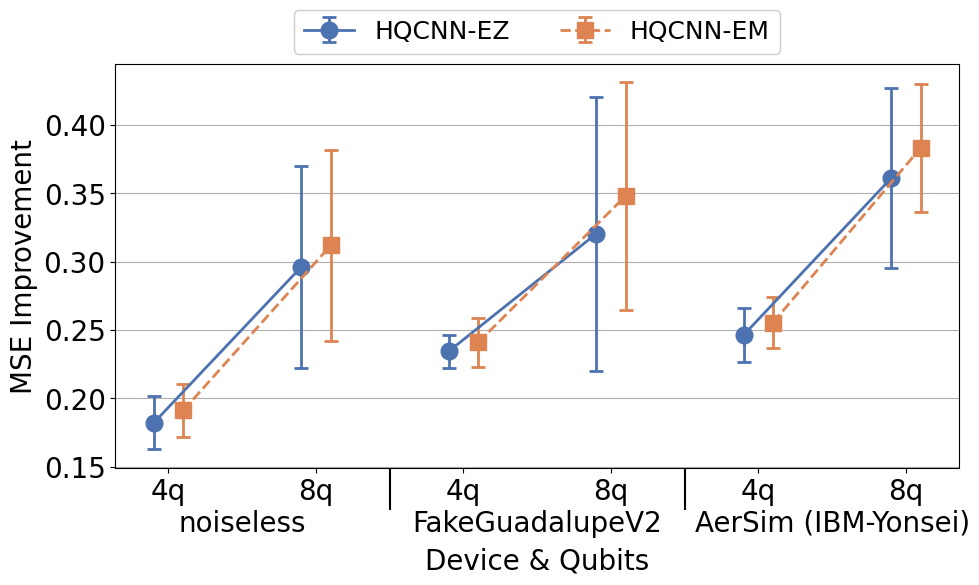

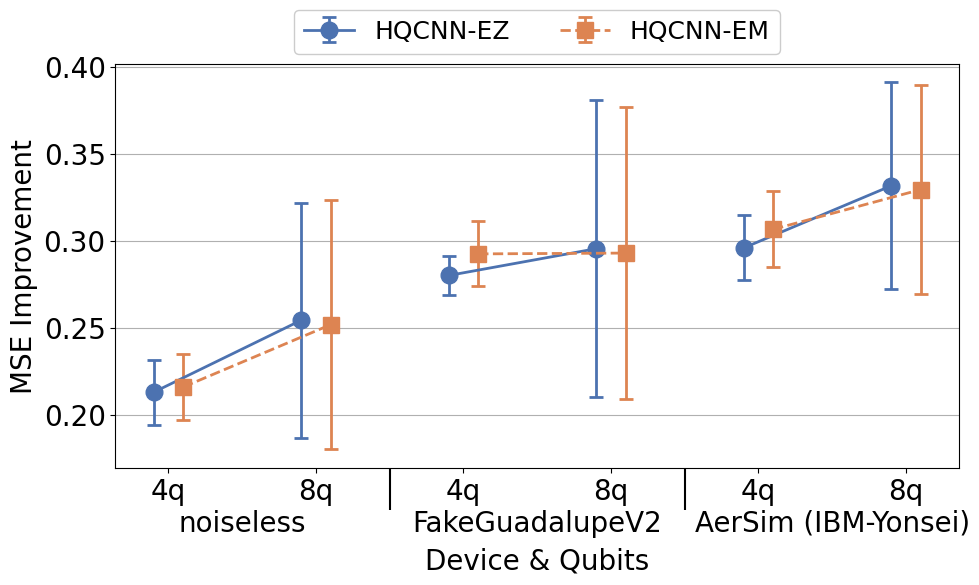

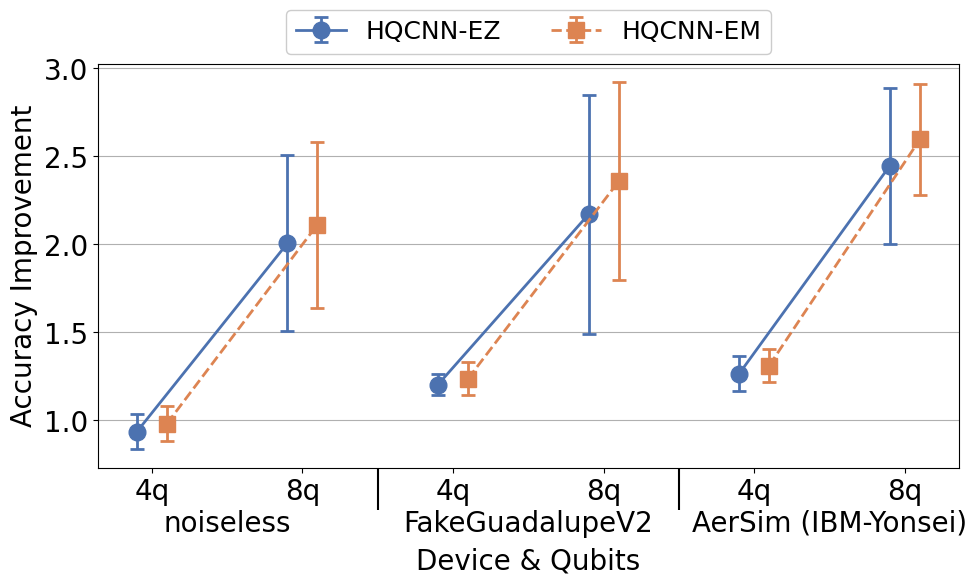

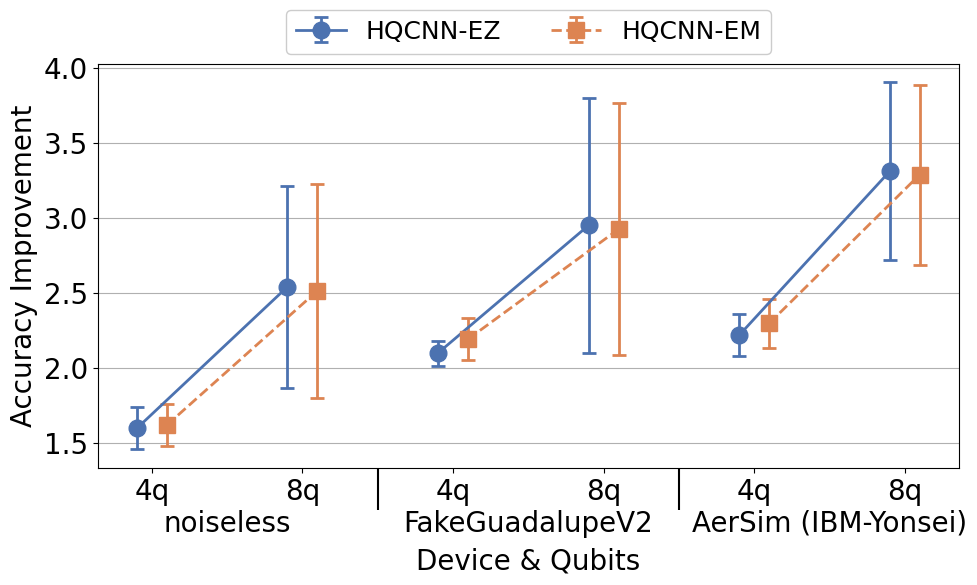

In [44]:
# MSE (loss) improvement
plot_metric_improvement_by_device2(
    df=df_plot,
    metric_diff_cols=['Diff_mse_HQCNN-EZ', 'Diff_mse_HQCNN-EM'],
    metric_label="MSE Improvement",
    plot_title=None,
    filename_suffix="mse_loss_improvement_by_device_and_qubits.png",
    plot_save=PLOT_SAVE,
    qubits=[4, 8, 10],
    figsize=(10, 6),
    title_size=20,
    axis_label_size=20,
    tick_size=20,
    legend_size=18,
    legend_loc='center',
    line_width=2.0,
    point_size=12,
    errorbar_width=2,
    cap_thickness=2,
    capsize=5,
    dodge=0.1
)

# R-squared improvement
plot_metric_improvement_by_device2(
    df=df_plot,
    metric_diff_cols=['Diff_r-squared_HQCNN-EZ', 'Diff_r-squared_HQCNN-EM'],
    metric_label="Accuracy Improvement",
    plot_title=None,
    filename_suffix="accuracy_best_improvement_by_device_and_qubits.png",
    plot_save=PLOT_SAVE,
    qubits=[4, 8, 10],
    figsize=(10, 6),
    title_size=20,
    axis_label_size=20,
    tick_size=20,
    legend_size=18,
    legend_loc='center',
    line_width=2.0,
    point_size=12,
    errorbar_width=2,
    cap_thickness=2,
    capsize=5,
    dodge=0.1
)

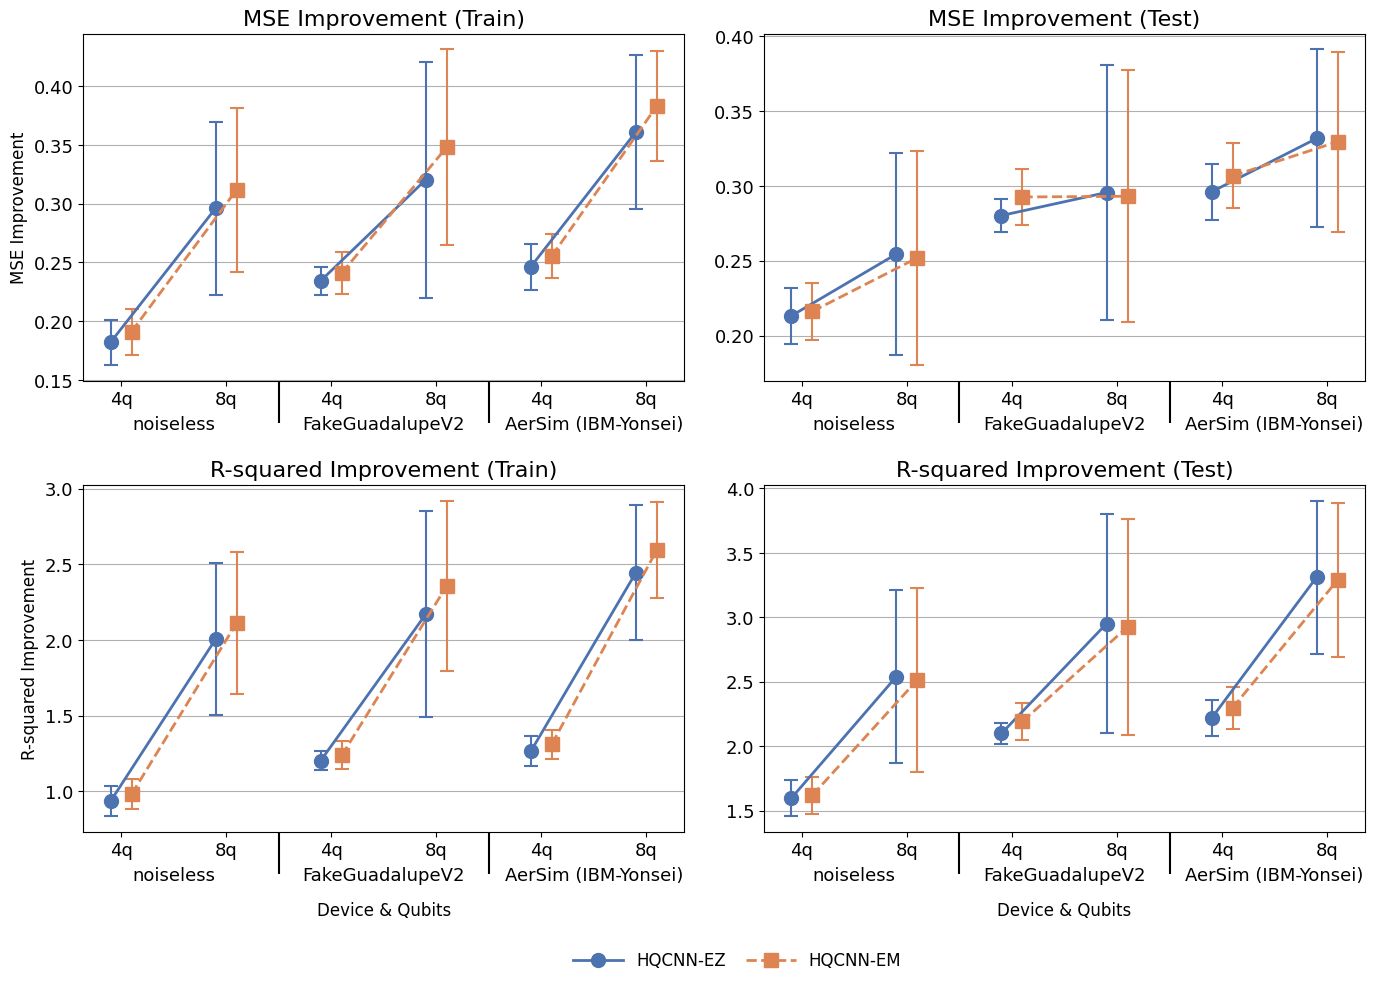

In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D


def plot_metric_improvement_by_device2(
    df,
    metric_diff_cols,
    metric_label="Improvement",
    x_axis_label="Diff.",
    plot_title="Metric Improvement per Device",
    filename_suffix="metric_improvement_by_device.png",
    plot_save=False,
    qubits=None,
    figsize=(8, 6),
    title_size=16,
    axis_label_size=12,
    tick_size=10,
    legend_size=10,
    legend_loc='best',
    show_points=False,
    capsize=3,
    line_alpha=1.0,
    dodge=0.12,
    line_width=1.8,
    point_size=6,
    errorbar_width=1.2,
    cap_thickness=1.2,

    # NEW (for 2x2 usage)
    ax=None,                 # if provided, draw into this axis
    dataset_type=None,       # "Train" or "Test"; if None, does Train+Test like before
    add_legend=True,         # set False when using shared legend
    return_handles=False,    # return legend handles for shared legend
    show=True                # show figure when ax is None
):
    """
    If dataset_type is None:
        behaves like your current version (loops Train/Test and creates its own figures).
    If dataset_type is "Train" or "Test":
        draws ONLY that dataset into `ax` (or into a new figure if ax is None).
    """
    # Optional filter by qubits
    if qubits is not None:
        df = df[df['Qubits'].isin(qubits)].copy()
    else:
        df = df.copy()

    # Melt
    melted_df = df.melt(
        id_vars=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
        value_vars=metric_diff_cols,
        var_name='Model_Comparison',
        value_name=metric_label
    )

    # Rename + enforce order
    rename_dict = {metric_diff_cols[0]: 'HQCNN-EZ', metric_diff_cols[1]: 'HQCNN-EM'}
    melted_df['Model_Comparison'] = melted_df['Model_Comparison'].replace(rename_dict)
    hue_order = ['HQCNN-EZ', 'HQCNN-EM']

    # Device name normalization
    melted_df['Device'] = melted_df['Device'].replace({
        "AerSim with backend noise": "AerSim (IBM-Yonsei)"
    })

    # Composite category
    melted_df['Device_Qubits'] = melted_df['Device'] + "\n q" + melted_df['Qubits'].astype(str)

    # Colors + styles
    colors = sns.color_palette('deep', n_colors=2)
    color_map = {'HQCNN-EZ': colors[0], 'HQCNN-EM': colors[1]}

    style_map = {
        'HQCNN-EZ': {'marker': 'o', 'linestyle': '-'},
        'HQCNN-EM': {'marker': 's', 'linestyle': '--'}
    }

    dodge_map = {'HQCNN-EZ': -abs(dodge), 'HQCNN-EM': abs(dodge)}

    # Legend handles (for shared legend)
    legend_handles = [
        Line2D([0], [0],
               color=color_map[m],
               marker=style_map[m]['marker'],
               linestyle=style_map[m]['linestyle'],
               linewidth=line_width,
               markersize=point_size,
               label=m)
        for m in hue_order
    ]

    def _plot_one_dataset(ax_local, dataset_local):
        subset_df = melted_df[melted_df['Dataset'] == dataset_local].copy()
        if subset_df.empty:
            ax_local.set_visible(False)
            return

        # Stable x-order
        order_df = (
            subset_df[['Device', 'Qubits', 'Device_Qubits']]
            .drop_duplicates()
            .reset_index(drop=True)
        )
        x_order = order_df['Device_Qubits'].tolist()
        x_ticklabels = [str(q) + "q" for q in order_df['Qubits'].tolist()]

        # Summary stats (mean ± sd)
        summary = (
            subset_df
            .groupby(['Device', 'Device_Qubits', 'Model_Comparison'])[metric_label]
            .agg(mean='mean', sd='std')
            .reset_index()
        )

        x_pos_map = {cat: i for i, cat in enumerate(x_order)}
        x_positions = np.arange(len(x_order), dtype=float)

        # device blocks (to break lines across devices)
        device_seq = order_df['Device'].tolist()
        device_blocks = []
        start = 0
        for i in range(1, len(device_seq) + 1):
            if i == len(device_seq) or device_seq[i] != device_seq[start]:
                device_blocks.append(device_seq[start])
                start = i

        # Plot per model, broken by device block, dodged
        for model in hue_order:
            mk = style_map[model]['marker']
            ls = style_map[model]['linestyle']
            dx = dodge_map.get(model, 0.0)

            for dev in device_blocks:
                s = summary[(summary['Model_Comparison'] == model) & (summary['Device'] == dev)].copy()
                if s.empty:
                    continue

                s['x'] = s['Device_Qubits'].map(x_pos_map)
                s = s.dropna(subset=['x']).sort_values('x')

                x = s['x'].to_numpy(dtype=float) + dx
                y_mean = s['mean'].to_numpy()
                y_sd = s['sd'].to_numpy()

                ax_local.errorbar(
                    x, y_mean, yerr=y_sd,
                    fmt=mk,
                    linestyle=ls,
                    capsize=capsize,
                    linewidth=line_width,
                    markersize=point_size,
                    color=color_map[model],
                    alpha=line_alpha,
                    elinewidth=errorbar_width,
                    capthick=cap_thickness,
                    zorder=3
                )

        # Optional raw points (dodged)
        if show_points:
            for model in hue_order:
                d = subset_df[subset_df['Model_Comparison'] == model].copy()
                if d.empty:
                    continue
                d['x'] = d['Device_Qubits'].map(x_pos_map)
                d = d.dropna(subset=['x'])

                ax_local.scatter(
                    d['x'].to_numpy(dtype=float) + dodge_map.get(model, 0.0),
                    d[metric_label].to_numpy(),
                    s=(point_size**2),
                    alpha=0.20,
                    color=color_map[model],
                    marker=style_map[model]['marker'],
                    edgecolors='none',
                    zorder=2
                )

        # Primary x-axis: q# only
        ax_local.set_xticks(x_positions)
        ax_local.set_xticklabels(x_ticklabels, rotation=0, fontsize=tick_size)

        ax_local.set_ylabel(metric_label, fontsize=axis_label_size)
        ax_local.set_xlabel('Device & Qubits', fontsize=axis_label_size, labelpad=30)

        if plot_title:
            ax_local.set_title(f"{plot_title} in {dataset_local} Dataset", fontsize=title_size)

        ax_local.tick_params(axis='x', labelsize=tick_size)
        ax_local.tick_params(axis='y', labelsize=tick_size)
        ax_local.grid(axis='y', zorder=0)

        # legend (optional; typically off for 2x2 shared legend)
        if add_legend:
            ax_local.legend(
                handles=legend_handles,
                fontsize=legend_size,
                loc=legend_loc,
                bbox_to_anchor=(0.5, 1.08),
                ncol=2,
                framealpha=1
            )

        # ---- Secondary x-axis: device labels & separators ----
        xticklocs = np.asarray(ax_local.get_xticks(), dtype=float)
        if len(xticklocs) != len(device_seq):
            xticklocs = np.arange(len(device_seq), dtype=float)

        step = float(np.median(np.diff(xticklocs))) if len(xticklocs) > 1 else 1.0

        group_mids, group_labels, edges = [], [], [xticklocs[0] - 0.5 * step]
        start = 0
        for i in range(1, len(device_seq) + 1):
            if i == len(device_seq) or device_seq[i] != device_seq[start]:
                left = xticklocs[start]
                right = xticklocs[i - 1]
                group_mids.append((left + right) / 2.0)
                group_labels.append(device_seq[start])
                edges.append(right + 0.5 * step)
                start = i

        sec = ax_local.secondary_xaxis(location=0)
        sec.set_xticks(group_mids, labels=group_labels, rotation=0)
        sec.tick_params(axis='x', length=0, pad=25, labelsize=tick_size)

        sec2 = ax_local.secondary_xaxis(location=0)
        sec2.set_xticks(edges, labels=[])
        sec2.tick_params(axis='x', length=30, width=1.5)

        for spine in ['left', 'right', 'top', 'bottom']:
            sec.spines[spine].set_visible(False)
            sec2.spines[spine].set_visible(False)

    # ---- Mode A: draw into existing ax for a single dataset ----
    if dataset_type is not None:
        if ax is None:
            plt.figure(figsize=figsize)
            ax = plt.gca()
            _plot_one_dataset(ax, dataset_type)
            plt.tight_layout()
            if show:
                plt.show()
        else:
            _plot_one_dataset(ax, dataset_type)

        if return_handles:
            return legend_handles
        return

    # ---- Mode B: original behavior (Train + Test separate figures) ----
    for dataset_local in ['Train', 'Test']:
        plt.figure(figsize=figsize)
        ax_local = plt.gca()
        _plot_one_dataset(ax_local, dataset_local)
        plt.tight_layout()

        if plot_save:
            os.makedirs(save_summary_results_dirs, exist_ok=True)
            filename = os.path.join(
                save_summary_results_dirs,
                filename_suffix.replace(
                    ".png",
                    f"_q{'-'.join(map(str, qubits))}_{dataset_local}.png"
                ) if qubits else filename_suffix.replace(".png", f"_{dataset_local}.png")
            )
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"Plot saved as {filename}")

        if show:
            plt.show()

    if return_handles:
        return legend_handles


def plot_improvements_2x2_using_metric2(
    df,
    qubits=None,
    figsize=(14, 10),
    title_font=22,
    subplot_title=18,
    axis_label_size=16,
    tick_font=13,
    legend_font=14,
    plot_save=False,
    save_path=None,

    # forward style knobs to plot_metric_improvement_by_device2
    line_width=2.0,
    point_size=10,
    errorbar_width=1.8,
    cap_thickness=1.8,
    capsize=5,
    dodge=0.10,
    show_points=False,
    line_alpha=1.0
):
    """
    2×2 layout using plot_metric_improvement_by_device2 drawing into axes:
      [0,0] BCE Improvement — Train
      [0,1] BCE Improvement — Test
      [1,0] Accuracy Improvement — Train
      [1,1] Accuracy Improvement — Test
    Shared legend at bottom-center.
    """
    METRICS = {
        "MSE Improvement":      ["Diff_mse_HQCNN-EZ",  "Diff_mse_HQCNN-EM"],
        "R-squared Improvement": ["Diff_r-squared_HQCNN-EZ",  "Diff_r-squared_HQCNN-EM"],
    }

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.reshape(2, 2)

    panels = [
        (0, 0, "MSE Improvement",      "Train"),
        (0, 1, "MSE Improvement",      "Test"),
        (1, 0, "R-squared Improvement", "Train"),
        (1, 1, "R-squared Improvement", "Test"),
    ]

    shared_handles = None

    for r, c, metric_label, dataset in panels:
        ax = axes[r, c]

        handles = plot_metric_improvement_by_device2(
            df=df,
            metric_diff_cols=METRICS[metric_label],
            metric_label=metric_label,
            plot_title=None,            # we'll title per subplot ourselves
            plot_save=False,
            qubits=qubits,
            tick_size = tick_font,

            # style knobs
            line_width=line_width,
            point_size=point_size,
            errorbar_width=errorbar_width,
            cap_thickness=cap_thickness,
            capsize=capsize,
            dodge=dodge,
            show_points=show_points,
            line_alpha=line_alpha,

            # 2x2 mode
            ax=ax,
            dataset_type=dataset,
            add_legend=False,
            return_handles=True,
            show=False
        )

        ax.set_title(f"{metric_label} ({dataset})", fontsize=subplot_title)

        # reduce clutter: hide y-labels on right column, x-labels on top row
        if c == 1:
            ax.set_ylabel("")
        if r == 0:
            ax.set_xlabel("")

        ax.tick_params(axis='x', labelsize=tick_font)
        ax.tick_params(axis='y', labelsize=tick_font)

        if shared_handles is None and handles:
            shared_handles = handles

    # Shared legend at bottom-center
    if shared_handles:
        fig.legend(
            handles=shared_handles,
            loc='lower center',
            bbox_to_anchor=(0.53, -0.01),
            ncol=len(shared_handles),
            frameon=False,
            fontsize=legend_font,
            
            # NEW: make legend samples bigger so dashed lines are visible
            handlelength=3.0,   # longer line segment -> clearer dashes
            markerscale=1.0,    # bigger marker in legend
            handletextpad=0.8,  # spacing between handle and text
            columnspacing=1.2   # spacing between legend columns
        )

    plt.tight_layout(rect=[0, 0.04, 1, 0.98])
    fig.subplots_adjust(hspace=0.30)

    if plot_save:
        if save_path is None:
            # default consistent with your earlier style
            os.makedirs(save_summary_results_dirs, exist_ok=True)
            save_path = os.path.join(save_summary_results_dirs, "Performance_Improvements_2x2_metric2.pdf")
        fig.savefig(save_path, dpi=300, bbox_inches='tight', format='pdf')
        print(f"Plot saved as {save_path}")

    plt.show()

plot_improvements_2x2_using_metric2(
    df=performance_best_comparison_df,
    qubits=num_qubits,
    figsize=(14, 10),
    title_font=title_font,
    subplot_title=subplot_title,
    axis_label_size=axis_label_font,
    tick_font=13,
    legend_font=legend_font,
    plot_save=PLOT_SAVE,

    # line/errorbar styling (same knobs you’ve been using)
    line_width=2.0,
    point_size=10,
    errorbar_width=1.5,
    cap_thickness=1.5,
    capsize=5,
    dodge=0.10,
    show_points=False
)

🔹 Absolute difference (e.g., ΔLoss, ΔAccuracy)

- Pros:
    - Directly tied to the metric scale, so it’s easy to interpret in the same units as the training objective (loss points, accuracy points).
    
    - Shows whether the improvement is “substantively large” on the raw scale.

    - Avoids distortions if the baseline values are very small.

- Cons:

    - Can look underwhelming if the baseline value is large (e.g., 1–2% accuracy gain may seem small without context).

    - Harder to compare across different datasets or devices if baseline levels differ a lot.

🔹 Percent difference (relative improvement)

- Pros:

    - Normalizes the change relative to baseline — good for cross-device or cross-dataset comparisons.

    - Makes small absolute gains more visible if they are proportionally large (e.g., reducing loss from 0.2 to 0.1 = 50% improvement).

    - Easier to communicate to non-technical audiences (“model B improves accuracy by 15%”).

- Cons:

    - Can exaggerate improvements when baselines are small (e.g., improving accuracy from 2% to 3% looks like +50%, but still unusable).

    - Harder to compare across metrics with different scales (loss vs accuracy).

## SHAP Results

In [46]:
import os
import pickle

all_shap_values_dict = dict()

for num_qubit in num_qubits:
    for model_name in model_names_str[1:3]:
        for model_spec in model_specs:
            for ns, device_name in zip(noise_settings, device_names):
                for iter_num in sim_iter_num:
                    save_param_plots_dir = (
                        f"save_results_{problem_type}/{dataset_name}_{num_qubit}/{model_name}/{model_spec}"
                        + f"/ns{ns}_iter{iter_num}_{num_shots}/"
                    )
                    shap_path = os.path.join(save_param_plots_dir, 'deep_explainer_shap.pkl')

                    # ✅ Initialize nested dict with num_qubit as first key
                    all_shap_values_dict \
                        .setdefault(num_qubit, {}) \
                        .setdefault(model_name, {}) \
                        .setdefault(model_spec, {}) \
                        .setdefault(ns, {})[iter_num] = None

                    if os.path.exists(shap_path):
                        try:
                            with open(shap_path, "rb") as f:
                                shap_values = pickle.load(f)
                                all_shap_values_dict[num_qubit][model_name][model_spec][ns][iter_num] = shap_values
                        except Exception as e:
                            print(f"⚠️ Error loading SHAP file at {shap_path}: {e}")
                    else:
                        print(f"⚠️ Warning: {shap_path} does not exist!")

In [47]:
# all_shap_values_dict[4]['model_mmTmbF']['AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01']['2'][4].values

In [48]:
# for model_name, model_spec_dict in all_shap_values_dict.items():
#     print(model_name)
#     print(model_spec_dict)

In [49]:
import pandas as pd
import numpy as np

def shap_values_to_dataframe(
    all_shap_values_dict,
    num_qubit, 
    input_label_dict,          # e.g., {'model_mmTmbF': ['⟨Z⟩_0', ...], ...}
    noise_to_device,           # e.g., {'0': 'noiseless', ...}
    selected_model_names=None,
    selected_noise_settings=None
):
    df_rows = []

    for model_name, model_spec_dict in all_shap_values_dict.items():
        if selected_model_names is not None and model_name not in selected_model_names:
            continue

        for model_spec, noise_setting_dict in model_spec_dict.items():
            for noise_setting_key, sim_dict in noise_setting_dict.items():
                if selected_noise_settings is not None and noise_setting_key not in selected_noise_settings:
                    continue

                device_name = noise_to_device.get(str(noise_setting_key), "Unknown")

                for sim_iter_num, shap_values in sim_dict.items():
                    if shap_values is None:
                        continue

                    # Calculate mean absolute SHAP values
                    abs_mean = shap_values.abs.mean(0).values  # shape (n_features,)
                    input_labels = input_label_dict.get(model_name, [f"x{i}" for i in range(len(abs_mean))])
                    
                    for i, val in enumerate(abs_mean):
                        record = {
                            'Device': device_name,
                            'Qubits': num_qubit,
                            'Model': model_name,
                            'Model_spec': model_spec,
                            'sim_iter_num': sim_iter_num,
                            'Input_Feature': input_labels[i],
                            'Abs_SHAP': val
                        }
                        df_rows.append(record)

    df = pd.DataFrame(df_rows)
    return df

In [50]:
# # [num_qubit][model_name][model_spec][ns][iter_num]
# all_shap_values_dict[4]['model_mmTmbF']['AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01']['0'].values()

In [51]:
# ### Concatenate SHAP values across iterations and Plot beeswarm plots

# import os
# import pickle
# import numpy as np
# import shap

# all_shap_values_combined_dict = dict()

# for num_qubit in num_qubits:
#     for model_name in model_names_str[1:3]:
#         for model_spec in model_specs:
#             for ns, device_name in zip(noise_settings, device_names):
                
#                 # 1. Collect all loaded objects for this setting into a list
#                 expl_list = []
                
#                 for iter_num in sim_iter_num:
#                     save_param_plots_dir = (
#                         f"save_results_{problem_type}/{dataset_name}_{num_qubit}/{model_name}/{model_spec}"
#                         + f"/ns{ns}_iter{iter_num}_{num_shots}/"
#                     )
#                     shap_path = os.path.join(save_param_plots_dir, 'deep_explainer_shap.pkl')

#                     if os.path.exists(shap_path):
#                         try:
#                             with open(shap_path, "rb") as f:
#                                 # Append the loaded object to our temporary list
#                                 expl_list.append(pickle.load(f))
#                         except Exception as e:
#                             print(f"⚠️ Error loading SHAP file at {shap_path}: {e}")
#                     else:
#                         print(f"⚠️ Warning: {shap_path} does not exist!")

#                 # 2. Combine them using your robust logic
#                 if expl_list:
#                     vals_all = []
#                     data_all = []
#                     base_all = []
                    
#                     # Grab feature names from the first object (if they exist)
#                     feat_names = getattr(expl_list[0], "feature_names", None)

#                     for e in expl_list:
#                         vals = np.asarray(e.values)
#                         dat  = np.asarray(e.data)
#                         bas  = np.asarray(e.base_values)

#                         # Handle base_values dimension mismatch (scalar vs array)
#                         if bas.ndim == 0:
#                             bas = np.full((vals.shape[0],), float(bas))
#                         else:
#                             bas = bas.reshape(-1)

#                         vals_all.append(vals)
#                         data_all.append(dat)
#                         base_all.append(bas)

#                     # Create the new combined Explanation object
#                     combined_expl = shap.Explanation(
#                         values=np.concatenate(vals_all, axis=0),
#                         base_values=np.concatenate(base_all, axis=0),
#                         data=np.concatenate(data_all, axis=0),
#                         feature_names=feat_names
#                     )

#                     # 3. Store the single combined object in the dict
#                     all_shap_values_combined_dict \
#                         .setdefault(num_qubit, {}) \
#                         .setdefault(model_name, {}) \
#                         .setdefault(model_spec, {})[ns] = combined_expl

In [52]:
# # [num_qubit][model_name][model_spec][ns]
# all_shap_values_combined_dict[4]['model_mmTmbF']['AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01']['0'].data

In [53]:
# import shap
# import matplotlib.pyplot as plt

# for num_qubit in num_qubits:
#     # Map model name to its input labels (already defined earlier)
#     input_labels_list = []
#     input_labels_list_new_order = []
#     input_size_list = [1, int(np.log2(num_qubit)), 3*int(np.log2(num_qubit))]
        
#     for model_name, input_size in zip(model_names_str, input_size_list):
#         if model_name == 'model_mmF':
#             input_labels_list.append(None)
#             input_labels_list_new_order.append(None)
#         if model_name == 'model_mmTmbF':
#             input_labels_list.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
#             input_labels_list_new_order.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
#         elif model_name == 'model_mmTmbT':
#             input_labels_list.append([f"{m}{i}" for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_'] for i in range(int(np.ceil(np.log2(num_qubit))))])
#             input_labels_list_new_order.append([f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']])
#         input_label_dict = dict(zip(model_names_str, input_labels_list))
#         input_label_new_order_dict = dict(zip(model_names_str, input_labels_list_new_order))
        
#     for model_name in model_names_str[1:]:
#         for model_spec in model_specs:
#             for ns, device_name in zip(noise_settings, device_names):
#                 shap_values = all_shap_values_combined_dict[num_qubit][model_name][model_spec][ns]
#                 col2num = {col: i for i, col in enumerate(input_label_dict[model_name])}
#                 new_order = list(map(col2num.get, input_label_new_order_dict[model_name]))
                
#                 fig, ax = plt.subplots(figsize=(8, 4))
#                 shap.plots.beeswarm(shap_values, 
#                                     # order=range(len(input_label_dict[model_name])),
#                                     order=new_order, 
#                                     show=False)
#                 plt.title(f"SHAP Beeswarm Plot: \n num_qubit={num_qubit}, model_name={model_name}, ns={ns}", fontsize=14)
#                 plt.tight_layout()
#                 # if PLOT_SAVE:
#                 #     plt.savefig(save_dir_model + f"shap_beeswarm_plot.png", dpi=200)
#                 # plt.show()

### Beeswarm plot for each case

In [54]:
# import shap
# import matplotlib.pyplot as plt

# for num_qubit in num_qubits:
#     # Map model name to its input labels (already defined earlier)
#     input_labels_list = []
#     input_labels_list_new_order = []
#     input_size_list = [1, int(np.log2(num_qubit)), 3*int(np.log2(num_qubit))]
        
#     for model_name, input_size in zip(model_names_str, input_size_list):
#         if model_name == 'model_mmF':
#             input_labels_list.append(None)
#             input_labels_list_new_order.append(None)
#         if model_name == 'model_mmTmbF':
#             input_labels_list.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
#             input_labels_list_new_order.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
#         elif model_name == 'model_mmTmbT':
#             input_labels_list.append([f"{m}{i}" for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_'] for i in range(int(np.ceil(np.log2(num_qubit))))])
#             input_labels_list_new_order.append([f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']])
#         input_label_dict = dict(zip(model_names_str, input_labels_list))
#         input_label_new_order_dict = dict(zip(model_names_str, input_labels_list_new_order))
        
#     for model_name in model_names_str[1:]:
#         for model_spec in model_specs:
#             for ns, device_name in zip(noise_settings, device_names):
#                 for iter_num in sim_iter_num:
#                     shap_values = all_shap_values_dict[num_qubit][model_name][model_spec][ns][iter_num]
#                     col2num = {col: i for i, col in enumerate(input_label_dict[model_name])}
#                     new_order = list(map(col2num.get, input_label_new_order_dict[model_name]))
                    
#                     fig, ax = plt.subplots(figsize=(8, 4))
#                     shap.plots.beeswarm(shap_values, 
#                                         # order=range(len(input_label_dict[model_name])),
#                                         order=new_order, 
#                                         show=False)
#                     plt.title(f"SHAP Beeswarm Plot: \n num_qubit={num_qubit}, model_name={model_name}, ns/iter={ns}/{iter_num}", fontsize=14)
#                     plt.tight_layout()
#                     # if PLOT_SAVE:
#                     #     plt.savefig(save_dir_model + f"shap_beeswarm_plot.png", dpi=200)
#                     plt.show()

### Absolute SHAP plot for each case

In [55]:
# import shap
# import matplotlib.pyplot as plt

# for num_qubit in num_qubits:
#     # Map model name to its input labels (already defined earlier)
#     input_labels_list = []
#     input_labels_list_new_order = []
#     input_size_list = [1, int(np.log2(num_qubit)), 3*int(np.log2(num_qubit))]
        
#     for model_name, input_size in zip(model_names_str, input_size_list):
#         if model_name == 'model_mmF':
#             input_labels_list.append(None)
#             input_labels_list_new_order.append(None)
#         if model_name == 'model_mmTmbF':
#             input_labels_list.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
#             input_labels_list_new_order.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
#         elif model_name == 'model_mmTmbT':
#             input_labels_list.append([f"{m}{i}" for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_'] for i in range(int(np.ceil(np.log2(num_qubit))))])
#             input_labels_list_new_order.append([f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']])
#         input_label_dict = dict(zip(model_names_str, input_labels_list))
#         input_label_new_order_dict = dict(zip(model_names_str, input_labels_list_new_order))
        
#     for model_name in model_names_str[1:]:
#         for model_spec in model_specs:
#             for ns, device_name in zip(noise_settings, device_names):
#                 for iter_num in sim_iter_num:
#                     shap_values = all_shap_values_dict[num_qubit][model_name][model_spec][ns][iter_num]
#                     col2num = {col: i for i, col in enumerate(input_label_dict[model_name])}
#                     new_order = list(map(col2num.get, input_label_new_order_dict[model_name]))
                    
#                     fig, ax = plt.subplots(figsize=(8, 4))
#                     shap.plots.bar(shap_values.abs.mean(0),
#                                    # order=range(len(input_label_dict[model_name])),
#                                    order=new_order,
#                                    show=False)
#                     fig = plt.gcf()
#                     fig.set_size_inches(8, 4)
#                     ax = plt.gca()
#                     plt.title(f"SHAP Beeswarm Plot: \n num_qubit={num_qubit}, model_name={model_name}, ns/iter={ns}/{iter_num}", fontsize=14)
#                     plt.tight_layout()
#                     # if PLOT_SAVE:
#                     #     plt.savefig(save_dir_model + f"shap_absolute_mean_plot.png", dpi=200)
#                     plt.show()

In [56]:
absolute_shap_values_df = pd.DataFrame()

for num_qubit in num_qubits:
    # Map model name to its input labels (already defined earlier)
    input_labels_list = []
    input_size_list = [1, int(np.log2(num_qubit)), 3*int(np.log2(num_qubit))]
    for model_name, input_size in zip(model_names_str, input_size_list):
        if model_name == 'model_mmF':
            input_labels_list.append(None)
        if model_name == 'model_mmTmbF':
            input_labels_list.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
        elif model_name == 'model_mmTmbT':
            input_labels_list.append([f"{m}{i}" for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_'] for i in range(int(np.ceil(np.log2(num_qubit))))])
    input_label_dict = dict(zip(model_names_str, input_labels_list))
    
    # Get the absolute SHAP values
    df_absolute_shap = shap_values_to_dataframe(
        all_shap_values_dict[num_qubit],
        num_qubit=num_qubit,
        input_label_dict=input_label_dict,
        noise_to_device=noise_to_device,
        selected_model_names=model_names_str,
        selected_noise_settings=noise_settings
    )
    absolute_shap_values_df = pd.concat([absolute_shap_values_df, df_absolute_shap], ignore_index=True)
    
for df in [absolute_shap_values_df]:
    if not df.empty and 'Model' in df.columns:
        df['Model'] = df['Model'].replace(model_rename_map)

In [57]:
absolute_shap_values_df

,Device,Qubits,Model,Model_spec,sim_iter_num,Input_Feature,Abs_SHAP
0,noiseless,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,⟨Z⟩_0,0.195812
1,noiseless,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,⟨Z⟩_1,0.167193
2,noiseless,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,⟨Z⟩_0,0.151827
3,noiseless,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,⟨Z⟩_1,0.279834
4,noiseless,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,2,⟨Z⟩_0,0.145479
...,...,...,...,...,...,...,...
295,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,⟨Y⟩_1,0.066386
296,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,⟨Y⟩_2,0.051279
297,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,⟨Z⟩_0,0.043101
298,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,⟨Z⟩_1,0.045537


In [58]:
for num_qubit in num_qubits:
    # Map model name to its input labels (already defined earlier)
    input_labels_list = []
    input_labels_list_new_order = []
    input_size_list = [1, int(np.log2(num_qubit)), 3*int(np.log2(num_qubit))]
        
    for model_name, input_size in zip(model_names_str, input_size_list):
        if model_name == 'model_mmF':
            input_labels_list.append(None)
            input_labels_list_new_order.append(None)
        if model_name == 'model_mmTmbF':
            input_labels_list.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
            input_labels_list_new_order.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
        elif model_name == 'model_mmTmbT':
            input_labels_list.append([f"{m}{i}" for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_'] for i in range(int(np.ceil(np.log2(num_qubit))))])
            input_labels_list_new_order.append([f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']])
        input_label_dict = dict(zip(model_names_str, input_labels_list))
        input_label_new_order_dict = dict(zip(model_names_str, input_labels_list_new_order))

In [59]:
input_label_new_order_dict

{'model_mmF': None,
 'model_mmTmbF': ['⟨Z⟩_0', '⟨Z⟩_1', '⟨Z⟩_2'],
 'model_mmTmbT': ['⟨X⟩_0',
  '⟨Y⟩_0',
  '⟨Z⟩_0',
  '⟨X⟩_1',
  '⟨Y⟩_1',
  '⟨Z⟩_1',
  '⟨X⟩_2',
  '⟨Y⟩_2',
  '⟨Z⟩_2']}

### Mean of Absolute SHAP value bar plot

In [60]:
absolute_shap_values_df['Input_Feature'].unique()

array(['⟨Z⟩_0', '⟨Z⟩_1', '⟨X⟩_0', '⟨X⟩_1', '⟨Y⟩_0', '⟨Y⟩_1', '⟨Z⟩_2',
       '⟨X⟩_2', '⟨Y⟩_2'], dtype=object)

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, StrMethodFormatter, MaxNLocator

def plot_grouped_horizontal_bars_for_model(shap_df, num_qubit, model,
                                           title_fontsize=14, axis_label_fontsize=12, tick_fontsize=12,
                                           legend_size=8, lenged_pos=(1.0, 0.50), legend_loc='lower right', 
                                           plot_title=True, plot_save=False, figsize=(8, 6), save_dir='./'):
    df_model = shap_df[shap_df['Model'] == model].copy()

    if df_model.empty:
        print(f"No data found for model: {model}")
        return
    
    df_model['Device'] = df_model['Device'].replace({
        "AerSim with backend noise": "AerSim (Yonsei)"
    })
    
    # if model == 'HQCNN-EZ':
    #     factor = 3
    # elif model == 'HQCNN-EM':
    #     factor = 6.0
    # else:
    #     factor = 1.0
    
    # plt.figure(figsize=(8, factor*int(np.log2(len(df_model['Input_Feature'].unique())))))
    # plt.figure(figsize=(8, factor))
    plt.figure(figsize=figsize)
    
    # --- Define Order ---
    if model == 'HQCNN-EZ':
        y_order = [f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))]
    elif model == 'HQCNN-EM':
        y_order = [f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']]
    else:
        y_order = df_model['Input_Feature'].drop_duplicates().tolist()
    
    # --- LaTeX Label Transformation ---
    # This captures the letter (X, Y, or Z) and the number after the underscore
    latex_labels = [
        f"$\\langle {lbl.split('⟩_')[0].strip('⟨')} \\rangle_{{{lbl.split('_')[-1]}}}$" 
        if '⟨' in lbl else lbl 
        for lbl in y_order
    ]
       
    # Preserve first-appearance order for devices (hue)
    hue_order = df_model['Device'].drop_duplicates().tolist()

    # Deterministic color map per device
    palette_colors = sns.color_palette('Spectral', n_colors=len(hue_order))
    color_map = dict(zip(hue_order, palette_colors))
    
    ax = sns.barplot(
        data=df_model,
        y='Input_Feature',
        x='Abs_SHAP',
        hue='Device',
        hue_order=hue_order,
        order=y_order,
        orient='h',
        palette=color_map, 
        width=.8,
        linewidth=.8,
        edgecolor='black',
        errorbar='sd',
        err_kws={'linewidth': 1.5}
        )
    
    hatch_map = {
        'noiseless': None,  
        'FakeGuadalupeV2': '///',
        'AerSim (Yonsei)': '...'
    }
    # ax.containers has one BarContainer per hue in hue_order
    for i, container in enumerate(ax.containers):
        if i >= len(hue_order):
            break
        device_name = hue_order[i]
        hatch = hatch_map.get(device_name, None)
        if hatch:
            for bar in container.patches:
                bar.set_hatch(hatch)

    # Custom legend that shows both color and hatch
    legend_handles = []
    for device_name in hue_order:
        legend_handles.append(
            Patch(
                facecolor=color_map[device_name],
                edgecolor='black',
                hatch=hatch_map.get(device_name, None),
                label=device_name
            )
        )
    ax.legend(
        handles=legend_handles,
        title='Device',
        fontsize=legend_size,
        bbox_to_anchor=lenged_pos,   # For model_name=='HQCNN-EM'x
        title_fontsize=legend_size,
        loc=legend_loc
    )
    
    if plot_title:
        plt.title(f"Mean Absolute SHAP Values — q{num_qubit}, {model}", fontsize=title_fontsize)
    plt.xlabel("Mean |SHAP|", fontsize=axis_label_fontsize)
    plt.ylabel("Input Feature", fontsize=axis_label_fontsize)
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(latex_labels, fontsize=tick_fontsize)
    if num_qubit == 4 and model == 'HQCNN-EZ':
        ax.xaxis.set_major_locator(MultipleLocator(0.05))
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
        ax.xaxis.set_minor_locator(MultipleLocator(0.01))
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    # plt.legend(title="Device", loc="upper right", bbox_to_anchor=(1.0, 0.8), fontsize=10)
    # plt.gca().get_legend().remove()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    if plot_save:
        os.makedirs(save_dir, exist_ok=True)
        filename = os.path.join(save_dir, f'Absolute_SHAP_Mean_Barplot_q{num_qubit}_{model}.png')
        plt.savefig(filename, dpi=200, bbox_inches='tight')
        print(f"✅ Plot saved as {filename}")
    else:
        plt.show()

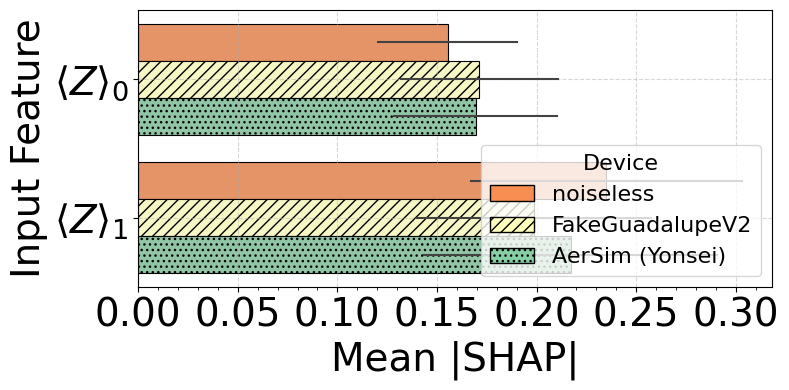

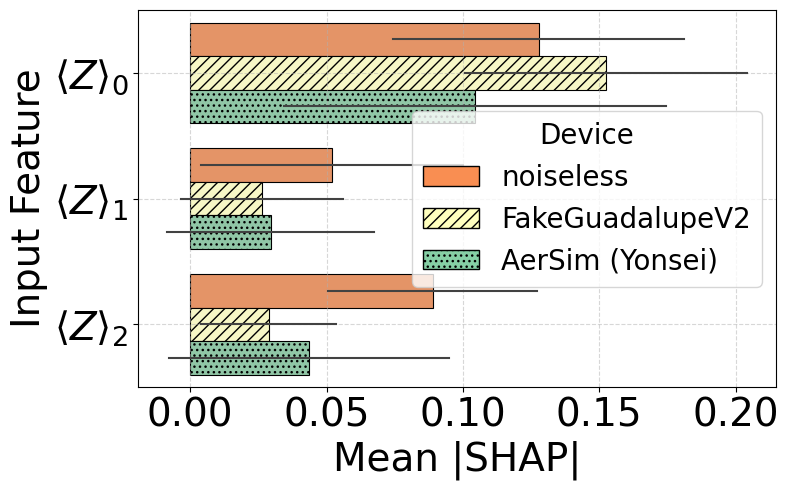

In [62]:
FIGSIZE_BY_PAIR = {
    ('HQCNN-EZ', 4): (8, 4),
    ('HQCNN-EZ', 8): (8, 5),
    ('HQCNN-EZ', 10): (8, 6),
    ('HQCNN-EM', 4): (8, 6),
    ('HQCNN-EM', 8): (8, 7),
    ('HQCNN-EM', 10): (8, 8),
}

FONTSIZE_BY_PAIR = {
    ('HQCNN-EZ', 4): 28,
    ('HQCNN-EZ', 8): 28,
    ('HQCNN-EZ', 10): 28,
    ('HQCNN-EM', 4): 28,
    ('HQCNN-EM', 8): 28,
    ('HQCNN-EM', 10): 28,
}

LEGEND_FONTSIZE_BY_PAIR = {
    ('HQCNN-EZ', 4): 16,
    ('HQCNN-EZ', 8): 20,
    ('HQCNN-EZ', 10): 20,
    ('HQCNN-EM', 4): 24,
    ('HQCNN-EM', 8): 24,
    ('HQCNN-EM', 10): 24,
}

LEGEND_POSITION_BY_PAIR = {
    ('HQCNN-EZ', 4): None,
    ('HQCNN-EZ', 8): None,
    ('HQCNN-EZ', 10): (1.0, 0.45),
    ('HQCNN-EM', 4): (1.0, 0.55),
    ('HQCNN-EM', 8): (1.0, 0.55),
    ('HQCNN-EM', 10): (1.0, 0.55)
}

for num_qubit in num_qubits[:-1]:
    for model_name in model_names_str_new:
        if model_name == 'QCNN':
            continue
        # elif model_name == 'HQCNN-EZ':
        #     continue
        elif model_name == 'HQCNN-EM':
            continue
        figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))  # fallback size
        plot_grouped_horizontal_bars_for_model(absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
                                               num_qubit=num_qubit,
                                               model=model_name,
                                               figsize=figsize_value,
                                               title_fontsize=fontsize_value,
                                               axis_label_fontsize=fontsize_value,
                                               legend_size=legend_fontsize_value,
                                               tick_fontsize=fontsize_value,
                                               legend_loc='lower right',       # 'lower right', 'center right'
                                               lenged_pos=legend_position_value,
                                               plot_title=None,
                                               plot_save=PLOT_SAVE,
                                               save_dir=save_summary_results_dirs)
        
for num_qubit in num_qubits[-1:]:
    for model_name in model_names_str_new:
        if model_name == 'QCNN':
            continue
        # elif model_name == 'HQCNN-EZ':
        #     continue
        elif model_name == 'HQCNN-EM':
            continue
        figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))  # fallback size
        plot_grouped_horizontal_bars_for_model(absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
                                               num_qubit=num_qubit,
                                               model=model_name,
                                               figsize=figsize_value,
                                               title_fontsize=fontsize_value,
                                               axis_label_fontsize=fontsize_value,
                                               legend_size=legend_fontsize_value,
                                               tick_fontsize=fontsize_value,
                                               legend_loc='center right',       # 'lower right', 'center right'
                                               lenged_pos=legend_position_value,
                                               plot_title=None,
                                               plot_save=PLOT_SAVE,
                                               save_dir=save_summary_results_dirs)

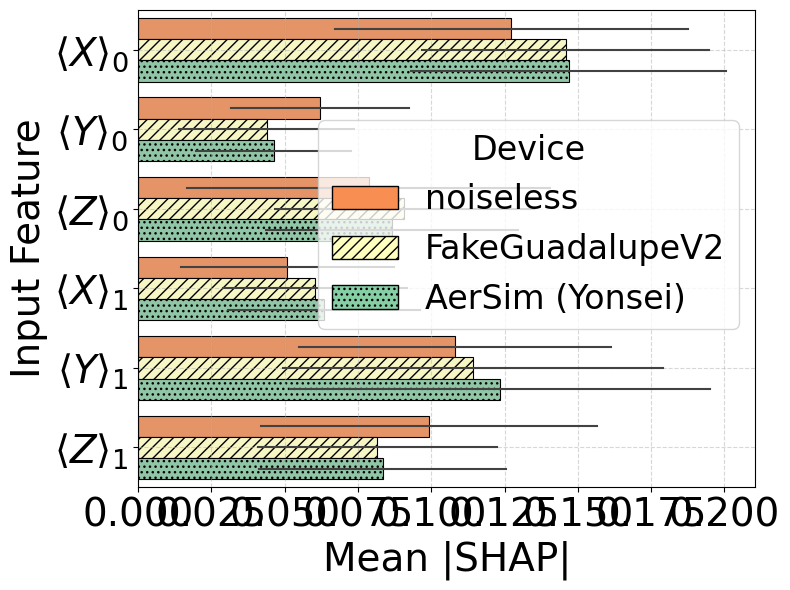

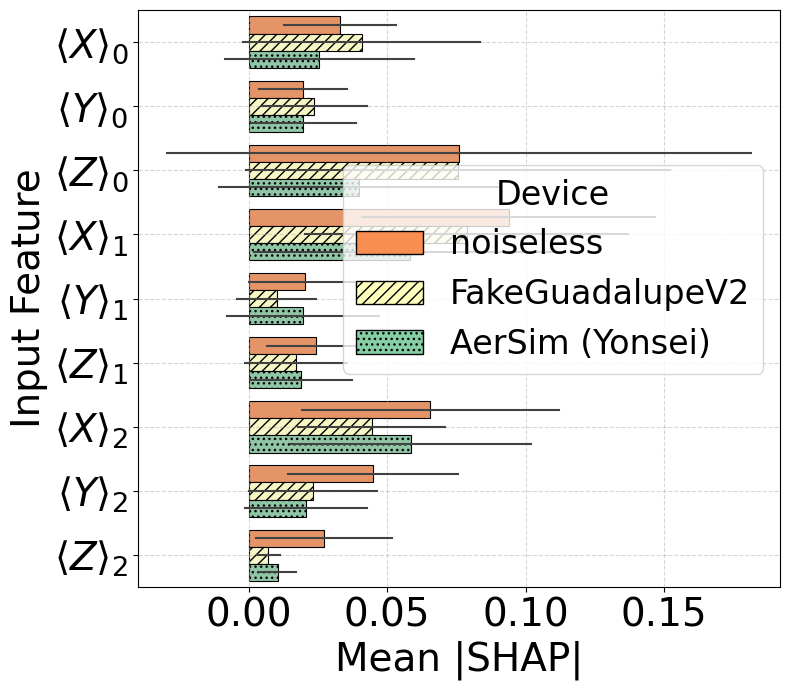

In [63]:
for num_qubit in num_qubits:
    for model_name in model_names_str_new:
        if model_name == 'QCNN':
            continue
        elif model_name == 'HQCNN-EZ':
            continue
        # elif model_name == 'HQCNN-EM':
        #     continue
        figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))  # fallback size
        plot_grouped_horizontal_bars_for_model(absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
                                               num_qubit=num_qubit,
                                               model=model_name,
                                               figsize=figsize_value,
                                               title_fontsize=fontsize_value,
                                               axis_label_fontsize=fontsize_value,
                                               legend_size=legend_fontsize_value,
                                               tick_fontsize=fontsize_value,
                                               legend_loc='center right',       # 'lower right', 'center right'
                                               lenged_pos=legend_position_value,
                                               plot_title=None,
                                               plot_save=PLOT_SAVE,
                                               save_dir=save_summary_results_dirs)

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, StrMethodFormatter

def plot_grouped_horizontal_bars_for_model(
    shap_df,
    num_qubit,
    model,
    ax,
    title_fontsize=14,
    axis_label_fontsize=12,
    tick_fontsize=12,
    legend_size=8,
    legend_loc='lower right',
    legend_pos=(1.0, 0.5),
    plot_title=True
):
    """
    Draws into a given Axes `ax` instead of creating a new figure.
    Returns legend_handles (for a shared legend if desired).
    """
    df_model = shap_df[(shap_df['Model'] == model) &
                       (shap_df['Qubits'] == num_qubit)].copy()

    if df_model.empty:
        print(f"No data found for model={model}, q={num_qubit}")
        ax.set_visible(False)
        return []

    df_model['Device'] = df_model['Device'].replace({
        "AerSim with backend noise": "AerSim (Yonsei)"
    })

    # --- 1. Define Order ---
    if model == 'HQCNN-EZ':
        y_order = [f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))]
    elif model == 'HQCNN-EM':
        y_order = [f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']]
    else:
        y_order = df_model['Input_Feature'].drop_duplicates().tolist()
    
    # --- LaTeX Label Transformation ---
    latex_labels = [
        f"$\\langle {lbl.split('⟩_')[0].strip('⟨')} \\rangle_{{{lbl.split('_')[-1]}}}$" 
        if '⟨' in lbl else lbl 
        for lbl in y_order
    ]

    # Preserve first-appearance order for devices (hue)
    hue_order = df_model['Device'].drop_duplicates().tolist()

    # Deterministic color map per device
    palette_colors = sns.color_palette('Spectral', n_colors=len(hue_order))
    color_map = dict(zip(hue_order, palette_colors))

    # --- Horizontal barplot ---
    sns.barplot(
        data=df_model,
        y='Input_Feature',
        x='Abs_SHAP',
        hue='Device',
        hue_order=hue_order,
        order=y_order,
        orient='h',
        palette=color_map,
        width=.8,
        linewidth=.8,
        edgecolor='black',
        errorbar='sd',
        err_kws={'linewidth': 1.5},
        ax=ax
    )

    # Hatches
    hatch_map = {
        'noiseless': None,
        'FakeGuadalupeV2': '///',
        'AerSim (Yonsei)': '...'
    }
    for i, container in enumerate(ax.containers):
        if i >= len(hue_order):
            break
        device_name = hue_order[i]
        hatch = hatch_map.get(device_name, None)
        if hatch:
            for bar in container.patches:
                bar.set_hatch(hatch)

    # Custom legend handles (color + hatch)
    legend_handles = []
    for device_name in hue_order:
        legend_handles.append(
            Patch(
                facecolor=color_map[device_name],
                edgecolor='black',
                hatch=hatch_map.get(device_name, None),
                label=device_name
            )
        )

    # Axes labels & title
    if plot_title:
        ax.set_title(f"{model}, {num_qubit}-qubits", fontsize=title_fontsize)

    ax.set_xlabel("Mean |SHAP|", fontsize=axis_label_fontsize)
    ax.set_ylabel("Input Feature", fontsize=axis_label_fontsize)
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(latex_labels, fontsize=tick_fontsize)
    
    # Optional special x-axis formatting
    if num_qubit == 4 and model == 'HQCNN-EZ':
        ax.xaxis.set_major_locator(MultipleLocator(0.05))
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
        ax.xaxis.set_minor_locator(MultipleLocator(0.01))

    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)

    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Remove seaborn's automatic legend (we'll build shared)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    return legend_handles

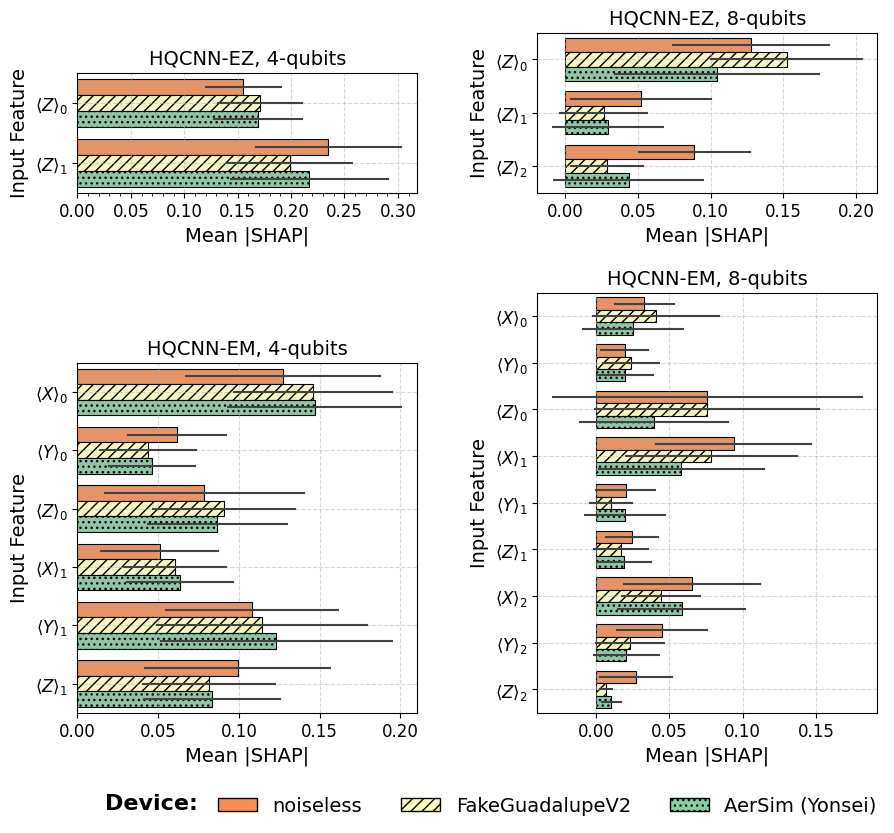

In [65]:
import matplotlib.pyplot as plt
import numpy as np  # only needed if you still want demo data; not needed for SHAP
# absolute_shap_values_df already defined
# model_names_str_new includes ['QCNN', 'HQCNN-EZ', 'HQCNN-EM']

fig = plt.figure(figsize=(10, 10))  # one global canvas

if len(num_qubits) == 2:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.08, 0.52, 0.34, 0.12])   # EZ, q4
    ax2 = fig.add_axes([0.54, 0.52, 0.34, 0.16])   # EZ, q8

    ax3 = fig.add_axes([0.08, 0.00, 0.34, 0.35])   # EM, q4
    ax4 = fig.add_axes([0.54, 0.00, 0.34, 0.42])   # EM, q8
    
    axes = [ax1, ax2, ax3, ax4]
    
elif len(num_qubits) == 3:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.00, 0.62, 0.26, 0.12])  # EZ, q4
    ax2 = fig.add_axes([0.36, 0.62, 0.26, 0.16])  # EZ, q8
    ax3 = fig.add_axes([0.72, 0.62, 0.26, 0.20])  # EZ, q10

    ax4 = fig.add_axes([0.00, 0.0, 0.26, 0.35])   # EM, q4
    ax5 = fig.add_axes([0.36, 0.0, 0.26, 0.42])   # EM, q8
    ax6 = fig.add_axes([0.72, 0.0, 0.26, 0.52])   # EM, q1
    
    axes = [ax1, ax2, ax3, ax4, ax5, ax6]

# num_qubits = [4, 8, 10]
models_for_rows = ['HQCNN-EZ', 'HQCNN-EM']

# Centralized font sizes (you can tweak)
title_font      = 16
subplot_title   = 14
axis_label_font = 14
tick_font       = 12
legend_font     = 14

legend_handles_shared = None

# Fill 2×3: (row= model, col= qubit)
idx = 0
for row, model_name in enumerate(models_for_rows):
    for col, nq in enumerate(num_qubits):
        ax = axes[idx]; idx += 1
        handles = plot_grouped_horizontal_bars_for_model(
            shap_df=absolute_shap_values_df,
            num_qubit=nq,
            model=model_name,
            ax=ax,
            title_fontsize=subplot_title,
            axis_label_fontsize=axis_label_font,
            tick_fontsize=tick_font,
            legend_size=legend_font,
            legend_loc='center right',
            legend_pos=(1.0, 0.5),
            plot_title=True
        )
        # Save legend handles from the first populated subplot
        if legend_handles_shared is None and handles:
            legend_handles_shared = handles

# Shared figure title
# fig.suptitle("Mean Absolute SHAP value of mid-circuit measurements across devices, models, and qubit sizes",
#              fontsize=title_font, y=0.99)

# Shared legend at bottom center
if legend_handles_shared:
    fig.legend(
        handles=legend_handles_shared,
        loc="lower center",
        bbox_to_anchor=(0.55, -0.12),
        ncol=len(legend_handles_shared),
        frameon=False,
        fontsize=legend_font,
        # title="Device",
        title_fontsize=legend_font
    )
    
    # Add external text label on the left or right side of the legend
    fig.text(0.20, -0.091, "Device:", ha='right', va='center', fontsize=legend_font+2, fontweight='bold')

# ---- SAVE PLOT AS PDF ----
if PLOT_SAVE:
    os.makedirs(save_dir, exist_ok=True)
    filename = (save_summary_results_dirs + f'Absolute_SHAP_Mean_2x3_{problem_type}.pdf')
    fig.savefig(filename, dpi=300, bbox_inches='tight', format='pdf')
    print(f"Plot saved as {filename}")

plt.show()

### Mean Boxplot of Absolute SHAP values

In [66]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, StrMethodFormatter


def plot_grouped_boxplots_for_model(shap_df, num_qubit, model,
                                    title_fontsize=14, axis_label_fontsize=12, tick_fontsize=12,
                                    legend_size=8, lenged_pos=(1.0, 0.50), legend_loc='lower right',
                                    plot_title=True, plot_save=False, figsize=(8, 6), save_dir='./',
                                    showfliers=True, whis=1.5):
    df_model = shap_df[shap_df['Model'] == model].copy()

    if df_model.empty:
        print(f"No data found for model: {model}")
        return

    df_model['Device'] = df_model['Device'].replace({
        "AerSim with backend noise": "AerSim (Yonsei)"
    })

    plt.figure(figsize=figsize)

    # --- Define Order ---
    if model == 'HQCNN-EZ':
        y_order = [f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))]
    elif model == 'HQCNN-EM':
        y_order = [f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit))))
                   for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']]
    else:
        y_order = df_model['Input_Feature'].drop_duplicates().tolist()
        
    # --- LaTeX Label Transformation ---
    latex_labels = [
        f"$\\langle {lbl.split('⟩_')[0].strip('⟨')} \\rangle_{{{lbl.split('_')[-1]}}}$" 
        if '⟨' in lbl else lbl 
        for lbl in y_order
    ]
    
    # Preserve first-appearance order for devices (hue)
    hue_order = df_model['Device'].drop_duplicates().tolist()

    # Deterministic color map per device
    palette_colors = sns.color_palette('Spectral', n_colors=len(hue_order))
    color_map = dict(zip(hue_order, palette_colors))

    ax = sns.boxplot(
        data=df_model,
        y='Input_Feature',
        x='Abs_SHAP',
        hue='Device',
        hue_order=hue_order,
        order=y_order,
        orient='h',
        palette=color_map,
        width=0.7,
        dodge=True,
        whis=whis,
                
        # --- Make lines black ---
        boxprops     = {"edgecolor": "black", "linewidth": 0.9},
        whiskerprops = {"color": "black", "linewidth": 0.9},
        capprops     = {"color": "black", "linewidth": 0.9},
        medianprops  = {"color": "black", "linewidth": 2.0},
        
        # --- Outliers ---
        showfliers=showfliers,
        flierprops={
            "marker": "d",
            "markersize": 3,
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markeredgewidth": 0.7,
            "alpha": 0.8,
        } if showfliers else None,
    )
    
    # --- Draw Boundary Lines ---
    for y in range(len(y_order) + 1):
        ax.axhline(y - 0.5, color='black', linestyle='-', linewidth=1.0, alpha=0.8, zorder=0)

    # --- Hatch map (device -> hatch) ---
    hatch_map = {
        'noiseless': None,
        'FakeGuadalupeV2': '///',
        'AerSim (Yonsei)': '...'
    }

    # Remove seaborn's default legend (we'll add custom)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # --- Robust hatch assignment: match box -> device by facecolor ---
    rgba_map = {dev: mpl.colors.to_rgba(color_map[dev]) for dev in hue_order}

    def closest_device_by_color(fc_rgba, tol=1e-3):
        # near-exact match first
        for dev, rgba in rgba_map.items():
            if np.allclose(fc_rgba, rgba, atol=tol):
                return dev
        # fallback: closest distance
        devs = list(rgba_map.keys())
        dists = [np.linalg.norm(np.array(fc_rgba) - np.array(rgba_map[d])) for d in devs]
        return devs[int(np.argmin(dists))]

    # Seaborn may store box patches in ax.patches (matplotlib PathPatch)
    # This does NOT assume any order.
    box_patches = [p for p in ax.patches if isinstance(p, mpl.patches.PathPatch)]

    for p in box_patches:
        dev = closest_device_by_color(p.get_facecolor())
        hatch = hatch_map.get(dev, None)
        p.set_edgecolor('black')
        p.set_linewidth(0.8)
        if hatch:
            p.set_hatch(hatch)

    # Custom legend: show both hatch + color
    legend_handles = [
        Patch(facecolor=color_map[d], edgecolor='black', hatch=hatch_map.get(d, None), label=d)
        for d in hue_order
    ]
    ax.legend(
        handles=legend_handles,
        title='Device',
        fontsize=legend_size,
        bbox_to_anchor=lenged_pos,
        title_fontsize=legend_size,
        loc=legend_loc
    )

    if plot_title:
        plt.title(f"Abs SHAP Distribution — q{num_qubit}, {model}", fontsize=title_fontsize)

    plt.xlabel("Mean |SHAP|", fontsize=axis_label_fontsize)
    plt.ylabel("Input Feature", fontsize=axis_label_fontsize)
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(latex_labels, fontsize=tick_fontsize)

    if num_qubit == 4 and model == 'HQCNN-EZ':
        ax.xaxis.set_major_locator(MultipleLocator(0.05))
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
        ax.xaxis.set_minor_locator(MultipleLocator(0.01))

    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    # plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()

    if plot_save:
        os.makedirs(save_dir, exist_ok=True)
        filename = os.path.join(save_dir, f'Absolute_SHAP_Boxplot_q{num_qubit}_{model}.png')
        plt.savefig(filename, dpi=200, bbox_inches='tight')
        print(f"✅ Plot saved as {filename}")
    else:
        plt.show()


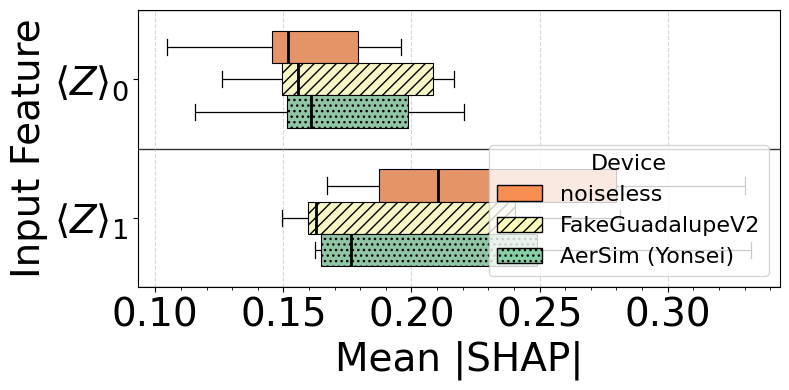

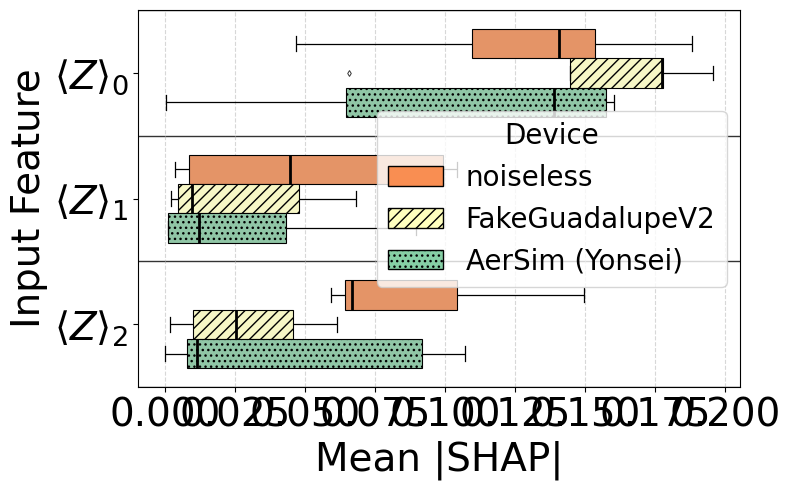

In [67]:
FIGSIZE_BY_PAIR = {
    ('HQCNN-EZ', 4): (8, 4),
    ('HQCNN-EZ', 8): (8, 5),
    ('HQCNN-EZ', 10): (8, 6),
    ('HQCNN-EM', 4): (8, 6),
    ('HQCNN-EM', 8): (8, 7),
    ('HQCNN-EM', 10): (8, 8),
}

FONTSIZE_BY_PAIR = {
    ('HQCNN-EZ', 4): 28,
    ('HQCNN-EZ', 8): 28,
    ('HQCNN-EZ', 10): 28,
    ('HQCNN-EM', 4): 28,
    ('HQCNN-EM', 8): 28,
    ('HQCNN-EM', 10): 28,
}

LEGEND_FONTSIZE_BY_PAIR = {
    ('HQCNN-EZ', 4): 16,
    ('HQCNN-EZ', 8): 20,
    ('HQCNN-EZ', 10): 20,
    ('HQCNN-EM', 4): 24,
    ('HQCNN-EM', 8): 24,
    ('HQCNN-EM', 10): 24,
}

LEGEND_POSITION_BY_PAIR = {
    ('HQCNN-EZ', 4): None,
    ('HQCNN-EZ', 8): None,
    ('HQCNN-EZ', 10): (1.0, 0.45),
    ('HQCNN-EM', 4): (1.0, 0.55),
    ('HQCNN-EM', 8): (1.0, 0.55),
    ('HQCNN-EM', 10): (1.0, 0.55)
}

for num_qubit in num_qubits[:-1]:
    for model_name in model_names_str_new:
        if model_name == 'QCNN':
            continue
        # elif model_name == 'HQCNN-EZ':
        #     continue
        elif model_name == 'HQCNN-EM':
            continue
        figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))  # fallback size
        plot_grouped_boxplots_for_model(absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
                                               num_qubit=num_qubit,
                                               model=model_name,
                                               figsize=figsize_value,
                                               title_fontsize=fontsize_value,
                                               axis_label_fontsize=fontsize_value,
                                               legend_size=legend_fontsize_value,
                                               tick_fontsize=fontsize_value,
                                               legend_loc='lower right',       # 'lower right', 'center right'
                                               lenged_pos=legend_position_value,
                                               plot_title=None,
                                               plot_save=PLOT_SAVE,
                                               save_dir=save_summary_results_dirs)
        
for num_qubit in num_qubits[-1:]:
    for model_name in model_names_str_new:
        if model_name == 'QCNN':
            continue
        # elif model_name == 'HQCNN-EZ':
        #     continue
        elif model_name == 'HQCNN-EM':
            continue
        figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))  # fallback size
        plot_grouped_boxplots_for_model(absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
                                               num_qubit=num_qubit,
                                               model=model_name,
                                               figsize=figsize_value,
                                               title_fontsize=fontsize_value,
                                               axis_label_fontsize=fontsize_value,
                                               legend_size=legend_fontsize_value,
                                               tick_fontsize=fontsize_value,
                                               legend_loc='center right',       # 'lower right', 'center right'
                                               lenged_pos=legend_position_value,
                                               plot_title=None,
                                               plot_save=PLOT_SAVE,
                                               save_dir=save_summary_results_dirs)

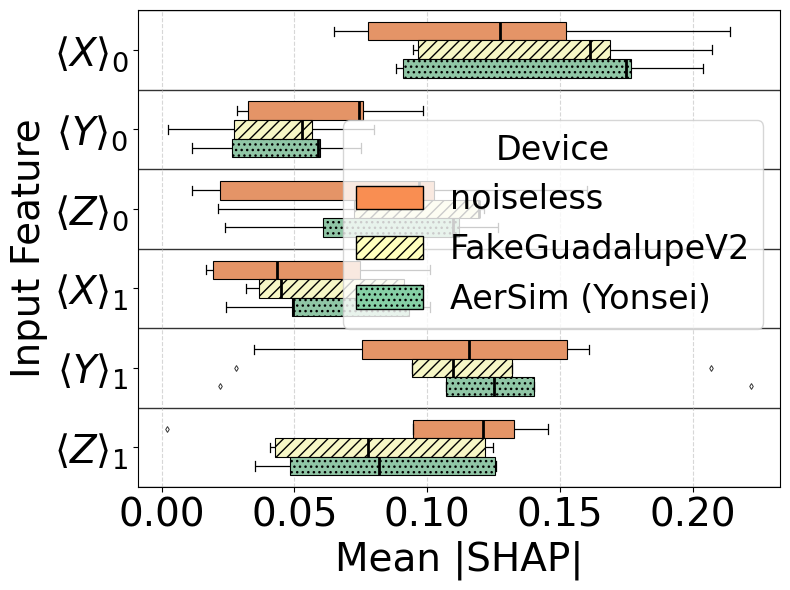

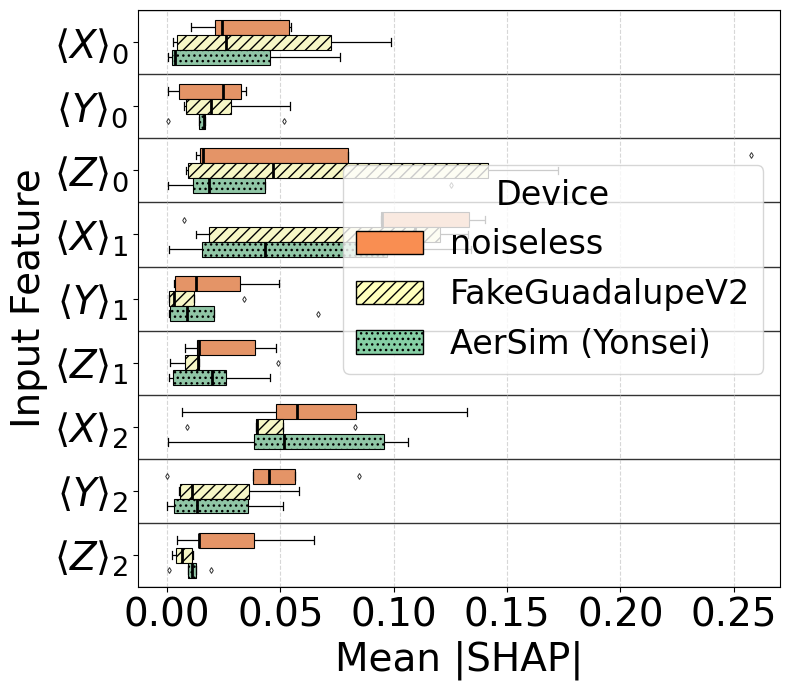

In [68]:
for num_qubit in num_qubits:
    for model_name in model_names_str_new:
        if model_name == 'QCNN':
            continue
        elif model_name == 'HQCNN-EZ':
            continue
        # elif model_name == 'HQCNN-EM':
        #     continue
        figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))  # fallback size
        plot_grouped_boxplots_for_model(absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
                                               num_qubit=num_qubit,
                                               model=model_name,
                                               figsize=figsize_value,
                                               title_fontsize=fontsize_value,
                                               axis_label_fontsize=fontsize_value,
                                               legend_size=legend_fontsize_value,
                                               tick_fontsize=fontsize_value,
                                               legend_loc='center right',       # 'lower right', 'center right'
                                               lenged_pos=legend_position_value,
                                               plot_title=None,
                                               plot_save=PLOT_SAVE,
                                               save_dir=save_summary_results_dirs)

In [69]:
import numpy as np
import seaborn as sns
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, StrMethodFormatter

def plot_grouped_horizontal_boxplots_for_model(
    shap_df,
    num_qubit,
    model,
    ax,
    title_fontsize=14,
    axis_label_fontsize=12,
    tick_fontsize=12,
    legend_size=8,
    legend_loc='lower right',
    legend_pos=(1.0, 0.5),
    plot_title=True,
    showfliers=True,
    whis=1.5
):
    """
    Draws grouped horizontal BOXPLOTS into a given Axes `ax`.
    Returns legend_handles (for a shared legend if desired).
    """
    df_model = shap_df[(shap_df['Model'] == model) &
                       (shap_df['Qubits'] == num_qubit)].copy()

    if df_model.empty:
        print(f"No data found for model={model}, q={num_qubit}")
        ax.set_visible(False)
        return []

    df_model['Device'] = df_model['Device'].replace({
        "AerSim with backend noise": "AerSim (Yonsei)"
    })

    # --- 1. Define Order ---
    if model == 'HQCNN-EZ':
        y_order = [f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))]
    elif model == 'HQCNN-EM':
        y_order = [f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit))))
                   for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']]
    else:
        y_order = df_model['Input_Feature'].drop_duplicates().tolist()
    
    # --- LaTeX Label Transformation ---
    latex_labels = [
        f"$\\langle {lbl.split('⟩_')[0].strip('⟨')} \\rangle_{{{lbl.split('_')[-1]}}}$" 
        if '⟨' in lbl else lbl 
        for lbl in y_order
    ]

    # Preserve first-appearance order for devices (hue)
    hue_order = df_model['Device'].drop_duplicates().tolist()

    # Deterministic color map per device
    palette_colors = sns.color_palette('Spectral', n_colors=len(hue_order))
    color_map = dict(zip(hue_order, palette_colors))

    # --- 2. Box Plot (apply same black-line + outlier styling) ---
    sns.boxplot(
        data=df_model,
        y='Input_Feature',
        x='Abs_SHAP',
        hue='Device',
        hue_order=hue_order,
        order=y_order,
        orient='h',
        palette=color_map,
        width=0.7,
        dodge=True,
        whis=whis,

        # --- Make lines black ---
        boxprops     = {"edgecolor": "black", "linewidth": 0.9},
        whiskerprops = {"color": "black", "linewidth": 0.9},
        capprops     = {"color": "black", "linewidth": 0.9},
        medianprops  = {"color": "black", "linewidth": 2.0},

        # --- Outliers ---
        showfliers=showfliers,
        flierprops={
            "marker": "d",
            "markersize": 3,
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markeredgewidth": 0.7,
            "alpha": 0.8,
        } if showfliers else None,

        ax=ax
    )
    
    # --- Draw Boundary Lines ---
    for y in range(len(y_order) + 1):
        ax.axhline(y - 0.5, color='black', linestyle='-', linewidth=1.0, alpha=0.8, zorder=0)
        
    # --- 3. Hatches (ROBUST for Boxplot) ---
    hatch_map = {
        'noiseless': None,
        'FakeGuadalupeV2': '///',
        'AerSim (Yonsei)': '...'
    }

    # Remove seaborn's auto legend (we return handles instead)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # --- Robust hatch assignment: match box -> device by facecolor ---
    rgba_map = {dev: mpl.colors.to_rgba(color_map[dev]) for dev in hue_order}

    def closest_device_by_color(fc_rgba, tol=1e-3):
        # near-exact match first
        for dev, rgba in rgba_map.items():
            if np.allclose(fc_rgba, rgba, atol=tol):
                return dev
        # fallback: closest distance
        devs = list(rgba_map.keys())
        dists = [np.linalg.norm(np.array(fc_rgba) - np.array(rgba_map[d])) for d in devs]
        return devs[int(np.argmin(dists))]

    # Seaborn may store box patches in ax.patches (matplotlib PathPatch)
    box_patches = [p for p in ax.patches if isinstance(p, mpl.patches.PathPatch)]

    for p in box_patches:
        dev = closest_device_by_color(p.get_facecolor())
        hatch = hatch_map.get(dev, None)

        # keep edges black and explicit width
        p.set_edgecolor('black')
        p.set_linewidth(0.8)

        if hatch:
            p.set_hatch(hatch)

    # --- 4. Legend Handles (color + hatch) ---
    legend_handles = [
        Patch(
            facecolor=color_map[device_name],
            edgecolor='black',
            hatch=hatch_map.get(device_name, None),
            label=device_name
        )
        for device_name in hue_order
    ]

    # --- 5. Formatting ---
    if plot_title:
        ax.set_title(f"{model}, {num_qubit}-qubits", fontsize=title_fontsize)

    ax.set_xlabel("Mean |SHAP|", fontsize=axis_label_fontsize)
    ax.set_ylabel("Input Feature", fontsize=axis_label_fontsize)
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(latex_labels, fontsize=tick_fontsize)
    
    if num_qubit == 4 and model == 'HQCNN-EZ':
        ax.xaxis.set_major_locator(MultipleLocator(0.05))
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
        ax.xaxis.set_minor_locator(MultipleLocator(0.01))

    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    # ax.grid(axis='y', linestyle='--', alpha=0.5) # Optional, consistent with reference

    return legend_handles

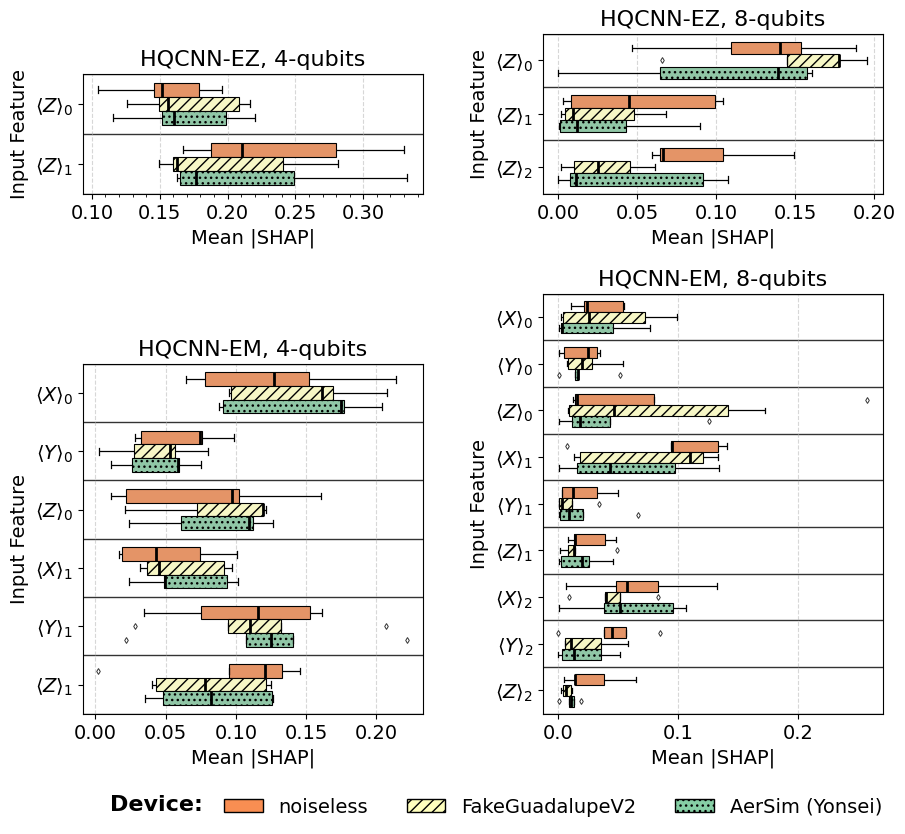

In [70]:
import matplotlib.pyplot as plt
import os

# --- Configurations ---
fig = plt.figure(figsize=(10, 10))  # Global Canvas

if len(num_qubits) == 2:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.08, 0.52, 0.34, 0.12])   # EZ, q4
    ax2 = fig.add_axes([0.54, 0.52, 0.34, 0.16])   # EZ, q8

    ax3 = fig.add_axes([0.08, 0.00, 0.34, 0.35])   # EM, q4
    ax4 = fig.add_axes([0.54, 0.00, 0.34, 0.42])   # EM, q8
    
    axes = [ax1, ax2, ax3, ax4]
    
elif len(num_qubits) == 3:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.00, 0.62, 0.26, 0.12])  # EZ, q4
    ax2 = fig.add_axes([0.36, 0.62, 0.26, 0.16])  # EZ, q8
    ax3 = fig.add_axes([0.72, 0.62, 0.26, 0.20])  # EZ, q10

    ax4 = fig.add_axes([0.00, 0.0, 0.26, 0.35])   # EM, q4
    ax5 = fig.add_axes([0.36, 0.0, 0.26, 0.42])   # EM, q8
    ax6 = fig.add_axes([0.72, 0.0, 0.26, 0.52])   # EM, q1
    
    axes = [ax1, ax2, ax3, ax4, ax5, ax6]

# num_qubits = [4, 8, 10]
models_for_rows = ['HQCNN-EZ', 'HQCNN-EM']

# Font sizes
title_font      = 16
subplot_title   = 16
axis_label_font = 14
tick_font       = 14
legend_font     = 14

legend_handles_shared = None

# --- Loop to Fill 2×3 Grid ---
idx = 0
for row, model_name in enumerate(models_for_rows):
    for col, nq in enumerate(num_qubits):
        current_ax = axes[idx]
        idx += 1
        
        # Call the BOXPLOT function
        handles = plot_grouped_horizontal_boxplots_for_model(
            shap_df=absolute_shap_values_df,
            num_qubit=nq,
            model=model_name,
            ax=current_ax,
            title_fontsize=subplot_title,
            axis_label_fontsize=axis_label_font,
            tick_fontsize=tick_font,
            legend_size=legend_font,
            legend_loc='center right',
            legend_pos=(1.0, 0.5),
            plot_title=True
        )
        
        # Save legend handles from the first populated subplot
        if legend_handles_shared is None and handles:
            legend_handles_shared = handles

# --- Global Legend ---
if legend_handles_shared:
    fig.legend(
        handles=legend_handles_shared,
        loc="lower center",
        bbox_to_anchor=(0.55, -0.12),
        ncol=len(legend_handles_shared),
        frameon=False,
        fontsize=legend_font,
        title_fontsize=legend_font
    )
    
    # "Device:" label
    fig.text(0.20, -0.091, "Device:", ha='right', va='center', fontsize=legend_font+2, fontweight='bold')

# --- Save ---
if PLOT_SAVE:
    os.makedirs(save_summary_results_dirs, exist_ok=True)
    filename = os.path.join(save_summary_results_dirs, 'Absolute_SHAP_Boxplot_2x3.pdf')
    fig.savefig(filename, dpi=300, bbox_inches='tight', format='pdf')
    print(f"✅ Plot saved as {filename}")

plt.show()

### Median barplot and parallel coordinate plot of Absolute SHAP values

In [71]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import os
# from matplotlib.lines import Line2D
# from matplotlib.ticker import MultipleLocator, StrMethodFormatter

# import matplotlib.pyplot as plt
# import seaborn as sns
# import matplotlib.markers as mmarkers
# from matplotlib.patches import Patch
# from matplotlib.collections import PathCollection
# from matplotlib.ticker import MultipleLocator, StrMethodFormatter, MaxNLocator

# def plot_grouped_horizontal_bars_for_model(shap_df, num_qubit, model,
#                                            title_fontsize=14, axis_label_fontsize=12, tick_fontsize=12,
#                                            legend_size=8, lenged_pos=(1.0, 0.50), legend_loc='lower right', 
#                                            plot_title=True, plot_save=False, figsize=(8, 6), save_dir='./'):
#     df_model = shap_df[shap_df['Model'] == model].copy()

#     if df_model.empty:
#         print(f"No data found for model: {model}")
#         return
    
#     df_model['Device'] = df_model['Device'].replace({
#         "AerSim with backend noise": "AerSim (Yonsei)"
#     })
    
#     plt.figure(figsize=figsize)
    
#     # --- Define Order ---
#     if model == 'HQCNN-EZ':
#         y_order = [f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))]
#     elif model == 'HQCNN-EM':
#         y_order = [f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']]
#     else:
#         y_order = df_model['Input_Feature'].drop_duplicates().tolist()
    
#     # --- LaTeX Label Transformation ---
#     latex_labels = [
#         f"$\\langle {lbl.split('⟩_')[0].strip('⟨')} \\rangle_{{{lbl.split('_')[-1]}}}$" 
#         if '⟨' in lbl else lbl 
#         for lbl in y_order
#     ]
    
#     hue_order = df_model['Device'].drop_duplicates().tolist()
#     palette_colors = sns.color_palette('Spectral', n_colors=len(hue_order))
#     color_map = dict(zip(hue_order, palette_colors))
    
#     hue_order = df_model['Device'].drop_duplicates().tolist()
#     palette_colors = sns.color_palette('Spectral', n_colors=len(hue_order))
#     color_map = dict(zip(hue_order, palette_colors))
    
#     # 1. Median Bars (Background)
#     ax = sns.barplot(
#         data=df_model,
#         y='Input_Feature',
#         x='Abs_SHAP',
#         hue='Device',
#         hue_order=hue_order,
#         orient='h',
#         palette=color_map, 
#         width=.8,
#         linewidth=.8,
#         edgecolor='black',
#         estimator=np.median,
#         errorbar=None
#     )
    
#     # 2. Exact Values (Overlay)
#     sns.stripplot(
#         data=df_model,
#         y='Input_Feature',
#         x='Abs_SHAP',
#         hue='Device',
#         hue_order=hue_order,
#         orient='h',
#         dodge=True,
#         palette=color_map,
#         edgecolor='black',
#         linewidth=1.0,
#         size=8,
#         jitter=True,
#         legend=False,
#         ax=ax
#     )
    
#     # 3. Apply Shapes (Markers) - FIXED
#     marker_map = {
#         'noiseless': 'o',
#         'FakeGuadalupeV2': 'X',
#         'AerSim (Yonsei)': 's'
#     }

#     # ✅ FIXED LINE: Check directly against PathCollection
#     scatter_collections = [c for c in ax.collections if isinstance(c, PathCollection)]
    
#     for i, collection in enumerate(scatter_collections):
#         if i >= len(hue_order): 
#             break
            
#         device_name = hue_order[i]
#         marker_char = marker_map.get(device_name, 'o')
        
#         # Create marker path
#         marker_obj = mmarkers.MarkerStyle(marker_char)
#         path = marker_obj.get_path().transformed(marker_obj.get_transform())
        
#         # Apply path
#         collection.set_paths([path])

#     # 4. Legend & Formatting
#     hatch_map = {
#         'noiseless': None,
#         'FakeGuadalupeV2': '///',
#         'AerSim (Yonsei)': '...'
#     }
    
#     for i, container in enumerate(ax.containers):
#         if i >= len(hue_order):
#             break
#         device_name = hue_order[i]
#         hatch = hatch_map.get(device_name, None)
#         if hatch:
#             for bar in container.patches:
#                 bar.set_hatch(hatch)

#     legend_handles = []
#     for device_name in hue_order:
#         # Get shape and color for legend
#         m_char = marker_map.get(device_name, 'o')
#         legend_handles.append(
#             # Use Line2D for the legend to show the Marker shape correctly
#             plt.Line2D([0], [0], 
#                        marker=m_char, 
#                        color='w', 
#                        markerfacecolor=color_map[device_name], 
#                        markeredgecolor='black',
#                        markersize=8, 
#                        label=device_name)
#         )
        
#     ax.legend(
#         handles=legend_handles,
#         title='Device',
#         fontsize=legend_size,
#         bbox_to_anchor=lenged_pos,
#         title_fontsize=legend_size,
#         loc=legend_loc
#     )
    
#     if plot_title:
#         plt.title(f"Mean Absolute SHAP Values — q{num_qubit}, {model}", fontsize=title_fontsize)
#     plt.xlabel("Mean |SHAP|", fontsize=axis_label_fontsize)
#     plt.ylabel("Input Feature", fontsize=axis_label_fontsize)
#     ax.set_yticks(range(len(y_order)))
#     ax.set_yticklabels(latex_labels, fontsize=tick_fontsize)
    
#     if num_qubit == 4 and model == 'HQCNN-EZ':
#         ax.xaxis.set_major_locator(MultipleLocator(0.05))
#         ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
#         ax.xaxis.set_minor_locator(MultipleLocator(0.01))
        
#     plt.xticks(fontsize=tick_fontsize)
#     plt.yticks(fontsize=tick_fontsize)
#     plt.grid(axis='x', linestyle='--', alpha=0.5)
#     plt.grid(axis='y', linestyle='--', alpha=0.5)
#     plt.tight_layout()
    
#     if plot_save:
#         os.makedirs(save_dir, exist_ok=True)
#         filename = os.path.join(save_dir, f'Absolute_SHAP_Median_Barplot_q{num_qubit}_{model}.png')
#         plt.savefig(filename, dpi=200, bbox_inches='tight')
#         print(f"✅ Plot saved as {filename}")
#     else:
#         plt.show()

# # --- Execution Block (Same Configs as Before) ---

# FIGSIZE_BY_PAIR = {
#     ('HQCNN-EZ', 4): (8, 4),
#     ('HQCNN-EZ', 8): (8, 5),
#     ('HQCNN-EZ', 10): (8, 6),
#     ('HQCNN-EM', 4): (8, 6),
#     ('HQCNN-EM', 8): (8, 7),
#     ('HQCNN-EM', 10): (8, 8),
# }

# FONTSIZE_BY_PAIR = {
#     ('HQCNN-EZ', 4): 28, ('HQCNN-EZ', 8): 28, ('HQCNN-EZ', 10): 28,
#     ('HQCNN-EM', 4): 28, ('HQCNN-EM', 8): 28, ('HQCNN-EM', 10): 28,
# }

# LEGEND_FONTSIZE_BY_PAIR = {
#     ('HQCNN-EZ', 4): 16, ('HQCNN-EZ', 8): 20, ('HQCNN-EZ', 10): 20,
#     ('HQCNN-EM', 4): 24, ('HQCNN-EM', 8): 24, ('HQCNN-EM', 10): 24,
# }

# LEGEND_POSITION_BY_PAIR = {
#     ('HQCNN-EZ', 4): None, ('HQCNN-EZ', 8): None, ('HQCNN-EZ', 10): (1.0, 0.45),
#     ('HQCNN-EM', 4): (1.0, 0.55), ('HQCNN-EM', 8): (1.0, 0.55), ('HQCNN-EM', 10): (1.0, 0.55)
# }

# # Run the plotting loop
# for num_qubit in num_qubits: # Adjusted to loop through all
#     for model_name in model_names_str_new:
#         if model_name == 'QCNN': continue
#         if model_name == 'HQCNN-EM': continue # Skip as per your example logic
#         # if model_name == 'HQCNN-EZ': continue # Skip as per your example logic

#         # Retrieve configurations
#         figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))
#         fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), 14)
#         legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), 10)
#         legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))

#         # Call the new scatter function
#         plot_grouped_horizontal_bars_for_model(
#             absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
#             num_qubit=num_qubit,
#             model=model_name,
#             figsize=figsize_value,
#             title_fontsize=fontsize_value,
#             axis_label_fontsize=fontsize_value,
#             legend_size=legend_fontsize_value,
#             tick_fontsize=fontsize_value,
#             legend_loc='center right',
#             lenged_pos=legend_position_value,
#             plot_title=None,
#             plot_save=PLOT_SAVE, # Ensure this variable is defined in your environment
#             save_dir=save_summary_results_dirs # Ensure this variable is defined
#         )

In [72]:
# # Run the plotting loop
# for num_qubit in num_qubits: # Adjusted to loop through all
#     for model_name in model_names_str_new:
#         if model_name == 'QCNN': continue
#         # if model_name == 'HQCNN-EM': continue # Skip as per your example logic
#         if model_name == 'HQCNN-EZ': continue

#         # Retrieve configurations
#         figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))
#         fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), 14)
#         legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), 10)
#         legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))

#         # Call the new scatter function
#         plot_grouped_horizontal_bars_for_model(
#             absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
#             num_qubit=num_qubit,
#             model=model_name,
#             figsize=figsize_value,
#             title_fontsize=fontsize_value,
#             axis_label_fontsize=fontsize_value,
#             legend_size=legend_fontsize_value,
#             tick_fontsize=fontsize_value,
#             legend_loc='center right',
#             lenged_pos=legend_position_value,
#             plot_title=None,
#             plot_save=PLOT_SAVE, # Ensure this variable is defined in your environment
#             save_dir=save_summary_results_dirs # Ensure this variable is defined
#         )

### Stripplot with Median-cross Barplot of Absolute SHAP values

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.markers as mmarkers
from matplotlib.collections import PathCollection
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, StrMethodFormatter
import os

def plot_stripplot_with_median_cross_bar_for_model(
    shap_df, num_qubit, model,
    title_fontsize=14, axis_label_fontsize=12, tick_fontsize=12,
    legend_size=8, lenged_pos=(1.0, 0.50), legend_loc='lower right', 
    plot_title=True, plot_save=False, figsize=(8, 6), save_dir='./'
):
    df_model = shap_df[shap_df['Model'] == model].copy()

    if df_model.empty:
        print(f"No data found for model: {model}")
        return
    
    # Standardize names
    df_model['Device'] = df_model['Device'].replace({
        "AerSim with backend noise": "AerSim (Yonsei)"
    })
    
    plt.figure(figsize=figsize)
    
    # --- Define Order ---
    if model == 'HQCNN-EZ':
        y_order = [f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))]
    elif model == 'HQCNN-EM':
        y_order = [f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']]
    else:
        y_order = df_model['Input_Feature'].drop_duplicates().tolist()
    
    # --- LaTeX Label Transformation ---
    latex_labels = [
        f"$\\langle {lbl.split('⟩_')[0].strip('⟨')} \\rangle_{{{lbl.split('_')[-1]}}}$" 
        if '⟨' in lbl else lbl 
        for lbl in y_order
    ]

    hue_order = df_model['Device'].drop_duplicates().tolist()
    
    palette_colors = sns.color_palette('pastel', n_colors=len(hue_order)) 
    color_map = dict(zip(hue_order, palette_colors))
    
    # --- CONFIGURATION ---        
    BAR_WIDTH = 0.8
    if model == 'HQCNN-EZ':
        BAR_WIDTH = 0.7
        dot_size = 8
    else:
        BAR_WIDTH = 0.7
        dot_size = 8

    # ✅ RELATIVE RED DOT SIZE
    # Scatter 's' is area (points^2). Stripplot 'size' is diameter (points).
    # We want Red Dot to be ~2.0x the diameter of the small dots.
    red_dot_size = (dot_size * 2.0) ** 2 
    
    ax = plt.gca() 

    # --- 1. Draw Boundary Lines ---
    for y in range(len(y_order) + 1):
        ax.axhline(y - 0.5, color='black', linestyle='-', linewidth=1.0, alpha=0.8, zorder=0)

    # --- CALCULATE OFFSETS ---
    num_hues = len(hue_order)
    hue_offsets = {
        device: (i - (num_hues - 1) / 2) * (BAR_WIDTH / num_hues)
        for i, device in enumerate(hue_order)
    }
    y_mapping = {feat: i for i, feat in enumerate(y_order)}

    # --- 2. Draw Grey Horizontal Range Lines ---
    # Connects the Min and Max SHAP values within each feature row
    for device in hue_order:
        device_offset = hue_offsets[device]
        d_df = df_model[df_model['Device'] == device]
        
        # Calculate Min and Max for each feature
        stats = d_df.groupby('Input_Feature')['Abs_SHAP'].agg(['min', 'max'])
        
        for feature in y_order:
            if feature in stats.index:
                x_min = stats.loc[feature, 'min']
                x_max = stats.loc[feature, 'max']
                y_pos = y_mapping[feature] + device_offset
                
                # Draw the straight horizontal grey line
                ax.plot(
                    [x_min, x_max], [y_pos, y_pos],
                    color='gray',
                    linestyle='-',
                    linewidth=2.0,
                    alpha=0.6,
                    zorder=1.5 # Above grid/zigzag, below median dot
                )

    # --- 3. Draw Parallel Coordinate Lines (ZigZag) ---
    # Kept as usual, using device colors
    styles_list = ['-', (0, (12, 3)), (0, (3, 2)), '-.', (0, (3, 1, 1, 1, 1, 2))]

    for device in hue_order:
        device_df = df_model[df_model['Device'] == device]
        device_color = color_map[device]
        offset = hue_offsets[device]
        iterations = device_df['sim_iter_num'].unique()
        
        for i, iteration in enumerate(iterations):
            iter_data = device_df[device_df['sim_iter_num'] == iteration].copy()
            iter_data['y_idx'] = iter_data['Input_Feature'].map(y_mapping)
            iter_data = iter_data.dropna(subset=['y_idx'])
            iter_data = iter_data.sort_values('y_idx')
            
            if iter_data.empty: continue

            x_coords = iter_data['Abs_SHAP'].values
            y_coords = iter_data['y_idx'].values + offset
            
            current_style = styles_list[i % len(styles_list)]
            
            ax.plot(
                x_coords, y_coords, color=device_color, 
                alpha=1.0, linewidth=2.5, linestyle=current_style, zorder=1 
            )

    # --- 4. Plot Medians (Big Red Dot) ---
    for device in hue_order:
        device_offset = hue_offsets[device]
        d_df = df_model[df_model['Device'] == device]
        medians = d_df.groupby('Input_Feature')['Abs_SHAP'].median()
        
        xs = []
        ys = []
        for feature in y_order:
            if feature in medians.index:
                xs.append(medians[feature])
                ys.append(y_mapping[feature] + device_offset)
        
        ax.scatter(
            xs, ys, 
            s=red_dot_size, # ✅ Using relative size
            color='red', 
            marker='o',
            edgecolor='none',
            zorder=2        # Behind the stripplot dots
        )

    # --- 5. Plot Dots (Stripplot) ---
    sns.stripplot(
        data=df_model,
        y='Input_Feature',
        x='Abs_SHAP',
        hue='Device',
        hue_order=hue_order,
        order=y_order,
        orient='h',
        dodge=True,
        palette=color_map, 
        edgecolor='black',
        linewidth=1.5,
        size=dot_size,
        jitter=False,
        legend=False,
        ax=ax,
        zorder=3 
    )
    
    # --- 5.5 Manually Align Dots ---
    if len(ax.collections) > 0:
        default_width = 0.8 
        default_offsets = {
            device: (i - (num_hues - 1) / 2) * (default_width / num_hues)
            for i, device in enumerate(hue_order)
        }
        for collection in ax.collections:
            if isinstance(collection, PathCollection):
                offsets = collection.get_offsets()
                try:
                    face_color = collection.get_facecolor()
                    if len(face_color) == 0: continue
                    face_color = face_color[0]
                    
                    # Skip Red Dots (Pure Red)
                    if np.allclose(face_color[:3], [1, 0, 0], atol=0.01): continue

                    matched_device = None
                    for device, map_rgb in color_map.items():
                        if np.allclose(face_color[:3], map_rgb, atol=0.01):
                            matched_device = device
                            break
                    if matched_device:
                        target_offset = hue_offsets[matched_device]
                        new_offsets = offsets.copy()
                        feature_indices = np.round(new_offsets[:, 1]) 
                        new_offsets[:, 1] = feature_indices + target_offset
                        collection.set_offsets(new_offsets)
                except Exception:
                    pass

    # --- 6. Apply Shapes ---
    marker_map = {'noiseless': 'o', 'FakeGuadalupeV2': 'X', 'AerSim (Yonsei)': 's'}

    for collection in ax.collections:
        if isinstance(collection, PathCollection):
            try:
                face_colors = collection.get_facecolor()
                if len(face_colors) == 0: continue
                current_rgba = face_colors[0]
                
                # Skip Red Dots
                if np.allclose(current_rgba[:3], [1, 0, 0], atol=0.01): continue
                
                matched_device = None
                for device, map_rgb in color_map.items():
                    if np.allclose(current_rgba[:3], map_rgb, atol=0.01):
                        matched_device = device
                        break
                
                if matched_device:
                    marker_char = marker_map.get(matched_device, 'o')
                    marker_obj = mmarkers.MarkerStyle(marker_char)
                    path = marker_obj.get_path().transformed(marker_obj.get_transform())
                    collection.set_paths([path])
            except Exception:
                continue

    # --- 7. Legend ---
    # ✅ Restored the Legend inside the function
    legend_handles = []
    for device_name in hue_order:
        legend_handles.append(
            Line2D([0], [0], marker=marker_map.get(device_name, 'o'), color='w', 
                   markerfacecolor=color_map[device_name], markeredgecolor='black',
                   markersize=8, label=device_name)
        )
        
    ax.legend(handles=legend_handles, title='Device', fontsize=legend_size,
              bbox_to_anchor=lenged_pos, title_fontsize=legend_size, loc=legend_loc)
    
    # --- 8. Formatting (Preserved Exactly) ---
    if plot_title:
        plt.title(f"SHAP Values (Parallel Coord) — q{num_qubit}, {model}", fontsize=title_fontsize)
    plt.xlabel("Mean |SHAP|", fontsize=axis_label_fontsize)
    plt.ylabel("Input Feature", fontsize=axis_label_fontsize)
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(latex_labels, fontsize=tick_fontsize)
    
    if num_qubit == 4 and model == 'HQCNN-EZ':
        ax.xaxis.set_major_locator(MultipleLocator(0.05))
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
        ax.xaxis.set_minor_locator(MultipleLocator(0.01))
        
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.grid(axis='x', linestyle='-', color='gray', alpha=0.8) 
    plt.tight_layout()
    
    if plot_save:
        os.makedirs(save_dir, exist_ok=True)
        filename = os.path.join(save_dir, f'Absolute_SHAP_Median_Parallel_q{num_qubit}_{model}.png')
        plt.savefig(filename, dpi=200, bbox_inches='tight')
        print(f"✅ Plot saved as {filename}")
    else:
        plt.show()

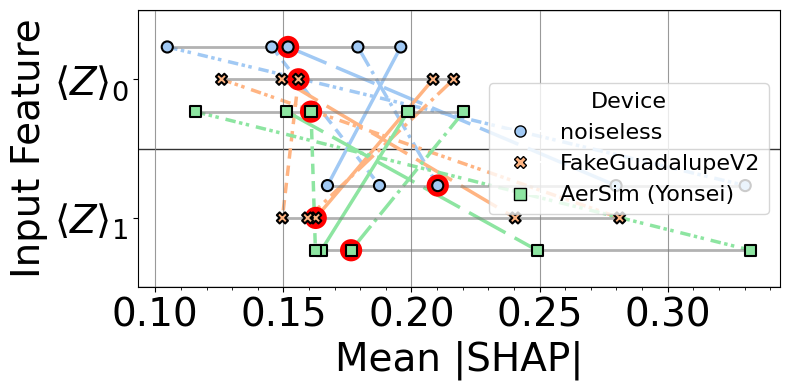

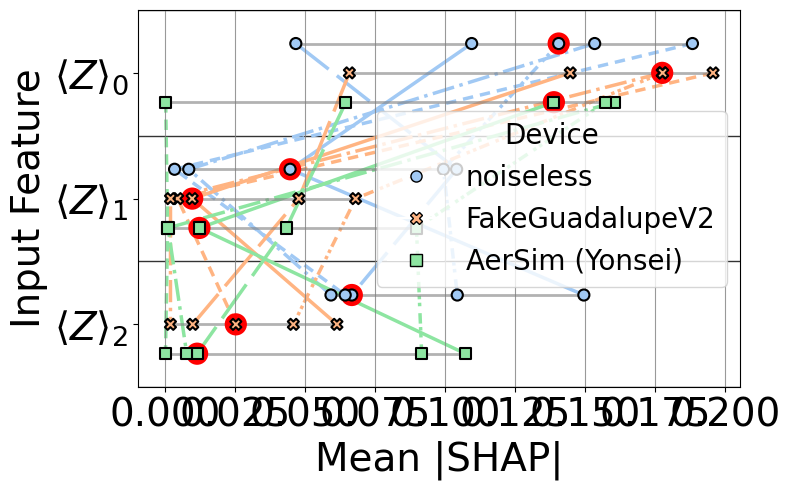

In [74]:
# --- Execution Block (Same Configs as Before) ---
FIGSIZE_BY_PAIR = {
    ('HQCNN-EZ', 4): (8, 4),    ('HQCNN-EZ', 8): (8, 5),    ('HQCNN-EZ', 10): (8, 6),
    ('HQCNN-EM', 4): (8, 6),    ('HQCNN-EM', 8): (8, 7),    ('HQCNN-EM', 10): (8, 8),
    }

FONTSIZE_BY_PAIR = {
    ('HQCNN-EZ', 4): 28,    ('HQCNN-EZ', 8): 28,    ('HQCNN-EZ', 10): 28,
    ('HQCNN-EM', 4): 28,    ('HQCNN-EM', 8): 28,    ('HQCNN-EM', 10): 28,
    }

LEGEND_FONTSIZE_BY_PAIR = {
    ('HQCNN-EZ', 4): 16,    ('HQCNN-EZ', 8): 20,    ('HQCNN-EZ', 10): 20,
    ('HQCNN-EM', 4): 24,    ('HQCNN-EM', 8): 24,    ('HQCNN-EM', 10): 24,
    }

LEGEND_POSITION_BY_PAIR = {
    ('HQCNN-EZ', 4): None,           ('HQCNN-EZ', 8): None,           ('HQCNN-EZ', 10): (1.0, 0.45),
    ('HQCNN-EM', 4): (1.0, 0.55),    ('HQCNN-EM', 8): (1.0, 0.55),    ('HQCNN-EM', 10): (1.0, 0.55),
    }

# Run the plotting loop
for num_qubit in num_qubits: # Adjusted to loop through all
    for model_name in model_names_str_new:
        if model_name == 'QCNN': continue
        elif model_name == 'HQCNN-EM': continue # Skip as per your example logic
        # elif model_name == 'HQCNN-EZ': continue

        # Retrieve configurations
        figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))
        fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), 14)
        legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), 10)
        legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))

        # Call the new scatter function
        plot_stripplot_with_median_cross_bar_for_model(
            absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
            num_qubit=num_qubit,
            model=model_name,
            figsize=figsize_value,
            title_fontsize=fontsize_value,
            axis_label_fontsize=fontsize_value,
            legend_size=legend_fontsize_value,
            tick_fontsize=fontsize_value,
            legend_loc='center right',
            lenged_pos=legend_position_value,
            plot_title=None,
            plot_save=PLOT_SAVE, # Ensure this variable is defined in your environment
            save_dir=save_summary_results_dirs # Ensure this variable is defined
        )

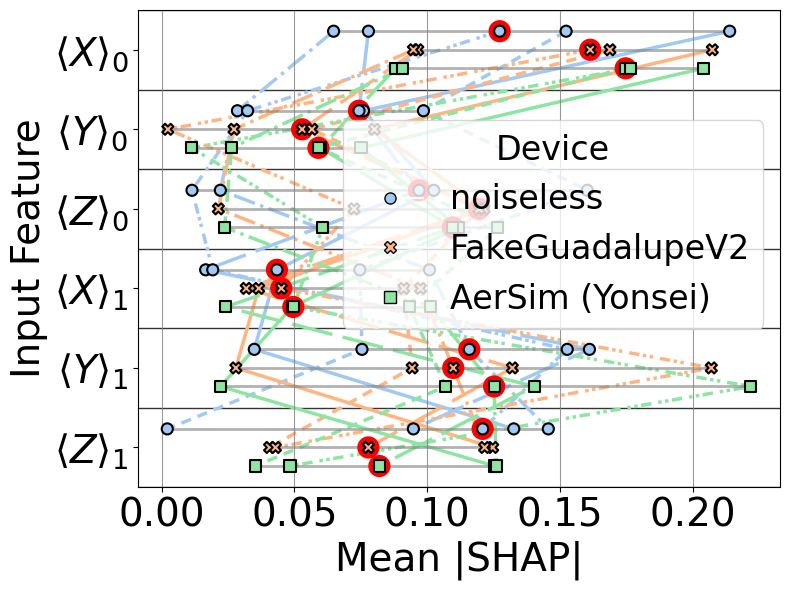

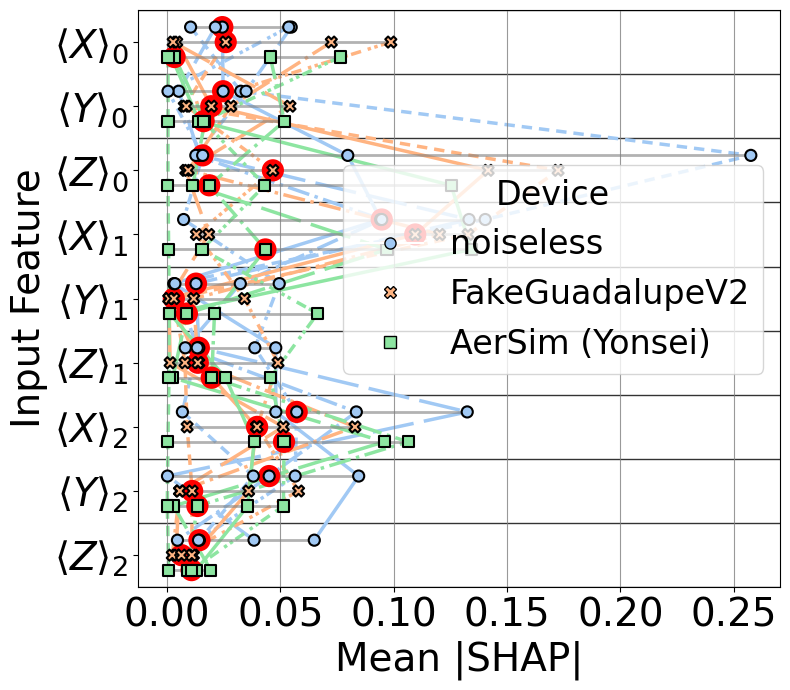

In [75]:
# Run the plotting loop
for num_qubit in num_qubits: # Adjusted to loop through all
    for model_name in model_names_str_new:
        if model_name == 'QCNN': continue
        # elif model_name == 'HQCNN-EM': continue # Skip as per your example logic
        elif model_name == 'HQCNN-EZ': continue

        # Retrieve configurations
        figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))
        fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), 14)
        legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), 10)
        legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))

        # Call the new scatter function
        plot_stripplot_with_median_cross_bar_for_model(
            absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
            num_qubit=num_qubit,
            model=model_name,
            figsize=figsize_value,
            title_fontsize=fontsize_value,
            axis_label_fontsize=fontsize_value,
            legend_size=legend_fontsize_value,
            tick_fontsize=fontsize_value,
            legend_loc='center right',
            lenged_pos=legend_position_value,
            plot_title=None,
            plot_save=PLOT_SAVE, # Ensure this variable is defined in your environment
            save_dir=save_summary_results_dirs # Ensure this variable is defined
        )

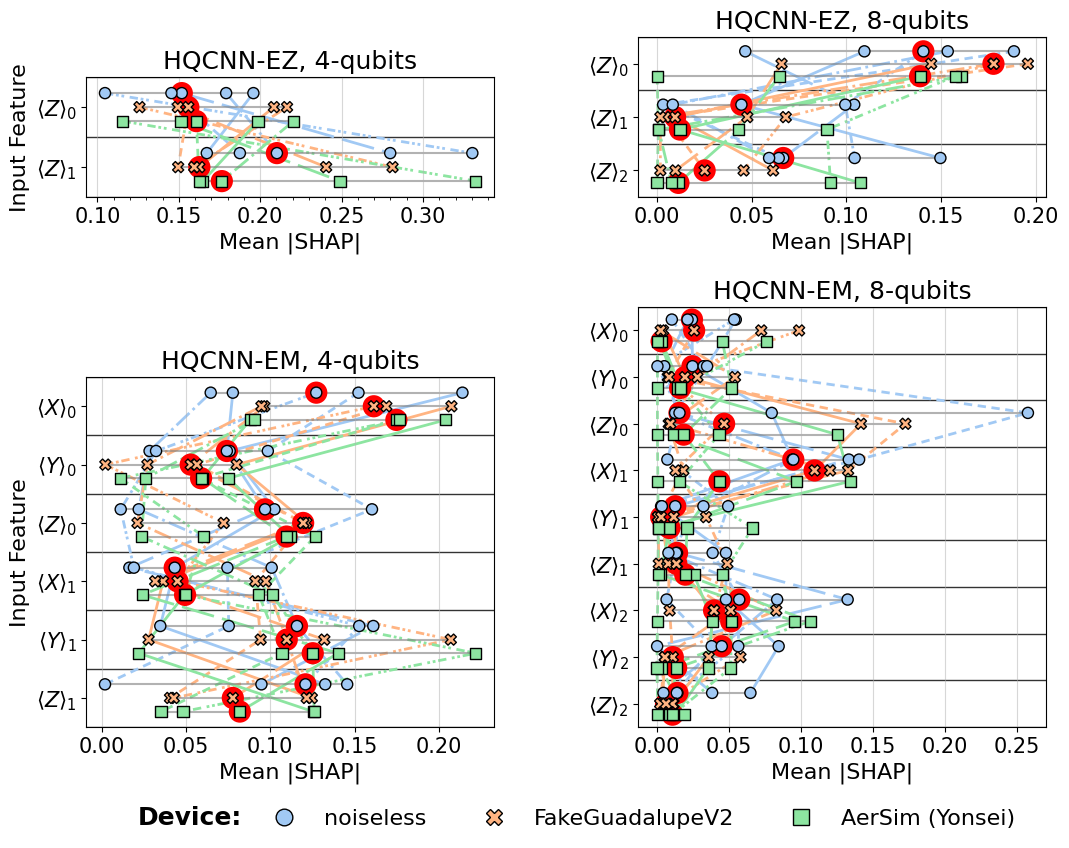

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.markers as mmarkers
from matplotlib.collections import PathCollection
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, StrMethodFormatter
import os

def plot_stripplot_with_median_cross_bar_for_model(
    shap_df, num_qubit, model,
    ax=None,  # <--- NEW ARGUMENT for 2x3 grid support
    title_fontsize=14, axis_label_fontsize=12, tick_fontsize=12,
    legend_size=8, lenged_pos=(1.0, 0.50), legend_loc='lower right', 
    plot_title=True, plot_save=False, figsize=(8, 6), save_dir='./'
):
    df_model = shap_df[shap_df['Model'] == model].copy()

    if df_model.empty:
        print(f"No data found for model: {model}")
        return []

    # Standardize names
    df_model['Device'] = df_model['Device'].replace({
        "AerSim with backend noise": "AerSim (Yonsei)"
    })
    
    # Use provided axis or create new one (backward compatibility)
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    # --- Define Order ---
    if model == 'HQCNN-EZ':
        y_order = [f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))]
    elif model == 'HQCNN-EM':
        y_order = [f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']]
    else:
        y_order = df_model['Input_Feature'].drop_duplicates().tolist()
    
    # --- LaTeX Label Transformation ---
    latex_labels = [
        f"$\\langle {lbl.split('⟩_')[0].strip('⟨')} \\rangle_{{{lbl.split('_')[-1]}}}$" 
        if '⟨' in lbl else lbl 
        for lbl in y_order
    ]
    
    hue_order = df_model['Device'].drop_duplicates().tolist()
    
    palette_colors = sns.color_palette('pastel', n_colors=len(hue_order)) 
    color_map = dict(zip(hue_order, palette_colors))
    
    # --- CONFIGURATION ---        
    BAR_WIDTH = 0.8
    if model == 'HQCNN-EZ':
        BAR_WIDTH = 0.7
        dot_size = 8
    else:
        BAR_WIDTH = 0.7
        dot_size = 8

    # ✅ RELATIVE RED DOT SIZE
    # Scatter 's' is area (points^2). Stripplot 'size' is diameter (points).
    red_dot_size = (dot_size * 2.0) ** 2 

    # --- 1. Draw Boundary Lines ---
    for y in range(len(y_order) + 1):
        ax.axhline(y - 0.5, color='black', linestyle='-', linewidth=1.0, alpha=0.8, zorder=0)

    # --- CALCULATE OFFSETS ---
    num_hues = len(hue_order)
    hue_offsets = {
        device: (i - (num_hues - 1) / 2) * (BAR_WIDTH / num_hues)
        for i, device in enumerate(hue_order)
    }
    y_mapping = {feat: i for i, feat in enumerate(y_order)}

    # --- 2. Draw Grey Horizontal Range Lines ---
    # Connects the Min and Max SHAP values within each feature row
    for device in hue_order:
        device_offset = hue_offsets[device]
        d_df = df_model[df_model['Device'] == device]
        
        # Calculate Min and Max for each feature
        stats = d_df.groupby('Input_Feature')['Abs_SHAP'].agg(['min', 'max'])
        
        for feature in y_order:
            if feature in stats.index:
                x_min = stats.loc[feature, 'min']
                x_max = stats.loc[feature, 'max']
                y_pos = y_mapping[feature] + device_offset
                
                # Draw the straight horizontal grey line
                ax.plot(
                    [x_min, x_max], [y_pos, y_pos],
                    color='gray',
                    linestyle='-',
                    linewidth=1.5,
                    alpha=0.6,
                    zorder=1.5 # Above boundary, below median dot
                )

    # --- 3. Draw Parallel Coordinate Lines (ZigZag) ---
    styles_list = ['-', (0, (12, 3)), (0, (3, 2)), '-.', (0, (3, 1, 1, 1, 1, 2))]

    for device in hue_order:
        device_df = df_model[df_model['Device'] == device]
        device_color = color_map[device]
        offset = hue_offsets[device]
        iterations = device_df['sim_iter_num'].unique()
        
        for i, iteration in enumerate(iterations):
            iter_data = device_df[device_df['sim_iter_num'] == iteration].copy()
            iter_data['y_idx'] = iter_data['Input_Feature'].map(y_mapping)
            iter_data = iter_data.dropna(subset=['y_idx'])
            iter_data = iter_data.sort_values('y_idx')
            
            if iter_data.empty: continue

            x_coords = iter_data['Abs_SHAP'].values
            y_coords = iter_data['y_idx'].values + offset
            
            current_style = styles_list[i % len(styles_list)]
            
            ax.plot(
                x_coords, y_coords, color=device_color, 
                alpha=1.0, linewidth=2.0, linestyle=current_style, zorder=1 
            )

    # --- 4. Plot Medians (Big Red Dot) ---
    for device in hue_order:
        device_offset = hue_offsets[device]
        d_df = df_model[df_model['Device'] == device]
        medians = d_df.groupby('Input_Feature')['Abs_SHAP'].median()
        
        xs = []
        ys = []
        for feature in y_order:
            if feature in medians.index:
                xs.append(medians[feature])
                ys.append(y_mapping[feature] + device_offset)
        
        ax.scatter(
            xs, ys, 
            s=red_dot_size, 
            color='red', 
            marker='o',
            edgecolor='none',
            zorder=2        # Behind the stripplot dots
        )

    # --- 5. Plot Dots (Stripplot) ---
    sns.stripplot(
        data=df_model,
        y='Input_Feature',
        x='Abs_SHAP',
        hue='Device',
        hue_order=hue_order,
        order=y_order,
        orient='h',
        dodge=True,
        palette=color_map, 
        edgecolor='black',
        linewidth=1.0,
        size=dot_size,
        jitter=False,
        legend=False,
        ax=ax,
        zorder=3 
    )
    
    # --- 5.5 Manually Align Dots ---
    if len(ax.collections) > 0:
        default_width = 0.8 
        default_offsets = {
            device: (i - (num_hues - 1) / 2) * (default_width / num_hues)
            for i, device in enumerate(hue_order)
        }
        for collection in ax.collections:
            if isinstance(collection, PathCollection):
                offsets = collection.get_offsets()
                try:
                    face_color = collection.get_facecolor()
                    if len(face_color) == 0: continue
                    face_color = face_color[0]
                    
                    # Skip Red Dots (Pure Red)
                    if np.allclose(face_color[:3], [1, 0, 0], atol=0.01): continue

                    matched_device = None
                    for device, map_rgb in color_map.items():
                        if np.allclose(face_color[:3], map_rgb, atol=0.01):
                            matched_device = device
                            break
                    if matched_device:
                        target_offset = hue_offsets[matched_device]
                        new_offsets = offsets.copy()
                        feature_indices = np.round(new_offsets[:, 1]) 
                        new_offsets[:, 1] = feature_indices + target_offset
                        collection.set_offsets(new_offsets)
                except Exception:
                    pass

    # --- 6. Apply Shapes ---
    marker_map = {'noiseless': 'o', 'FakeGuadalupeV2': 'X', 'AerSim (Yonsei)': 's'}

    for collection in ax.collections:
        if isinstance(collection, PathCollection):
            try:
                face_colors = collection.get_facecolor()
                if len(face_colors) == 0: continue
                current_rgba = face_colors[0]
                
                # Skip Red Dots
                if np.allclose(current_rgba[:3], [1, 0, 0], atol=0.01): continue
                
                matched_device = None
                for device, map_rgb in color_map.items():
                    if np.allclose(current_rgba[:3], map_rgb, atol=0.01):
                        matched_device = device
                        break
                
                if matched_device:
                    marker_char = marker_map.get(matched_device, 'o')
                    marker_obj = mmarkers.MarkerStyle(marker_char)
                    path = marker_obj.get_path().transformed(marker_obj.get_transform())
                    collection.set_paths([path])
            except Exception:
                continue

    # --- 7. Legend Handles ---
    legend_handles = []
    for device_name in hue_order:
        legend_handles.append(
            Line2D([0], [0], marker=marker_map.get(device_name, 'o'), color='w', 
                   markerfacecolor=color_map[device_name], markeredgecolor='black',
                   markersize=12, label=device_name)
        )
    
    # --- 8. Formatting ---
    if plot_title:
        ax.set_title(f"{model}, {num_qubit}-qubits", fontsize=title_fontsize)
        
    ax.set_xlabel("Mean |SHAP|", fontsize=axis_label_fontsize)
    # Only show Y label for the left-most columns if desired
    if ax.get_position().x0 < 0.1: 
        ax.set_ylabel("Input Feature", fontsize=axis_label_fontsize)
    else:
        ax.set_ylabel("") 
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(latex_labels, fontsize=tick_fontsize)
    
    if num_qubit == 4 and model == 'HQCNN-EZ':
        ax.xaxis.set_major_locator(MultipleLocator(0.05))
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
        ax.xaxis.set_minor_locator(MultipleLocator(0.01))
        
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.grid(axis='x', linestyle='-', alpha=0.5) 
    
    # Remove per-plot legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    
    return legend_handles


# ==========================================
#      EXECUTION BLOCK (2x3 GRID PLOT)
# ==========================================

# --- Configurations ---
fig = plt.figure(figsize=(12, 10))  # One global canvas

if len(num_qubits) == 2:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.08, 0.53, 0.34, 0.12])   # EZ, q4
    ax2 = fig.add_axes([0.54, 0.53, 0.34, 0.16])   # EZ, q8

    ax3 = fig.add_axes([0.08, 0.00, 0.34, 0.35])   # EM, q4
    ax4 = fig.add_axes([0.54, 0.00, 0.34, 0.42])   # EM, q8
    
    axes = [ax1, ax2, ax3, ax4]
    
elif len(num_qubits) == 3:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.00, 0.63, 0.26, 0.12])  # EZ, q4
    ax2 = fig.add_axes([0.36, 0.63, 0.26, 0.16])  # EZ, q8
    ax3 = fig.add_axes([0.72, 0.63, 0.26, 0.20])  # EZ, q10

    ax4 = fig.add_axes([0.00, 0.0, 0.26, 0.35])   # EM, q4
    ax5 = fig.add_axes([0.36, 0.0, 0.26, 0.42])   # EM, q8
    ax6 = fig.add_axes([0.72, 0.0, 0.26, 0.52])   # EM, q1
    
    axes = [ax1, ax2, ax3, ax4, ax5, ax6]

# num_qubits = [4, 8, 10]
models_for_rows = ['HQCNN-EZ', 'HQCNN-EM']

# Font sizes
title_font      = 16
subplot_title   = 18
axis_label_font = 16
tick_font       = 15
legend_font     = 16

legend_handles_shared = None

# --- Loop to Fill 2×3 Grid ---
idx = 0
for row, model_name in enumerate(models_for_rows):
    for col, nq in enumerate(num_qubits):
        current_ax = axes[idx]
        idx += 1
        
        # Call the updated function
        handles = plot_stripplot_with_median_cross_bar_for_model(
            shap_df=absolute_shap_values_df[absolute_shap_values_df['Qubits'] == nq],
            num_qubit=nq,
            model=model_name,
            ax=current_ax,
            title_fontsize=subplot_title,
            axis_label_fontsize=axis_label_font,
            tick_fontsize=tick_font,
            legend_size=legend_font,
            plot_title=True
        )
        
        # Capture handles from the first valid plot
        if legend_handles_shared is None and handles:
            legend_handles_shared = handles

# --- Global Legend ---
if legend_handles_shared:
    fig.legend(
        handles=legend_handles_shared,
        loc="lower center",
        bbox_to_anchor=(0.54, -0.122),
        ncol=len(legend_handles_shared),
        frameon=False,
        fontsize=legend_font,
        title_fontsize=legend_font
    )
    
    fig.text(0.21, -0.091, "Device:", ha='right', va='center', fontsize=legend_font+2, fontweight='bold')

# --- Save ---
if PLOT_SAVE:
    os.makedirs(save_summary_results_dirs, exist_ok=True)
    filename = os.path.join(save_summary_results_dirs, 'Absolute_SHAP_Median_Parallel_2x3.pdf')
    fig.savefig(filename, dpi=300, bbox_inches='tight', format='pdf')
    print(f"✅ Plot saved as {filename}")

plt.show()

### RANK stability plot: Blop plots to visualize rank

In [77]:
# # [num_qubit][model_name][model_spec][ns]
# all_shap_values_combined_dict[4]['model_mmTmbF']['AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01']['0'].data

In [78]:
absolute_shap_values_df

,Device,Qubits,Model,Model_spec,sim_iter_num,Input_Feature,Abs_SHAP
0,noiseless,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,⟨Z⟩_0,0.195812
1,noiseless,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,⟨Z⟩_1,0.167193
2,noiseless,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,⟨Z⟩_0,0.151827
3,noiseless,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,⟨Z⟩_1,0.279834
4,noiseless,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,2,⟨Z⟩_0,0.145479
...,...,...,...,...,...,...,...
295,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,⟨Y⟩_1,0.066386
296,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,⟨Y⟩_2,0.051279
297,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,⟨Z⟩_0,0.043101
298,AerSim with backend noise,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,⟨Z⟩_1,0.045537


In [79]:
# Assuming your DataFrame is named 'df' or 'absolute_shap_values_df'

# 1. Define the grouping columns (columns that define a single experiment/iteration)
group_cols = ['Device', 'Qubits', 'Model', 'Model_spec', 'sim_iter_num']

# 2. Apply rank
# ascending=False: Highest value gets Rank 1
# method='min': Ties get the lowest rank number (e.g., if two are tied for 1st, both get 1)
absolute_shap_values_df['Rank_Abs_SHAP'] = absolute_shap_values_df.groupby(group_cols)['Abs_SHAP'] \
                                            .rank(ascending=False, method='min')

# Optional: Convert to integer if you prefer clean numbers (1 instead of 1.0)
absolute_shap_values_df['Rank_Abs_SHAP'] = absolute_shap_values_df['Rank_Abs_SHAP'].astype(int)

# Inspect the result
print(absolute_shap_values_df[['Device', 'sim_iter_num', 'Input_Feature', 'Abs_SHAP', 'Rank_Abs_SHAP']].head(10))

      Device  sim_iter_num Input_Feature  Abs_SHAP  Rank_Abs_SHAP
0  noiseless             0         ⟨Z⟩_0  0.195812              1
1  noiseless             0         ⟨Z⟩_1  0.167193              2
2  noiseless             1         ⟨Z⟩_0  0.151827              2
3  noiseless             1         ⟨Z⟩_1  0.279834              1
4  noiseless             2         ⟨Z⟩_0  0.145479              2
5  noiseless             2         ⟨Z⟩_1  0.187507              1
6  noiseless             3         ⟨Z⟩_0  0.179076              2
7  noiseless             3         ⟨Z⟩_1  0.210250              1
8  noiseless             4         ⟨Z⟩_0  0.104673              2
9  noiseless             4         ⟨Z⟩_1  0.330277              1


In [80]:
if SUMMRAY_TABLE_SAVE:
    absolute_shap_values_df.to_csv(save_summary_results_dirs+'absolute_shap_values_df_test.csv',
                                   encoding='utf-8-sig')

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, MaxNLocator
import os

def plot_rank_stability_bubbles_text_for_model(
    shap_df, num_qubit, model,
    ax=None,
    title_fontsize=14, axis_label_fontsize=12, tick_fontsize=12,
    legend_size=10, legend_pos=(1.0, 0.5), legend_loc='center right',
    plot_title=True, plot_save=False, figsize=(10, 8), save_dir='./'
):
    """
    Plots a Rank Stability Bubble Plot with raw COUNT labels.
    """
    
    # 1. Filter Data
    df_model = shap_df[shap_df['Model'] == model].copy()
    if df_model.empty:
        print(f"No data found for model: {model}")
        return

    # Standardize names
    df_model['Device'] = df_model['Device'].replace({
        "AerSim with backend noise": "AerSim (Yonsei)"
    })
    
    # 2. Setup Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    # 3. Define Y-Order (Top-to-Bottom)
    if model == 'HQCNN-EZ':
        y_order = [f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))]
    elif model == 'HQCNN-EM':
        y_order = [f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']]
    else:
        y_order = df_model['Input_Feature'].drop_duplicates().tolist()
    
    # --- LaTeX Label Transformation ---
    latex_labels = [
        f"$\\langle {lbl.split('⟩_')[0].strip('⟨')} \\rangle_{{{lbl.split('_')[-1]}}}$" 
        if '⟨' in lbl else lbl 
        for lbl in y_order
    ]
    
    hue_order = df_model['Device'].drop_duplicates().tolist()
    palette_colors = sns.color_palette('pastel', n_colors=len(hue_order)) 
    color_map = dict(zip(hue_order, palette_colors))
    
    # 4. Configuration
    BAR_WIDTH = 0.7
    num_hues = len(hue_order)
    hue_offsets = {
        device: (i - (num_hues - 1) / 2) * (BAR_WIDTH / num_hues)
        for i, device in enumerate(hue_order)
    }
    y_mapping = {feat: i for i, feat in enumerate(y_order)}

    # --- 5. Draw Boundary Lines ---
    for y in range(len(y_order) + 1):
        ax.axhline(y - 0.5, color='black', linestyle='-', linewidth=1.0, alpha=0.8, zorder=0)

    # 6. Calculate Rank Counts & Ratios
    # We need 'count' for the label and 'ratio' for the bubble size (to keep visuals normalized)
    rank_counts = df_model.groupby(['Device', 'Input_Feature', 'Rank_Abs_SHAP']).size().reset_index(name='count')
    total_counts = df_model.groupby(['Device', 'Input_Feature']).size().reset_index(name='total')
    rank_counts = pd.merge(rank_counts, total_counts, on=['Device', 'Input_Feature'])
    rank_counts['ratio'] = rank_counts['count'] / rank_counts['total']
    
    # # RANK FILTER: Keep only Rank 1 to 5 ---
    # rank_counts = rank_counts[rank_counts['Rank_Abs_SHAP'] <= 5]
    
    # Scaling Factor for Bubble Size
    BUBBLE_SCALE = 600 

    # 7. Plot Bubbles & Text
    max_rank_found = 1
    
    for device in hue_order:
        device_data = rank_counts[rank_counts['Device'] == device]
        device_color = color_map[device]
        offset = hue_offsets[device]
        
        # Filter for current features
        device_data = device_data[device_data['Input_Feature'].isin(y_order)].copy()
        if device_data.empty: continue
        
        # Map Y coordinates
        device_data['y_coord'] = device_data['Input_Feature'].map(y_mapping) + offset
        
        # Track max rank
        current_max = device_data['Rank_Abs_SHAP'].max()
        if not np.isnan(current_max):
            max_rank_found = max(max_rank_found, current_max)
            
        # A. Draw the Bubbles
        ax.scatter(
            x=device_data['Rank_Abs_SHAP'],
            y=device_data['y_coord'],
            s=device_data['ratio'] * BUBBLE_SCALE, # Visual size based on ratio (fair comparison)
            color=device_color,
            alpha=0.8,
            edgecolors='black',
            linewidth=0.5,
            label=device,
            zorder=3
        )
        
        # B. Draw Text Labels (RAW COUNT) Next to Bubbles
        for _, row in device_data.iterrows():
            count_val = int(row['count'])
            
            ax.text(
                x=row['Rank_Abs_SHAP'] + 0.25, 
                y=row['y_coord'],
                s=str(count_val),  # <--- CHANGED TO RAW COUNT
                fontsize=10,        
                color='black',
                verticalalignment='center',
                horizontalalignment='left',
                zorder=4,
                fontweight='bold'
            )

    # 8. Formatting X-Axis
    ax.grid(axis='x', linestyle='-', color='gray', alpha=0.6, zorder=0)
    ax.set_xlim(0.5, max_rank_found + 0.8) 
    ax.xaxis.set_major_locator(MultipleLocator(1)) 
    
    # 9. Formatting Y-Axis (Top to Bottom)
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(y_order, fontsize=tick_fontsize)
    ax.invert_yaxis() 
    
    ax.set_xlabel("Rank (1 = Highest |SHAP|)", fontsize=axis_label_fontsize)
    ax.set_ylabel("Input Feature", fontsize=axis_label_fontsize)
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(latex_labels, fontsize=tick_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    
    if plot_title:
        plt.title(f"Rank Stability — {model}, {num_qubit}-qubits", fontsize=title_fontsize)

    # 10. Legend
    device_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[d], 
               markeredgecolor='black', markersize=8, label=d)
        for d in hue_order
    ]
    
    ax.legend(handles=device_handles, title="Device", 
              bbox_to_anchor=legend_pos, loc=legend_loc, fontsize=legend_size)

    plt.tight_layout()
    
    if plot_save:
        os.makedirs(save_dir, exist_ok=True)
        filename = os.path.join(save_dir, f'Absolute_SHAP_Rank_Stability_{model}_{num_qubit}q.png')
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"✅ Plot saved as {filename}")
    else:
        plt.show()

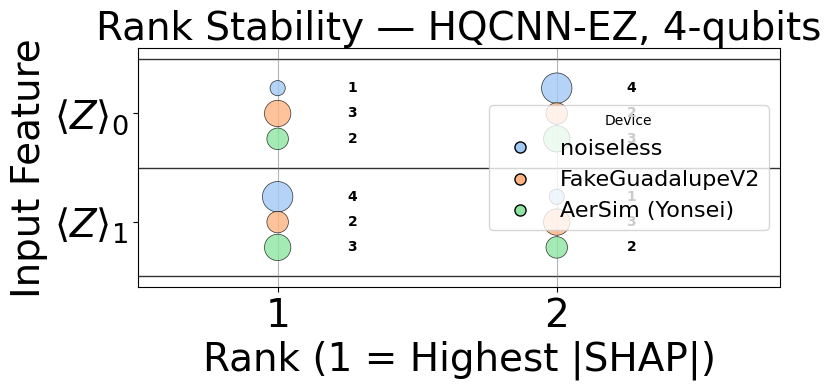

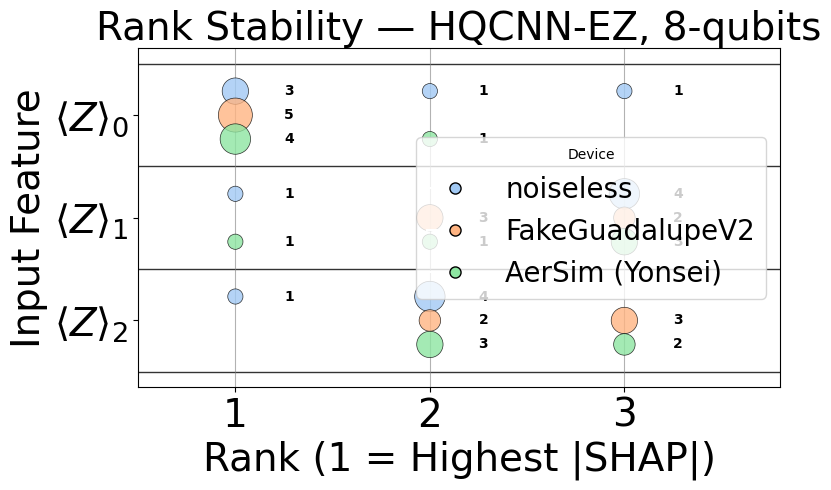

In [82]:
# --- Configuration Dictionaries ---
# (Ensure FIGSIZE_BY_PAIR, etc. are defined)

for num_qubit in num_qubits: 
    for model_name in model_names_str_new:
        if model_name == 'QCNN': continue
        elif model_name == 'HQCNN-EM': continue 
        # elif model_name == 'HQCNN-EZ': continue

        # Retrieve configurations
        figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))
        fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), 14)
        legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), 10)
        legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))

        # Call the updated function
        plot_rank_stability_bubbles_text_for_model(
            shap_df=absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
            num_qubit=num_qubit,
            model=model_name,
            figsize=figsize_value,
            title_fontsize=fontsize_value,
            axis_label_fontsize=fontsize_value,
            legend_size=legend_fontsize_value,
            tick_fontsize=fontsize_value,
            legend_loc='center right',
            legend_pos=legend_position_value,
            plot_title=True,
            plot_save=PLOT_SAVE, 
            save_dir=save_summary_results_dirs 
        )

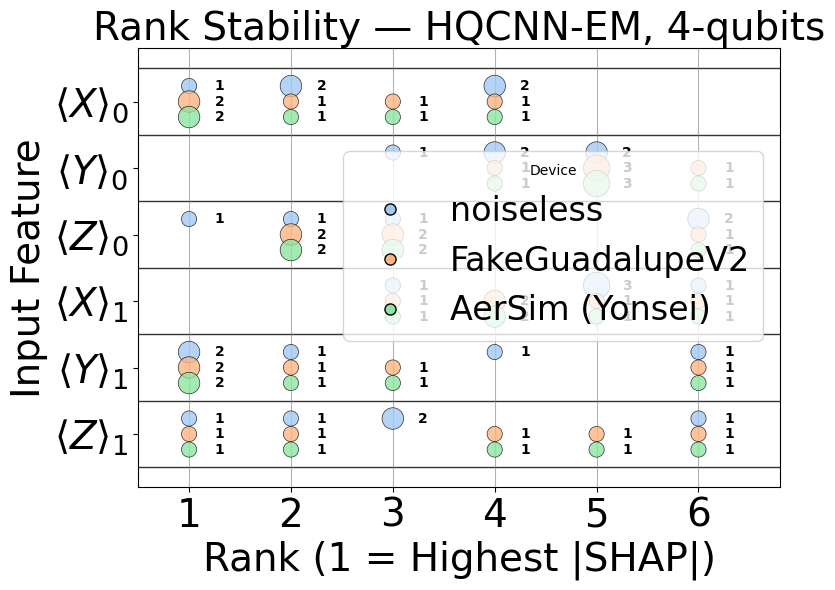

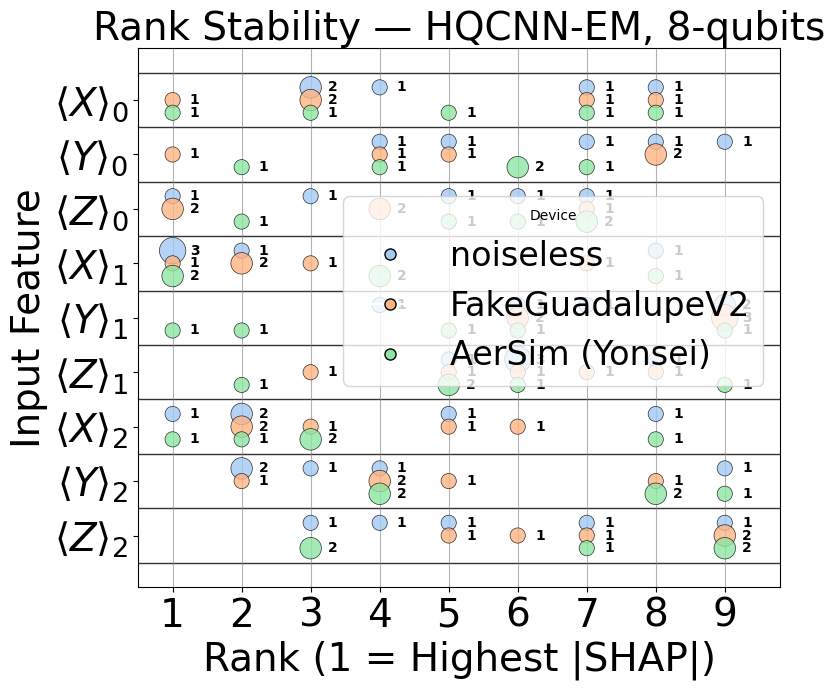

In [83]:
# --- Configuration Dictionaries ---
# (Ensure FIGSIZE_BY_PAIR, etc. are defined)

for num_qubit in num_qubits: 
    for model_name in model_names_str_new:
        if model_name == 'QCNN': continue
        # elif model_name == 'HQCNN-EM': continue
        elif model_name == 'HQCNN-EZ': continue

        # Retrieve configurations
        figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))
        fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), 14)
        legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), 10)
        legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))

        # Call the updated function
        plot_rank_stability_bubbles_text_for_model(
            shap_df=absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
            num_qubit=num_qubit,
            model=model_name,
            figsize=figsize_value,
            title_fontsize=fontsize_value,
            axis_label_fontsize=fontsize_value,
            legend_size=legend_fontsize_value,
            tick_fontsize=fontsize_value,
            legend_loc='center right',
            legend_pos=legend_position_value,
            plot_title=True,
            plot_save=PLOT_SAVE, 
            save_dir=save_summary_results_dirs 
        )

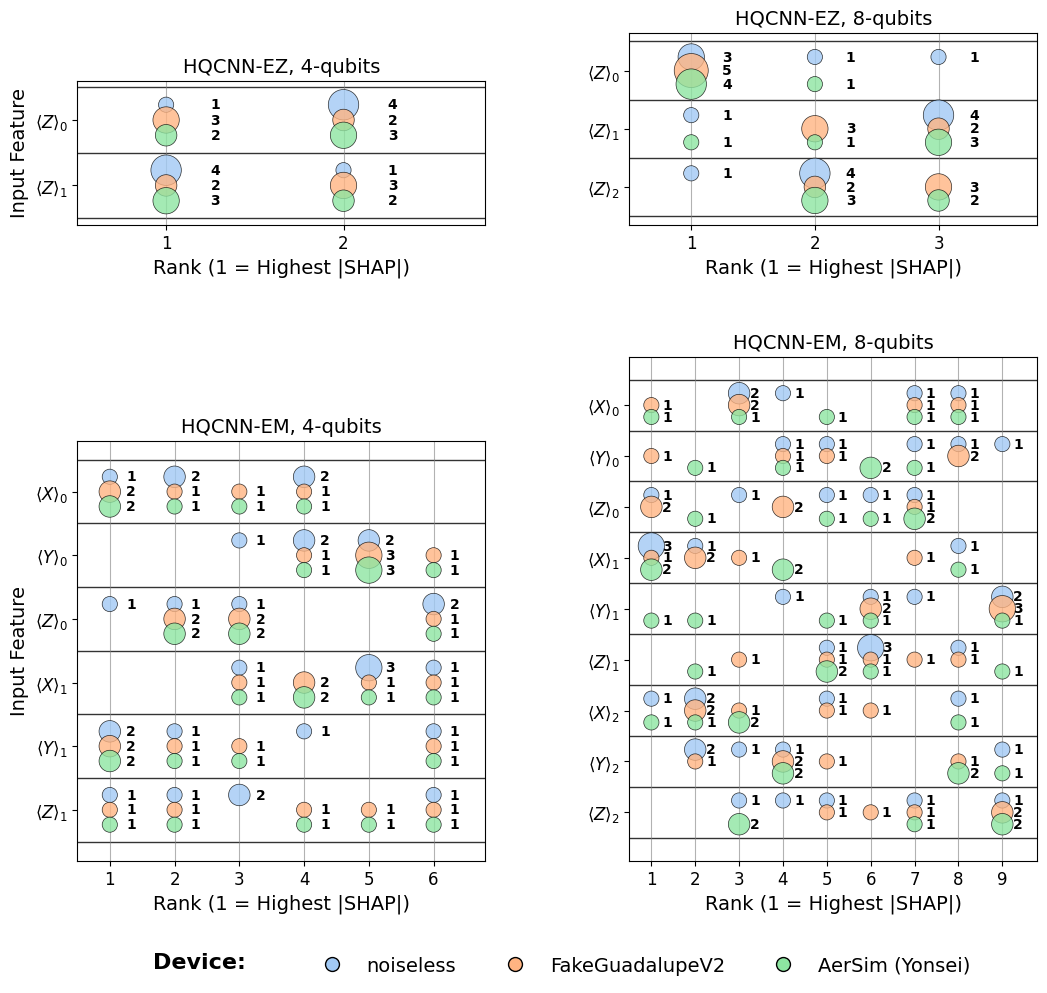

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
import os

def plot_rank_stability_bubbles_text_for_model(
    shap_df, num_qubit, model,
    ax=None,
    title_fontsize=14, axis_label_fontsize=12, tick_fontsize=12,
    legend_size=10, 
    plot_title=True
):
    """
    Plots a Rank Stability Bubble Plot on a specific axis (ax).
    Returns legend_handles for global legend creation.
    """
    
    # 1. Filter Data
    df_model = shap_df[shap_df['Model'] == model].copy()
    if df_model.empty:
        print(f"No data found for model: {model}")
        return []

    # Standardize names
    df_model['Device'] = df_model['Device'].replace({
        "AerSim with backend noise": "AerSim (Yonsei)"
    })
    
    # 2. Setup Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,6))
    
    # 3. Define Y-Order (Top-to-Bottom)
    if model == 'HQCNN-EZ':
        y_order = [f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))]
    elif model == 'HQCNN-EM':
        y_order = [f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']]
    else:
        y_order = df_model['Input_Feature'].drop_duplicates().tolist()
    
    # --- LaTeX Label Transformation ---
    latex_labels = [
        f"$\\langle {lbl.split('⟩_')[0].strip('⟨')} \\rangle_{{{lbl.split('_')[-1]}}}$" 
        if '⟨' in lbl else lbl 
        for lbl in y_order
    ]
    
    hue_order = df_model['Device'].drop_duplicates().tolist()
    palette_colors = sns.color_palette('pastel', n_colors=len(hue_order)) 
    color_map = dict(zip(hue_order, palette_colors))
    
    # 4. Configuration
    BAR_WIDTH = 0.7
    num_hues = len(hue_order)
    hue_offsets = {
        device: (i - (num_hues - 1) / 2) * (BAR_WIDTH / num_hues)
        for i, device in enumerate(hue_order)
    }
    y_mapping = {feat: i for i, feat in enumerate(y_order)}

    # --- 5. Draw Boundary Lines ---
    for y in range(len(y_order) + 1):
        ax.axhline(y - 0.5, color='black', linestyle='-', linewidth=1.0, alpha=0.8, zorder=0)

    # 6. Calculate Rank Counts & Ratios
    rank_counts = df_model.groupby(['Device', 'Input_Feature', 'Rank_Abs_SHAP']).size().reset_index(name='count')
    total_counts = df_model.groupby(['Device', 'Input_Feature']).size().reset_index(name='total')
    rank_counts = pd.merge(rank_counts, total_counts, on=['Device', 'Input_Feature'])
    rank_counts['ratio'] = rank_counts['count'] / rank_counts['total']
    
    # # RANK FILTER: Keep only Rank 1 to 5 ---
    # rank_counts = rank_counts[rank_counts['Rank_Abs_SHAP'] <= 5]
    
    # Scaling Factor for Bubble Size
    BUBBLE_SCALE = 600 

    # 7. Plot Bubbles & Text
    max_rank_found = 1
    
    for device in hue_order:
        device_data = rank_counts[rank_counts['Device'] == device]
        device_color = color_map[device]
        offset = hue_offsets[device]
        
        # Filter for current features
        device_data = device_data[device_data['Input_Feature'].isin(y_order)].copy()
        if device_data.empty: continue
        
        # Map Y coordinates
        device_data['y_coord'] = device_data['Input_Feature'].map(y_mapping) + offset
        
        # Track max rank
        current_max = device_data['Rank_Abs_SHAP'].max()
        if not np.isnan(current_max):
            max_rank_found = max(max_rank_found, current_max)
            
        # A. Draw the Bubbles
        ax.scatter(
            x=device_data['Rank_Abs_SHAP'],
            y=device_data['y_coord'],
            s=device_data['ratio'] * BUBBLE_SCALE, 
            color=device_color,
            alpha=0.8,
            edgecolors='black',
            linewidth=0.5,
            label=device,
            zorder=3
        )
        
        # B. Draw Text Labels (RAW COUNT) Next to Bubbles
        for _, row in device_data.iterrows():
            count_val = int(row['count'])
            
            ax.text(
                x=row['Rank_Abs_SHAP'] + 0.25, 
                y=row['y_coord'],
                s=str(count_val), 
                fontsize=10,        
                color='black',
                verticalalignment='center',
                horizontalalignment='left',
                zorder=4,
                fontweight='bold'
            )

    # 8. Formatting X-Axis
    ax.grid(axis='x', linestyle='-', color='gray', alpha=0.6, zorder=0)
    ax.set_xlim(0.5, max_rank_found + 0.8) 
    ax.xaxis.set_major_locator(MultipleLocator(1)) 
    
    # 9. Formatting Y-Axis (Top to Bottom)
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(y_order, fontsize=tick_fontsize)
    ax.invert_yaxis() 
    
    ax.set_xlabel("Rank (1 = Highest |SHAP|)", fontsize=axis_label_fontsize)
    
    # Only show Y label for left-most columns
    if ax.get_position().x0 < 0.1:
        ax.set_ylabel("Input Feature", fontsize=axis_label_fontsize)
    else:
        ax.set_ylabel("")
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(latex_labels, fontsize=tick_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    
    if plot_title:
        ax.set_title(f"{model}, {num_qubit}-qubits", fontsize=title_fontsize)

    # 10. Prepare Legend Handles (But don't plot on ax)
    device_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[d], 
               markeredgecolor='black', markersize=10, label=d)
        for d in hue_order
    ]
    
    return device_handles

import os

# --- Configurations ---
fig = plt.figure(figsize=(12, 12))  # Global Canvas

if len(num_qubits) == 2:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.08, 0.53, 0.34, 0.12])   # EZ, q4
    ax2 = fig.add_axes([0.54, 0.53, 0.34, 0.16])   # EZ, q8

    ax3 = fig.add_axes([0.08, 0.00, 0.34, 0.35])   # EM, q4
    ax4 = fig.add_axes([0.54, 0.00, 0.34, 0.42])   # EM, q8
    
    axes = [ax1, ax2, ax3, ax4]
    
elif len(num_qubits) == 3:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.00, 0.63, 0.26, 0.12])  # EZ, q4
    ax2 = fig.add_axes([0.36, 0.63, 0.26, 0.16])  # EZ, q8
    ax3 = fig.add_axes([0.72, 0.63, 0.26, 0.20])  # EZ, q10

    ax4 = fig.add_axes([0.00, 0.0, 0.26, 0.35])   # EM, q4
    ax5 = fig.add_axes([0.36, 0.0, 0.26, 0.42])   # EM, q8
    ax6 = fig.add_axes([0.72, 0.0, 0.26, 0.52])   # EM, q1
    
    axes = [ax1, ax2, ax3, ax4, ax5, ax6]

# num_qubits = [4, 8, 10]
models_for_rows = ['HQCNN-EZ', 'HQCNN-EM']

# Font sizes
title_font      = 16
subplot_title   = 14
axis_label_font = 14
tick_font       = 12
legend_font     = 14

legend_handles_shared = None

# --- Loop to Fill 2×3 Grid ---
idx = 0
for row, model_name in enumerate(models_for_rows):
    for col, nq in enumerate(num_qubits):
        current_ax = axes[idx]
        idx += 1
        
        # Call Function
        handles = plot_rank_stability_bubbles_text_for_model(
            shap_df=absolute_shap_values_df[absolute_shap_values_df['Qubits'] == nq],
            num_qubit=nq,
            model=model_name,
            ax=current_ax,
            title_fontsize=subplot_title,
            axis_label_fontsize=axis_label_font,
            tick_fontsize=tick_font,
            legend_size=legend_font,
            plot_title=True
        )
        
        # Save legend handles from the first valid plot
        if legend_handles_shared is None and handles:
            legend_handles_shared = handles

# --- Global Legend ---
if legend_handles_shared:
    fig.legend(
        handles=legend_handles_shared,
        loc="lower center",
        bbox_to_anchor=(0.55, -0.11),
        ncol=len(legend_handles_shared),
        frameon=False,
        fontsize=legend_font,
        title_fontsize=legend_font
    )
    
    # "Device:" Label
    fig.text(0.22, -0.085, "Device:", ha='right', va='center', fontsize=legend_font+2, fontweight='bold')

# --- Save ---
if PLOT_SAVE:
    os.makedirs(save_summary_results_dirs, exist_ok=True)
    filename = os.path.join(save_summary_results_dirs, 'Absolute_SHAP_Rank_Stability_Bubbles_2x3.pdf')
    fig.savefig(filename, dpi=300, bbox_inches='tight', format='pdf')
    print(f"✅ Plot saved as {filename}")

plt.show()

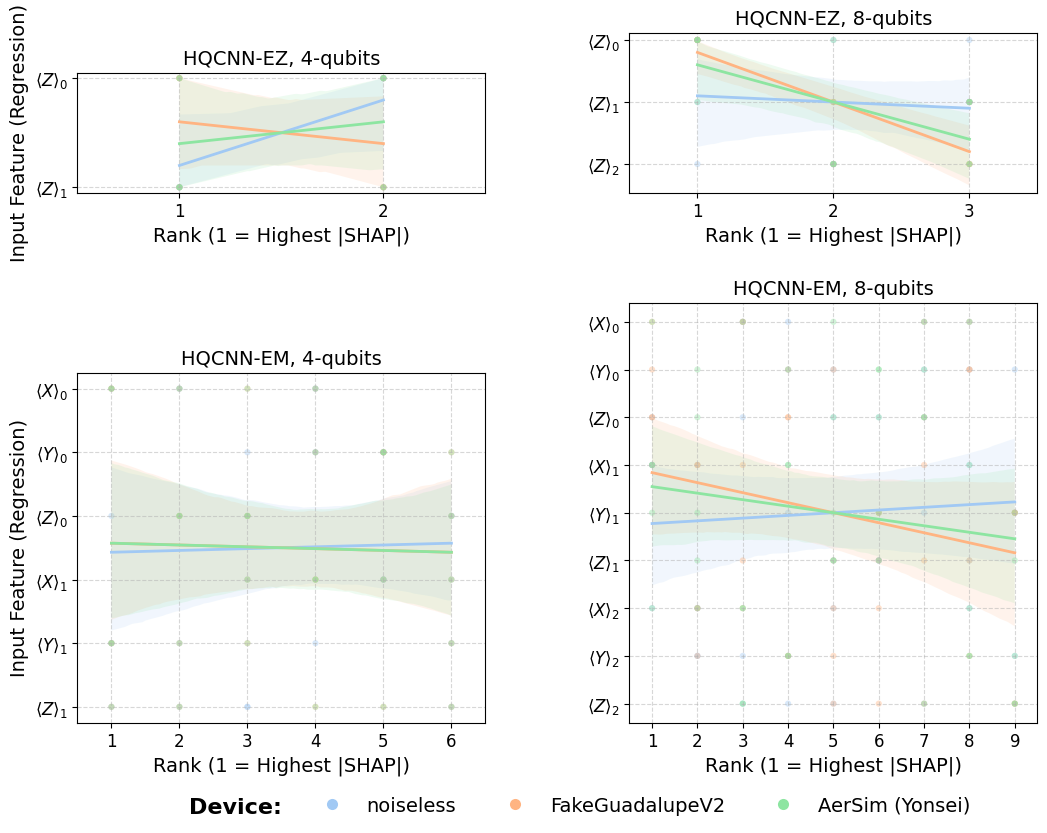

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, MaxNLocator
import os

def plot_rank_linear_regression_for_model(
    shap_df, num_qubit, model,
    ax=None,
    title_fontsize=14, axis_label_fontsize=12, tick_fontsize=12,
    legend_size=10, 
    plot_title=True
):
    """
    Plots a Linear Regression of Rank (X) vs Input Feature Index (Y).
    """
    
    # 1. Filter Data
    df_model = shap_df[shap_df['Model'] == model].copy()
    if df_model.empty:
        print(f"No data found for model: {model}")
        return []

    # Standardize names
    df_model['Device'] = df_model['Device'].replace({
        "AerSim with backend noise": "AerSim (Yonsei)"
    })
    
    # 2. Setup Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,6))
    
    # 3. Define Y-Order (Feature Order)
    if model == 'HQCNN-EZ':
        y_order = [f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))]
    elif model == 'HQCNN-EM':
        y_order = [f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']]
    else:
        y_order = df_model['Input_Feature'].drop_duplicates().tolist()
    
    # --- LaTeX Label Transformation ---
    latex_labels = [
        f"$\\langle {lbl.split('⟩_')[0].strip('⟨')} \\rangle_{{{lbl.split('_')[-1]}}}$" 
        if '⟨' in lbl else lbl 
        for lbl in y_order
    ]
    
    hue_order = df_model['Device'].drop_duplicates().tolist()
    palette_colors = sns.color_palette('pastel', n_colors=len(hue_order)) 
    color_map = dict(zip(hue_order, palette_colors))
    
    # 4. Map Features to Numeric Indices for Regression
    # y_order[0] -> 0, y_order[1] -> 1, ...
    y_mapping = {feat: i for i, feat in enumerate(y_order)}
    df_model['y_idx'] = df_model['Input_Feature'].map(y_mapping)
    
    # Drop rows where feature isn't in our list (safety)
    df_model = df_model.dropna(subset=['y_idx'])

    # 5. Plot Regression Lines per Device
    # We loop because sns.regplot doesn't natively support 'hue' with a legend easily on existing axes
    for device in hue_order:
        device_data = df_model[df_model['Device'] == device]
        if device_data.empty: continue
        
        # Plot using Seaborn Regplot
        # scatter_kws={'alpha':0.3}: Makes points semi-transparent so we see density
        # ci=None: Removes confidence interval shading for cleaner lines (optional)
        sns.regplot(
            data=device_data,
            x='Rank_Abs_SHAP',
            y='y_idx',
            color=color_map[device],
            ax=ax,
            scatter=True,
            fit_reg=True,
            label=device,
            scatter_kws={'s': 20, 'alpha': 0.4, 'edgecolor': 'none'},
            line_kws={'linewidth': 2.0, 'alpha': 1.0}
        )

    # 6. Formatting Y-Axis (Map Numbers back to Names)
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(y_order, fontsize=tick_fontsize)
    ax.invert_yaxis() # Top=0
    
    # 7. Formatting X-Axis
    max_rank = df_model['Rank_Abs_SHAP'].max()
    ax.set_xlim(0.5, max_rank + 0.5)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.grid(True, linestyle='--', alpha=0.5)

    ax.set_xlabel("Rank (1 = Highest |SHAP|)", fontsize=axis_label_fontsize)
    
    # Only show Y label for left-most plots
    if ax.get_position().x0 < 0.1:
        ax.set_ylabel("Input Feature (Regression)", fontsize=axis_label_fontsize)
    else:
        ax.set_ylabel("")
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(latex_labels, fontsize=tick_fontsize)

    if plot_title:
        ax.set_title(f"{model}, {num_qubit}-qubits", fontsize=title_fontsize)

    # 8. Prepare Legend Handles
    device_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[d], 
               markeredgecolor='none', markersize=8, label=d)
        for d in hue_order
    ]
    
    return device_handles

# --- Configurations ---
fig = plt.figure(figsize=(12, 10))  # Global Canvas

if len(num_qubits) == 2:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.08, 0.53, 0.34, 0.12])   # EZ, q4
    ax2 = fig.add_axes([0.54, 0.53, 0.34, 0.16])   # EZ, q8

    ax3 = fig.add_axes([0.08, 0.00, 0.34, 0.35])   # EM, q4
    ax4 = fig.add_axes([0.54, 0.00, 0.34, 0.42])   # EM, q8
    
    axes = [ax1, ax2, ax3, ax4]
    
elif len(num_qubits) == 3:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.00, 0.63, 0.26, 0.12])  # EZ, q4
    ax2 = fig.add_axes([0.36, 0.63, 0.26, 0.16])  # EZ, q8
    ax3 = fig.add_axes([0.72, 0.63, 0.26, 0.20])  # EZ, q10

    ax4 = fig.add_axes([0.00, 0.0, 0.26, 0.35])   # EM, q4
    ax5 = fig.add_axes([0.36, 0.0, 0.26, 0.42])   # EM, q8
    ax6 = fig.add_axes([0.72, 0.0, 0.26, 0.52])   # EM, q10
    
    axes = [ax1, ax2, ax3, ax4, ax5, ax6]

# num_qubits = [4, 8, 10]
models_for_rows = ['HQCNN-EZ', 'HQCNN-EM']

# Font sizes
title_font      = 16
subplot_title   = 14
axis_label_font = 14
tick_font       = 12
legend_font     = 14

legend_handles_shared = None

# --- Loop to Fill 2×3 Grid ---
idx = 0
for row, model_name in enumerate(models_for_rows):
    for col, nq in enumerate(num_qubits):
        current_ax = axes[idx]
        idx += 1
        
        # Call Function
        handles = plot_rank_linear_regression_for_model(
            shap_df=absolute_shap_values_df[absolute_shap_values_df['Qubits'] == nq],
            num_qubit=nq,
            model=model_name,
            ax=current_ax,
            title_fontsize=subplot_title,
            axis_label_fontsize=axis_label_font,
            tick_fontsize=tick_font,
            legend_size=legend_font,
            plot_title=True
        )
        
        if legend_handles_shared is None and handles:
            legend_handles_shared = handles

# --- Global Legend ---
if legend_handles_shared:
    fig.legend(
        handles=legend_handles_shared,
        loc="lower center",
        bbox_to_anchor=(0.55, -0.11),
        ncol=len(legend_handles_shared),
        frameon=False,
        fontsize=legend_font,
        title_fontsize=legend_font
    )
    
    fig.text(0.25, -0.085, "Device:", ha='right', va='center', fontsize=legend_font+2, fontweight='bold')

# --- Save ---
if PLOT_SAVE:
    os.makedirs(save_summary_results_dirs, exist_ok=True)
    filename = os.path.join(save_summary_results_dirs, 'Absolute_SHAP_Rank_Stability_Reg_2x3.pdf')
    fig.savefig(filename, dpi=300, bbox_inches='tight', format='pdf')
    print(f"✅ Plot saved as {filename}")

plt.show()

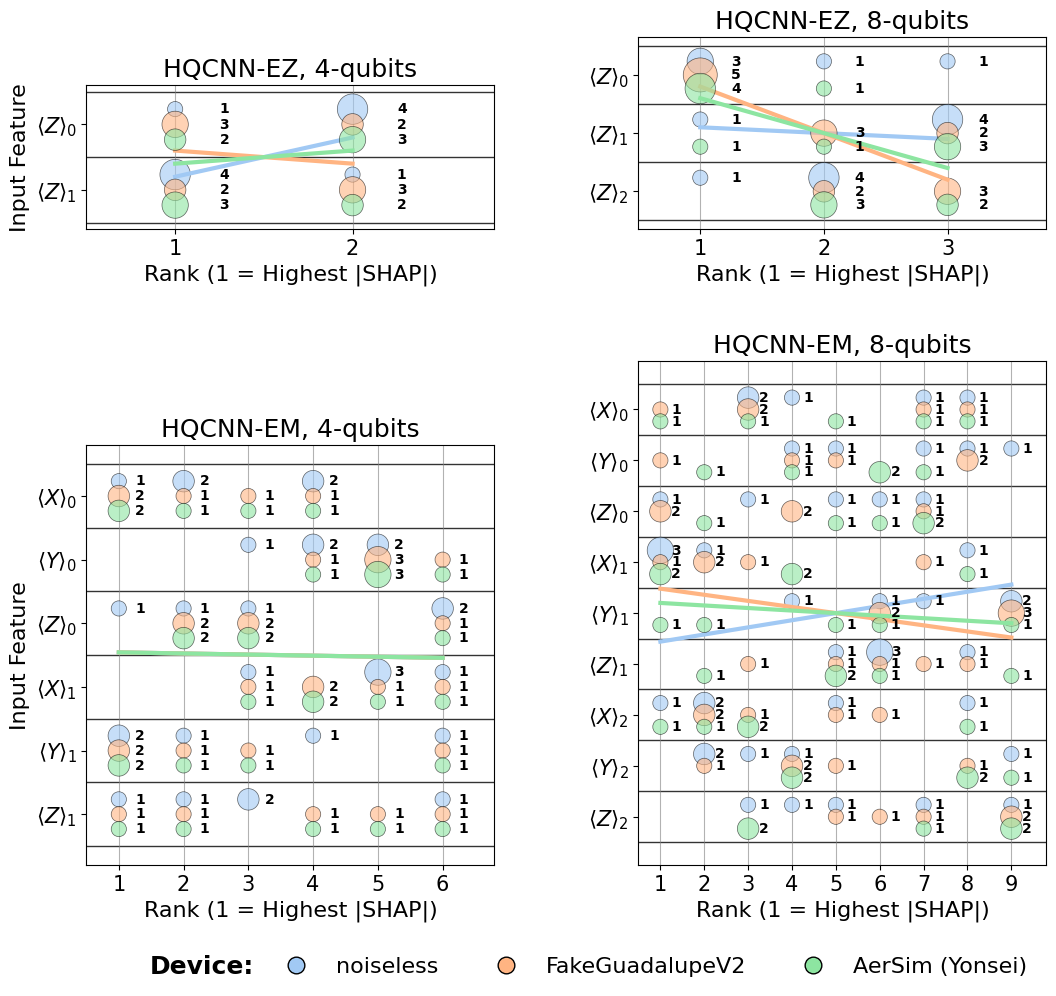

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
import os
import re

def plot_rank_stability_bubbles_text_reg_for_model(
    shap_df, num_qubit, model,
    ax=None,
    title_fontsize=14, axis_label_fontsize=12, tick_fontsize=12,
    legend_size=10, 
    plot_title=True
):
    """
    Plots a Rank Stability Bubble Plot with raw COUNT labels AND Linear Regression Lines.
    """
    
    # 1. Filter Data
    df_model = shap_df[shap_df['Model'] == model].copy()
    if df_model.empty:
        print(f"No data found for model: {model}")
        return []

    # Standardize names
    df_model['Device'] = df_model['Device'].replace({
        "AerSim with backend noise": "AerSim (Yonsei)"
    })
    
    # 2. Setup Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,6))
    
    # 3. Define Y-Order (Top-to-Bottom)
    if model == 'HQCNN-EZ':
        y_order = [f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))]
    elif model == 'HQCNN-EM':
        y_order = [f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']]
    else:
        y_order = df_model['Input_Feature'].drop_duplicates().tolist()
    
    # --- LaTeX Label Transformation ---
    latex_labels = [
        f"$\\langle {lbl.split('⟩_')[0].strip('⟨')} \\rangle_{{{lbl.split('_')[-1]}}}$" 
        if '⟨' in lbl else lbl 
        for lbl in y_order
    ]
    
    hue_order = df_model['Device'].drop_duplicates().tolist()
    palette_colors = sns.color_palette('pastel', n_colors=len(hue_order)) 
    color_map = dict(zip(hue_order, palette_colors))
    
    # 4. Configuration
    BAR_WIDTH = 0.7
    num_hues = len(hue_order)
    hue_offsets = {
        device: (i - (num_hues - 1) / 2) * (BAR_WIDTH / num_hues)
        for i, device in enumerate(hue_order)
    }
    y_mapping = {feat: i for i, feat in enumerate(y_order)}
    

    y_mapping_reg = {}
    if model == 'HQCNN-EZ':
        model_factor = 1
        const_factor = 0
    else:
        model_factor = 3
        const_factor = 1
        
    for s in y_order:
        m = re.search(r'_(\d+)$', s)   # grab the trailing number
        if not m:
            continue
        idx = int(m.group(1))
        y_mapping_reg[s] = model_factor * idx + const_factor
    # print(y_mapping_reg)

    # --- 5. Draw Boundary Lines ---
    for y in range(len(y_order) + 1):
        ax.axhline(y - 0.5, color='black', linestyle='-', linewidth=1.0, alpha=0.8, zorder=0)

    # 6. Calculate Rank Counts & Ratios for Bubbles
    rank_counts = df_model.groupby(['Device', 'Input_Feature', 'Rank_Abs_SHAP']).size().reset_index(name='count')
    total_counts = df_model.groupby(['Device', 'Input_Feature']).size().reset_index(name='total')
    rank_counts = pd.merge(rank_counts, total_counts, on=['Device', 'Input_Feature'])
    rank_counts['ratio'] = rank_counts['count'] / rank_counts['total']
    
    # Scaling Factor for Bubble Size
    BUBBLE_SCALE = 600 

    # 7. Plot Bubbles & Text & REGRESSION
    max_rank_found = 1
    
    # Prepare data for regression (Needs numeric y-index)
    df_model['y_idx'] = df_model['Input_Feature'].map(y_mapping_reg)
    df_model = df_model.dropna(subset=['y_idx'])

    for device in hue_order:
        # --- A. BUBBLES ---
        device_data = rank_counts[rank_counts['Device'] == device]
        device_color = color_map[device]
        offset = hue_offsets[device]
        
        # Filter for current features
        device_data = device_data[device_data['Input_Feature'].isin(y_order)].copy()
        
        if not device_data.empty:
            # Map Y coordinates for Bubbles
            device_data['y_coord'] = device_data['Input_Feature'].map(y_mapping) + offset
            
            # Track max rank
            current_max = device_data['Rank_Abs_SHAP'].max()
            if not np.isnan(current_max):
                max_rank_found = max(max_rank_found, current_max)
                
            # Draw Bubbles
            ax.scatter(
                x=device_data['Rank_Abs_SHAP'],
                y=device_data['y_coord'],
                s=device_data['ratio'] * BUBBLE_SCALE, 
                color=device_color,
                alpha=0.6, # Lower alpha so line is visible
                edgecolors='black',
                linewidth=0.5,
                zorder=2
            )
            
            # Draw Text Labels
            for _, row in device_data.iterrows():
                count_val = int(row['count'])
                ax.text(
                    x=row['Rank_Abs_SHAP'] + 0.25, 
                    y=row['y_coord'],
                    s=str(count_val), 
                    fontsize=10,
                    color='black',
                    verticalalignment='center',
                    horizontalalignment='left',
                    zorder=4,
                    fontweight='bold'
                )

        # --- B. REGRESSION LINE ---
        # We plot the line using the raw df_model data (Rank vs y_idx)
        # scatter=False because we already have bubbles
        reg_data = df_model[df_model['Device'] == device]
        if not reg_data.empty:
             sns.regplot(
                data=reg_data,
                x='Rank_Abs_SHAP',
                y='y_idx', # Regress against the integer index
                color=device_color,
                ax=ax,
                scatter=False, # Don't plot the raw scatter points again
                fit_reg=True,
                ci=None,       # Remove confidence interval shading for clarity
                line_kws={'linewidth': 3, 'alpha': 1.0, 'linestyle': '-'}, # Dashed line to distinguish
                label=device
            )

    # 8. Formatting X-Axis
    ax.grid(axis='x', linestyle='-', color='gray', alpha=0.6, zorder=0)
    ax.set_xlim(0.5, max_rank_found + 0.8) 
    ax.xaxis.set_major_locator(MultipleLocator(1)) 
    
    # 9. Formatting Y-Axis (Top to Bottom)
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(y_order, fontsize=tick_fontsize)
    ax.invert_yaxis() 
    
    ax.set_xlabel("Rank (1 = Highest |SHAP|)", fontsize=axis_label_fontsize)
    
    if ax.get_position().x0 < 0.1:
        ax.set_ylabel("Input Feature", fontsize=axis_label_fontsize)
    else:
        ax.set_ylabel("")
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(latex_labels, fontsize=tick_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    
    if plot_title:
        ax.set_title(f"{model}, {num_qubit}-qubits", fontsize=title_fontsize)

    # 10. Prepare Legend Handles
    device_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[d], 
               markeredgecolor='black', markersize=12, label=d)
        for d in hue_order
    ]
    
    return device_handles

# ==========================================
#      EXECUTION BLOCK (2x3 GRID PLOT)
# ==========================================

import matplotlib.pyplot as plt

# --- Configurations ---
fig = plt.figure(figsize=(12, 12))  # Global Canvas

if len(num_qubits) == 2:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.08, 0.53, 0.34, 0.12])   # EZ, q4
    ax2 = fig.add_axes([0.54, 0.53, 0.34, 0.16])   # EZ, q8

    ax3 = fig.add_axes([0.08, 0.00, 0.34, 0.35])   # EM, q4
    ax4 = fig.add_axes([0.54, 0.00, 0.34, 0.42])   # EM, q8
    
    axes = [ax1, ax2, ax3, ax4]
    
elif len(num_qubits) == 3:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.00, 0.63, 0.26, 0.12])  # EZ, q4
    ax2 = fig.add_axes([0.36, 0.63, 0.26, 0.16])  # EZ, q8
    ax3 = fig.add_axes([0.72, 0.63, 0.26, 0.20])  # EZ, q10

    ax4 = fig.add_axes([0.00, 0.0, 0.26, 0.35])   # EM, q4
    ax5 = fig.add_axes([0.36, 0.0, 0.26, 0.42])   # EM, q8
    ax6 = fig.add_axes([0.72, 0.0, 0.26, 0.52])   # EM, q10
    
    axes = [ax1, ax2, ax3, ax4, ax5, ax6]

# num_qubits = [4, 8, 10]
models_for_rows = ['HQCNN-EZ', 'HQCNN-EM']

# Font sizes
title_font      = 16
subplot_title   = 18
axis_label_font = 16
tick_font       = 15
legend_font     = 16

legend_handles_shared = None

# --- Loop to Fill 2×3 Grid ---
idx = 0
for row, model_name in enumerate(models_for_rows):
    for col, nq in enumerate(num_qubits):
        current_ax = axes[idx]
        idx += 1
        
        # Call Function
        handles = plot_rank_stability_bubbles_text_reg_for_model(
            shap_df=absolute_shap_values_df[absolute_shap_values_df['Qubits'] == nq],
            num_qubit=nq,
            model=model_name,
            ax=current_ax,
            title_fontsize=subplot_title,
            axis_label_fontsize=axis_label_font,
            tick_fontsize=tick_font,
            legend_size=legend_font,
            plot_title=True
        )
        
        if legend_handles_shared is None and handles:
            legend_handles_shared = handles

# --- Global Legend ---
if legend_handles_shared:
    fig.legend(
        handles=legend_handles_shared,
        loc="lower center",
        bbox_to_anchor=(0.55, -0.11),
        ncol=len(legend_handles_shared),
        frameon=False,
        fontsize=legend_font,
        title_fontsize=legend_font
    )
    
    fig.text(0.22, -0.085, "Device:", ha='right', va='center', fontsize=legend_font+2, fontweight='bold')

# --- Save ---
if PLOT_SAVE:
    os.makedirs(save_summary_results_dirs, exist_ok=True)
    filename = os.path.join(save_summary_results_dirs, 'Absolute_SHAP_Rank_Stability_Bubble_Reg_2x3.pdf')
    fig.savefig(filename, dpi=300, bbox_inches='tight', format='pdf')
    print(f"✅ Plot saved as {filename}")

plt.show()

## Load backend configuration

In [87]:
# dir_names_strings

In [88]:
# from pathlib import Path


# for i, dir in enumerate(dir_names_strings):
#     folder_path = Path(dir+'/save_device')
#     files = [f.name for f in folder_path.iterdir() if f.is_file()]
#     print(dir)
#     for file in files:
#         print(file)
#     print()
    
#     if (i + 1) % 5 == 0:
#         print("----------------------------------------")
#         print()

In [89]:
dir_names_strings[0:5]

['save_results_reg/gen_linear_dataset_mr_w_error_4/model_mmF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns0_iter0_1024',
 'save_results_reg/gen_linear_dataset_mr_w_error_4/model_mmF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns0_iter1_1024',
 'save_results_reg/gen_linear_dataset_mr_w_error_4/model_mmF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns0_iter2_1024',
 'save_results_reg/gen_linear_dataset_mr_w_error_4/model_mmF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns0_iter3_1024',
 'save_results_reg/gen_linear_dataset_mr_w_error_4/model_mmF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns0_iter4_1024']

In [90]:
# import os
# import pickle
# import json

# for i, dir in enumerate(dir_names_strings):
#     # 1. Set your directory and file details here
#     save_dir_model = dir_names_strings[i]  # Update this with your path
#     # num_epochs = 20  # Update with your epoch
#     start_batch = 0   # Update with your batch
    
#     # 2. Reconstruct the folder path where the files are saved
#     save_device_info_dir = save_dir_model + '/save_device/'
#     print(save_device_info_dir)
    
#     # 3. Set up the exact file names for both pkl files
#     config_file = save_device_info_dir + f'backend_config_epoch{num_epochs}_batch{start_batch}.pkl'
#     prop_file = save_device_info_dir + f'backend_prop_epoch{num_epochs}_batch{start_batch}.pkl'
#     qubit_mapping_file = save_device_info_dir + f'qubit_mapping_epoch{num_epochs}_batch{start_batch}.json'
    
#     # 4. Load the configuration, properties, and qubit_mapping FileSelectBox
#     # print(f"Looking for config file at: {config_file}")
#     if os.path.exists(config_file):
#         with open(config_file, 'rb') as f:
#             backend_config = pickle.load(f)
#         print("✅ Backend configuration loaded successfully!")
#     else:
#         print("❌ Config file not found.")
        
#     # print(f"Looking for properties file at: {prop_file}")
#     if os.path.exists(prop_file):
#         with open(prop_file, 'rb') as f:
#             backend_properties = pickle.load(f)
#             print("✅ Backend properties loaded successfully!")
#     else:
#         print("❌ Property file not found.")
        
#     # print(f"Looking for properties file at: {qubit_mapping_file}")
#     if os.path.exists(qubit_mapping_file):
#         with open(qubit_mapping_file, 'r') as f:
#             backend_qubit_mapping = json.load(f)
#         print("✅ Qubit Mapping loaded successfully!")
#     else:
#         print("❌ Qubit Mapping file not found.")

In [91]:
# # backend_config
# # backend_properties
# # backend_qubit_mapping

# print(type(backend_config))
# print(type(backend_properties))
# print(type(backend_qubit_mapping))

In [92]:
# print(type(backend_config))
# backend_config

In [93]:
# print(type(backend_properties))

# print('backend_properties.keys():', backend_properties.keys())

# # backend_properties['gates']   # contains gate errors rates
# # backend_properties['general']   # two-qubit coupling Hamiltonian parameters
# # backend_properties['general_qlists']
# # backend_properties['last_update_date']
# # backend_properties['qubits']

# # backend_name (str) – Backend name.
# # backend_version (str) – Backend version in the form X.Y.Z.
# # last_update_date (datetime.datetime orstr) – Last date/time that a property was updated. If specified as a str, it must be in ISO format.
# # qubits (list) – System qubit parameters as a list of lists of Nduv objects
# # gates (list) – System gate parameters as a list of GateProperties objects
# # general (list) – General parameters as a list of Nduv objects
# # kwargs – optional additional fields

In [94]:
# # backend_qubit_mapping.keys()
# # backend_qubit_mapping['circuit_0']['logical_to_physical_map']
# # backend_qubit_mapping['circuit_0']['used_physical_qubits']

# print('backend_qubit_mapping.keys():', backend_qubit_mapping.keys())
# print('backend_qubit_mapping["circuit_0"].keys():', backend_qubit_mapping['circuit_0'].keys())
# print('ex) used_physical_qubits:', backend_qubit_mapping['circuit_0']['used_physical_qubits'])

### Load all of the backend calibration data

In [98]:
import os
import pickle
import json

all_backend_calibration_data = dict()

for num_qubit in num_qubits:
    for model_name in model_names_str:
        for model_spec in model_specs:
            for ns, device_name in zip(noise_settings[1:3], device_names[1:3]):
                for iter_num in sim_iter_num:
                    save_device_info_dir = (
                        f"save_results_{problem_type}/{dataset_name}_{num_qubit}/{model_name}/{model_spec}"
                        + f"/ns{ns}_iter{iter_num}_{num_shots}/"
                        + f"save_device/"
                    )
                    
                    config_file = save_device_info_dir + f'backend_config_epoch{num_epochs}_batch{start_batch}.pkl'
                    prop_file = save_device_info_dir + f'backend_prop_epoch{num_epochs}_batch{start_batch}.pkl'
                    qubit_mapping_file = save_device_info_dir + f'qubit_mapping_epoch{num_epochs}_batch{start_batch}.json'

                    # ✅ Initialize nested dict with num_qubit as first key
                    all_backend_calibration_data \
                        .setdefault(num_qubit, {}) \
                        .setdefault(model_name, {}) \
                        .setdefault(model_spec, {}) \
                        .setdefault(ns, {}) \
                        .setdefault(iter_num, {})

                    # if os.path.exists(shap_path):
                    #     try:
                    #         with open(shap_path, "rb") as f:
                    #             shap_values = pickle.load(f)
                    #             all_shap_values_dict[num_qubit][model_name][model_spec][ns][iter_num] = shap_values
                    #     except Exception as e:
                    #         print(f"⚠️ Error loading SHAP file at {shap_path}: {e}")
                    # else:
                    #     print(f"⚠️ Warning: {shap_path} does not exist!")
                        
                        
                    # print(f"Looking for config file at: {config_file}")
                    if os.path.exists(config_file):
                        with open(config_file, 'rb') as f:
                            backend_config = pickle.load(f)
                            all_backend_calibration_data[num_qubit][model_name][model_spec][ns][iter_num]['backend_config'] = backend_config
                        # print("✅ Backend configuration loaded successfully!")
                    else:
                        print("❌ Config file not found.")
                        
                    # print(f"Looking for properties file at: {prop_file}")
                    if os.path.exists(prop_file):
                        with open(prop_file, 'rb') as f:
                            backend_properties = pickle.load(f)
                            all_backend_calibration_data[num_qubit][model_name][model_spec][ns][iter_num]['backend_properties'] = backend_properties
                        # print("✅ Backend properties loaded successfully!")
                    else:
                        print("❌ Property file not found.")
                        
                    # print(f"Looking for properties file at: {qubit_mapping_file}")
                    if os.path.exists(qubit_mapping_file):
                        with open(qubit_mapping_file, 'r') as f:
                            backend_qubit_mapping = json.load(f)
                            all_backend_calibration_data[num_qubit][model_name][model_spec][ns][iter_num]['backend_qubit_mapping'] = backend_qubit_mapping
                        # print("✅ Qubit Mapping loaded successfully!")
                    else:
                        print("❌ Qubit Mapping file not found.")

In [99]:
# all_backend_calibration_data[]

all_backend_calibration_data[num_qubit][model_name][model_spec][ns][iter_num].keys()

dict_keys(['backend_config', 'backend_properties', 'backend_qubit_mapping'])

In [100]:
# all_backend_calibration_data[num_qubit][model_name][model_spec][ns][iter_num]['backend_qubit_mapping']['circuit_0']['used_physical_qubits']

### Find the calibration data used in the simulation 

In [101]:
# Qubit (index)
# T1 (us) main_object['backend_properties'][]
# T2 (us)
# Frequency (GHz)
# Anharmonicity (GHz)
# Readout assignment error
# Prob meas0 prep1
# Prob meas1 prep0
# Readout length (ns)
# ID error
# Single-qubit gate length (ns)
# Z-axis rotation (rz) error
# √x (sx) error
# Pauli-X error
# ECR error
# Gate length (ns)
# MEASURE error
# Operational

In [102]:
import pandas as pd
import numpy as np

def extract_full_calibration_table(properties):
    """
    Extracts the 17 requested metrics for all qubits from a dictionary representation
    of backend properties.
    """
    rows = []
    
    # --- Helper to extract values from the list-of-dicts qubit structure ---
    def get_q_val(qubit_idx, name):
        # properties['qubits'] is a list of lists of property dicts
        for item in properties['qubits'][qubit_idx]:
            if item['name'] == name:
                return item['value']
        return 0

    # --- Helper to extract gate parameters ---
    def get_gate_val(gate_name, qubits, param_name):
        # properties['gates'] is a list of dictionaries
        for g in properties.get('gates', []):
            if g['gate'] == gate_name and list(g['qubits']) == list(qubits):
                for p in g['parameters']:
                    if p['name'] == param_name:
                        return p['value']
        return 0

    # Iterate through all physical qubits (e.g., 127 for ibm_yonsei)
    # Using key access instead of attribute access
    num_qubits = len(properties['qubits']) 
    
    for q_idx in range(num_qubits):
        # 1. Basic Qubit Properties
        t1 = get_q_val(q_idx, 'T1')
        t2 = get_q_val(q_idx, 'T2')
        freq = get_q_val(q_idx, 'frequency')
        anharm = get_q_val(q_idx, 'anharmonicity')
        
        # 2. Readout Properties
        ro_err = get_q_val(q_idx, 'readout_error')
        p01 = get_q_val(q_idx, 'prob_meas0_prep1')
        p10 = get_q_val(q_idx, 'prob_meas1_prep0')
        ro_len = get_q_val(q_idx, 'readout_length')

        # 3. Single-Qubit Gate Errors (ID, SX, X, RZ)
        id_err = get_gate_val('id', [q_idx], 'gate_error')
        sx_err = get_gate_val('sx', [q_idx], 'gate_error')
        x_err = get_gate_val('x', [q_idx], 'gate_error')
        rz_err = get_gate_val('rz', [q_idx], 'gate_error')
            
        # 4. Gate Lengths
        sq_len = get_gate_val('sx', [q_idx], 'gate_length')
        meas_err = get_gate_val('measure', [q_idx], 'gate_error')
        if meas_err == 0: meas_err = ro_err # Fallback to readout error if missing

        # 5. Two-Qubit Gate (ECR)
        # Search for all ECR gates where this qubit is one of the participants
        ecr_errs = []
        ecr_lens = []
        for g in properties.get('gates', []):
            if g['gate'] in ['cx', 'ecr'] and q_idx in g['qubits']:
                # Find error and length params for this specific ECR gate
                err = next((p['value'] for p in g['parameters'] if p['name'] == 'gate_error'), 0)
                leng = next((p['value'] for p in g['parameters'] if p['name'] == 'gate_length'), 0)
                
                # Only add if the value is non-zero (to avoid skewing average with missing data)
                if err > 0: ecr_errs.append(err)
                if leng > 0: ecr_lens.append(leng)
                
        # Calculate averages
        avg_ecr_err = np.mean(ecr_errs) if ecr_errs else 0
        avg_ecr_len = np.mean(ecr_lens) if ecr_lens else 0

        # Build the row matching your 17-column list
        rows.append({
            "Qubit": q_idx,
            "T1 (us)": t1,
            "T2 (us)": t2,
            "Frequency (GHz)": freq,
            "Anharmonicity (GHz)": anharm,
            "Readout assignment error": ro_err,
            "Prob meas0 prep1": p01,
            "Prob meas1 prep0": p10,
            "Readout length (ns)": ro_len,
            "ID error": id_err,
            "Single-qubit gate length (ns)": sq_len,
            "Z-axis rotation (rz) error": rz_err,
            "√x (sx) error": sx_err,
            "Pauli-X error": x_err,
            "CNOT/ECR error": avg_ecr_err,
            "Gate length (ns)": avg_ecr_len,
            "MEASURE error": meas_err
        })

    return pd.DataFrame(rows)

In [ ]:
# # Select an iteration to extract hardware data from
# example_q = 8
# example_model = 'model_mmF'
# example_spec = model_specs[0]
# example_ns = '2'
# example_iter = 0

# # Extract the properties object from your nested dictionary
# props = all_backend_calibration_data[example_q][example_model][example_spec][example_ns][example_iter]['backend_properties']

# # Generate the full table (127 rows for Yonsei)
# df_full = extract_full_calibration_table(props)

# # --- Now we use the qubit_mapping ---
# # Get the physical qubits used for this specific model mapping 
# mapping = all_backend_calibration_data[example_q][example_model][example_spec][example_ns][example_iter]['backend_qubit_mapping']
# used_physical_qubits = mapping['circuit_0']['used_physical_qubits']

# # Filter the table to only show the qubits in your circuit mapping
# df_mapped = df_full[df_full['Qubit'].isin(used_physical_qubits)].copy()

# # Sort by the order they appear in your mapping for clarity
# df_mapped['Mapping_Order'] = df_mapped['Qubit'].apply(lambda x: used_physical_qubits.index(x))
# df_mapped = df_mapped.sort_values('Mapping_Order').drop(columns='Mapping_Order')

# # Rename the original 'Qubit' column to 'Physical Qubits'
# df_mapped = df_mapped.rename(columns={'Qubit': 'Physical Qubits'})

# # Insert the 'Logical Qubits' column at the very beginning (position 0)
# df_mapped.insert(0, 'Logical Qubits', range(len(df_mapped)))

# # Reset the index so it is clean (0, 1, 2...)
# df_mapped = df_mapped.reset_index(drop=True)

# print(f"Calibration data for qubits used in {problem_type}/{dataset_name}_{example_q}/{example_model}/{example_spec}/ns{example_ns}_iter{example_iter}:")
# display(df_mapped)

In [ ]:
df_backend_calibration_data_avg_list = []

for num_qubit in num_qubits:
    for model_name in model_names_str:
        for model_spec in model_specs:
            for ns, device_name in zip(noise_settings[1:3], device_names[1:3]):
                for iter_num in sim_iter_num:
                    save_device_info_dir = (
                        f"save_results_{problem_type}/{dataset_name}_{num_qubit}/{model_name}/{model_spec}"
                        + f"/ns{ns}_iter{iter_num}_{num_shots}/"
                        + f"save_device/"
                        )
                    
                    # Extract the properties object from your nested dictionary
                    props = all_backend_calibration_data[num_qubit][model_name][model_spec][ns][iter_num]['backend_properties']

                    # Generate the full table (127 rows for Yonsei)
                    df_full = extract_full_calibration_table(props)

                    # --- Now we use the qubit_mapping ---
                    # Get the physical qubits used for this specific model mapping 
                    mapping = all_backend_calibration_data[num_qubit][model_name][model_spec][ns][iter_num]['backend_qubit_mapping']
                    used_physical_qubits = mapping['circuit_0']['used_physical_qubits']

                    # Filter the table to only show the qubits in your circuit mapping
                    df_mapped = df_full[df_full['Qubit'].isin(used_physical_qubits)].copy()

                    # Sort by the order they appear in your mapping for clarity
                    df_mapped['Mapping_Order'] = df_mapped['Qubit'].apply(lambda x: used_physical_qubits.index(x))
                    df_mapped = df_mapped.sort_values('Mapping_Order').drop(columns='Mapping_Order')

                    # Rename the original 'Qubit' column to 'Physical Qubits'
                    df_mapped = df_mapped.rename(columns={'Qubit': 'Physical Qubits'})

                    # Insert the 'Logical Qubits' column at the very beginning (position 0)
                    df_mapped.insert(0, 'Logical Qubits', range(len(df_mapped)))

                    # Reset the index so it is clean (0, 1, 2...)
                    df_mapped = df_mapped.reset_index(drop=True)
                    
                    # print(f"Calibration data for qubits used in {problem_type}/{dataset_name}_{num_qubit}/{model_name}/{model_spec}/ns{ns}_iter{iter_num}:")
                    # display(df_mapped)
                    
                    # --- Calculate Averages ---
                    
                    # Select only numeric columns to average (exclude IDs)
                    # We drop 'Logical Qubits' and 'Physical Qubits' because their averages aren't metrics
                    cols_to_exclude = ['Logical Qubits', 'Physical Qubits']
                    numeric_metrics = df_mapped.drop(columns=cols_to_exclude)
                    
                    # 4. Calculate the mean for this iteration
                    avg_metrics = numeric_metrics.mean()
                    
                    # 5. Combine identifying info with the average results
                    avg_row = {
                        'Device': device_name,
                        'Qubits': num_qubit,
                        'Model': model_name,
                        'Model_spec': model_spec,
                        # 'ns': ns,
                        'sim_iter_num': iter_num,
                    }
                    # Update dictionary with the averaged metric values
                    avg_row.update(avg_metrics.to_dict())
                    
                    # Append to the results list
                    df_backend_calibration_data_avg_list.append(avg_row)

# Convert the list of dictionaries into a final summary DataFrame
df_backend_calibration_data_avg = pd.DataFrame(df_backend_calibration_data_avg_list)
df_backend_calibration_data_avg['Model'] = df_backend_calibration_data_avg['Model'].replace(model_rename_map)

# Display the summary table
print("Summary Table of Average Calibration Metrics per Iteration:")
display(df_backend_calibration_data_avg)
                    
if SUMMRAY_TABLE_SAVE:
    save_dir = f'save_results_{problem_type}/results_summary/'
for model_spec in model_specs:
    save_summary_results_dirs = f'{save_dir}{model_spec}_{num_shots}/'
    df_backend_calibration_data_avg.to_csv(save_summary_results_dirs+'device_calibration_data_avg.csv', encoding='utf-8-sig')

Summary Table of Average Calibration Metrics per Iteration:


,Device,Qubits,Model,Model_spec,sim_iter_num,T1 (us),T2 (us),Frequency (GHz),Anharmonicity (GHz),Readout assignment error,...,Prob meas1 prep0,Readout length (ns),ID error,Single-qubit gate length (ns),Z-axis rotation (rz) error,√x (sx) error,Pauli-X error,CNOT/ECR error,Gate length (ns),MEASURE error
0,FakeGuadalupeV2,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,80.252136,99.905490,5.157940,-0.326349,0.015575,...,0.004100,5351.111111,0.000273,35.555556,0.0,0.000273,0.000273,0.010105,387.555556,0.015575
1,FakeGuadalupeV2,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,80.252136,99.905490,5.157940,-0.326349,0.015575,...,0.004100,5351.111111,0.000273,35.555556,0.0,0.000273,0.000273,0.010105,387.555556,0.015575
2,FakeGuadalupeV2,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,2,80.252136,99.905490,5.157940,-0.326349,0.015575,...,0.004100,5351.111111,0.000273,35.555556,0.0,0.000273,0.000273,0.010105,387.555556,0.015575
3,FakeGuadalupeV2,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,3,80.252136,99.905490,5.157940,-0.326349,0.015575,...,0.004100,5351.111111,0.000273,35.555556,0.0,0.000273,0.000273,0.010105,387.555556,0.015575
4,FakeGuadalupeV2,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,80.252136,99.905490,5.157940,-0.326349,0.015575,...,0.004100,5351.111111,0.000273,35.555556,0.0,0.000273,0.000273,0.010105,387.555556,0.015575
5,AerSim with backend noise,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,256.974276,52.660936,4.841445,-0.308467,0.015472,...,0.013184,840.000000,0.000243,60.000000,0.0,0.000243,0.000243,0.007270,636.000000,0.015472
6,AerSim with backend noise,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,256.974276,52.660936,4.841445,-0.308467,0.015472,...,0.013184,840.000000,0.000243,60.000000,0.0,0.000243,0.000243,0.007270,636.000000,0.015472
7,AerSim with backend noise,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,2,256.974276,52.660936,4.841445,-0.308467,0.015472,...,0.013184,840.000000,0.000243,60.000000,0.0,0.000243,0.000243,0.007270,636.000000,0.015472
8,AerSim with backend noise,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,3,256.974276,52.660936,4.841445,-0.308467,0.015472,...,0.013184,840.000000,0.000243,60.000000,0.0,0.000243,0.000243,0.007270,636.000000,0.015472
9,AerSim with backend noise,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,256.974276,52.660936,4.841445,-0.308467,0.015472,...,0.013184,840.000000,0.000243,60.000000,0.0,0.000243,0.000243,0.007270,636.000000,0.015472


In [ ]:
# Perform the second-level averaging to find overall error rates
df_backend_calibration_final_summary = df_backend_calibration_data_avg.groupby(
    ['Device', 'Qubits', 'Model', 'Model_spec']
).mean(numeric_only=True).reset_index()

# Remove the 'sim_iter_num' column 
if 'sim_iter_num' in df_backend_calibration_final_summary.columns:
    df_backend_calibration_final_summary = df_backend_calibration_final_summary.drop(columns=['sim_iter_num'])

# Set the Device column sorting
df_backend_calibration_final_summary = df_backend_calibration_final_summary.sort_values(
    by=['Device', 'Qubits', 'Model'], 
    ascending=[False, True, False]
).reset_index(drop=True)

# Display the final averaged summary
print("Final Summary Table (Averaged across iterations and sorted by Device):")
display(df_backend_calibration_final_summary)

if SUMMRAY_TABLE_SAVE:
    save_dir = f'save_results_{problem_type}/results_summary/'
for model_spec in model_specs:
    save_summary_results_dirs = f'{save_dir}{model_spec}_{num_shots}/'
    df_backend_calibration_final_summary.to_csv(save_summary_results_dirs+'device_calibration_data_avg_summary.csv', encoding='utf-8-sig')

Final Summary Table (Averaged across iterations and sorted by Device):


,Device,Qubits,Model,Model_spec,T1 (us),T2 (us),Frequency (GHz),Anharmonicity (GHz),Readout assignment error,Prob meas0 prep1,Prob meas1 prep0,Readout length (ns),ID error,Single-qubit gate length (ns),Z-axis rotation (rz) error,√x (sx) error,Pauli-X error,CNOT/ECR error,Gate length (ns),MEASURE error
0,FakeGuadalupeV2,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,80.252136,99.905490,5.157940,-0.326349,0.015575,0.027050,0.004100,5351.111111,0.000273,35.555556,0.0,0.000273,0.000273,0.010105,387.555556,0.015575
1,FakeGuadalupeV2,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,80.252136,99.905490,5.157940,-0.326349,0.015575,0.027050,0.004100,5351.111111,0.000273,35.555556,0.0,0.000273,0.000273,0.010105,387.555556,0.015575
2,FakeGuadalupeV2,4,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,80.252136,99.905490,5.157940,-0.326349,0.015575,0.027050,0.004100,5351.111111,0.000273,35.555556,0.0,0.000273,0.000273,0.010105,387.555556,0.015575
3,FakeGuadalupeV2,8,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,73.626765,91.356071,5.232412,-0.326173,0.020345,0.033065,0.007625,5351.111111,0.000370,35.555556,0.0,0.000370,0.000370,0.010459,389.600000,0.020345
4,FakeGuadalupeV2,8,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,71.963349,90.253407,5.238191,-0.326182,0.020760,0.033345,0.008175,5351.111111,0.000410,35.555556,0.0,0.000410,0.000410,0.010600,391.022222,0.020760
5,FakeGuadalupeV2,8,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,72.588021,90.879898,5.228902,-0.326207,0.020297,0.032935,0.007660,5351.111111,0.000373,35.555556,0.0,0.000373,0.000373,0.010383,387.644444,0.020297
6,AerSim with backend noise,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,256.974276,52.660936,4.841445,-0.308467,0.015472,0.017578,0.013184,840.000000,0.000243,60.000000,0.0,0.000243,0.000243,0.007270,636.000000,0.015472
7,AerSim with backend noise,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,262.654497,156.873633,4.747596,-0.309799,0.006561,0.010010,0.004395,840.000000,0.000233,60.000000,0.0,0.000233,0.000233,0.006055,641.000000,0.006561
8,AerSim with backend noise,4,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,262.654497,156.873633,4.747596,-0.309799,0.006561,0.010010,0.004395,840.000000,0.000233,60.000000,0.0,0.000233,0.000233,0.006055,641.000000,0.006561
9,AerSim with backend noise,8,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,265.193900,175.937254,4.798400,-0.309576,0.023093,0.020642,0.016455,840.000000,0.000468,60.000000,0.0,0.000468,0.000468,0.010226,639.400000,0.023093


In [110]:
# df_backend_calibration_final_summary2 = df_backend_calibration_data_avg.groupby(
#     ['Device', 'Model', 'Model_spec']
# ).mean(numeric_only=True).reset_index()
# df_backend_calibration_final_summary2 = df_backend_calibration_final_summary2.drop(columns=['Qubits', 'sim_iter_num'])

# # Set column sorting
# df_backend_calibration_final_summary2 = df_backend_calibration_final_summary2.sort_values(
#     by=['Device', 'Model'], 
#     ascending=[False, False]
# ).reset_index(drop=True)

# df_backend_calibration_final_summary2

In [ ]:
# 1. Group by your identifiers
# 2. Use .agg(['mean', 'std']) to calculate both metrics for all numeric columns
df_summary_agg = df_backend_calibration_data_avg.groupby(
    ['Device', 'Model', 'Model_spec']
).agg(['mean', 'std']).reset_index()

# 3. Drop the columns you don't want (Qubits and sim_iter_num)
# Note: Because of the MultiIndex, we drop them from the top level
# Or, more cleanly, drop them before grouping:
# df_backend_calibration_data_avg.drop(columns=['Qubits', 'sim_iter_num']).groupby(...)

# 4. Flatten the MultiIndex columns for better readability
# This changes columns from ('T1 (us)', 'mean') to 'T1 (us)_mean'
df_summary_agg.columns = [
    f"{col[0]}_{col[1]}" if col[1] else col[0] 
    for col in df_summary_agg.columns
]

# 5. Filter out the mean/std for columns we don't need
cols_to_drop = [
    'Qubits_mean', 'Qubits_std', 
    'sim_iter_num_mean', 'sim_iter_num_std'
]
df_backend_calibration_final_summary2 = df_summary_agg.drop(
    columns=[c for c in cols_to_drop if c in df_summary_agg.columns]
)

# Set column sorting
df_backend_calibration_final_summary2 = df_backend_calibration_final_summary2.sort_values(
    by=['Device', 'Model'], 
    ascending=[False, False]
).reset_index(drop=True)

df_backend_calibration_final_summary2

# Display the result
print("Extended Summary Table (Mean and Standard Deviation):")
display(df_backend_calibration_final_summary2)

# Save the df
if SUMMRAY_TABLE_SAVE:
    save_dir = f'save_results_{problem_type}/results_summary/'
for model_spec in model_specs:
    save_summary_results_dirs = f'{save_dir}{model_spec}_{num_shots}/'
    df_backend_calibration_final_summary2.to_csv(save_summary_results_dirs+'device_calibration_data_avg_summary_compact.csv', encoding='utf-8-sig')

Extended Summary Table (Mean and Standard Deviation):


,Device,Model,Model_spec,T1 (us)_mean,T1 (us)_std,T2 (us)_mean,T2 (us)_std,Frequency (GHz)_mean,Frequency (GHz)_std,Anharmonicity (GHz)_mean,...,√x (sx) error_mean,√x (sx) error_std,Pauli-X error_mean,Pauli-X error_std,CNOT/ECR error_mean,CNOT/ECR error_std,Gate length (ns)_mean,Gate length (ns)_std,MEASURE error_mean,MEASURE error_std
0,FakeGuadalupeV2,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,76.939451,3.986808,95.630780,4.744068,5.195176,0.041457,-0.326261,...,0.000322,0.000088,0.000322,0.000088,0.010282,0.000394,388.577778,9.007562,0.017960,0.003619
1,FakeGuadalupeV2,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,76.107743,4.395350,95.079448,5.245717,5.198065,0.045443,-0.326266,...,0.000342,0.000101,0.000342,0.000101,0.010353,0.000473,389.288889,12.047976,0.018167,0.004003
2,FakeGuadalupeV2,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,76.420079,4.208392,95.392694,5.087218,5.193421,0.038769,-0.326278,...,0.000323,0.000087,0.000323,0.000087,0.010244,0.000224,387.600000,9.087775,0.017936,0.003480
3,AerSim with backend noise,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,261.084088,16.714383,114.299095,64.994488,4.819922,0.031627,-0.309021,...,0.000356,0.000228,0.000356,0.000228,0.008748,0.006169,637.700000,2.359378,0.019283,0.011564
4,AerSim with backend noise,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,260.104523,4.070361,172.401163,18.571118,4.776145,0.034437,-0.309325,...,0.000268,0.000049,0.000268,0.000049,0.006243,0.000448,641.000000,1.795055,0.011624,0.005987
5,AerSim with backend noise,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,257.968533,6.690789,167.002291,10.979835,4.780108,0.035403,-0.309324,...,0.000282,0.000053,0.000282,0.000053,0.006262,0.000532,640.750000,1.513825,0.010875,0.004934
